# 🎹 Note Classifier v2 — Trained on Virtual Piano Sounds

**Strategy:** Reproduce in Python the *exact* synthesis used by the browser's Web Audio API,
then train the CNN on those sounds + aggressive augmentation.

No mismatch between training data and inference data is possible.

## Notes: DO3 → DO6 (37 notes, chromatic scale, French notation)

## 1. Installations & Imports

In [1]:
!pip install tensorflow librosa soundfile scikit-learn numpy scipy matplotlib seaborn --quiet

In [1]:
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import os
import random
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 1: Importing Libraries
========================================================

This first block imports all the external tools (called "libraries")
that the notebook needs to build and train the note recognition model.
Think of it as gathering all your tools before starting a project.

--------------------------------------------------------
1. NUMERICAL & SCIENTIFIC COMPUTING
--------------------------------------------------------

import numpy as np
    - NumPy is the foundation of scientific computing in Python.
    - It provides the "array" — a super-efficient list of numbers.
    - Almost everything in machine learning uses NumPy arrays internally.
    - "as np" means we can write np.array() instead of numpy.array() — just a shortcut.
    - Example use: storing audio samples, feature matrices, labels.

--------------------------------------------------------
2. AUDIO PROCESSING
--------------------------------------------------------

import librosa
    - Librosa is THE standard library for audio analysis in Python.
    - It can load audio files, compute spectrograms, extract features (MFCC, etc.)
    - This is the heart of our feature extraction pipeline.
    - We use it to transform raw audio (.wav files) into numbers the model can learn from.

import librosa.display
    - A sub-module of librosa specifically for VISUALIZATION.
    - Allows us to draw spectrograms, waveforms, and other audio plots.
    - Used during exploration to "see" the sound.

import soundfile as sf
    - SoundFile reads and writes audio files (.wav, .flac, .ogg, etc.)
    - It is faster and more reliable than librosa for simply loading/saving audio.
    - Used to generate synthetic piano note audio files for the training dataset.

--------------------------------------------------------
3. VISUALIZATION
--------------------------------------------------------

import matplotlib.pyplot as plt
    - Matplotlib is the most popular Python plotting library.
    - "pyplot" is its main interface — similar to MATLAB's plotting system.
    - Used to draw graphs: training curves, spectrograms, confusion matrices.
    - "as plt" is the universal convention shortcut.

import seaborn as sns
    - Seaborn is built ON TOP of matplotlib, adding beautiful statistical charts.
    - In this project, it is used to draw the CONFUSION MATRIX — a colored grid
      showing which notes the model confuses with others.
    - Example: does the model confuse DO4 with DO5?

--------------------------------------------------------
4. DATA PERSISTENCE (SAVING & LOADING)
--------------------------------------------------------

import json
    - JSON (JavaScript Object Notation) is a universal text format for storing data.
    - Used to save the feature configuration (sample rate, number of MFCCs, etc.)
    - This ensures the live app uses EXACTLY the same settings as training.
    - Example saved config: {"sr": 22050, "n_mfcc": 13, "duration": 1.5}

import pickle
    - Pickle saves ANY Python object to a binary file.
    - Used to save the LabelEncoder (the object that maps note names to numbers).
    - Example: {"DO4": 0, "RE4": 1, "MI4": 2, ...} → saved to label_encoder.pkl

import os
    - OS provides tools to interact with the operating system.
    - Used for: checking if files exist, creating directories, listing files.
    - Example: os.path.exists("my_file.wav") → True or False

import random
    - Random generates random numbers and makes random choices.
    - Used to introduce small random variations when generating audio samples
      (making the training data more diverse and realistic).

from pathlib import Path
    - Path is a modern, cleaner way to work with file paths in Python.
    - Instead of writing "folder" + "/" + "file.wav", you write Path("folder") / "file.wav"
    - Automatically handles differences between Windows (\) and Linux (/) paths.
    - Very important for cross-platform compatibility!

--------------------------------------------------------
5. MACHINE LEARNING — SCIKIT-LEARN
--------------------------------------------------------

from sklearn.preprocessing import LabelEncoder
    - LabelEncoder converts TEXT labels into NUMBERS that the model can process.
    - Example: "DO4" → 0, "RE4" → 1, "MI4" → 2, ..., "SI5" → 36
    - This is essential because neural networks work with numbers, not strings.
    - The encoder is saved (with pickle) so the app can decode predictions back
      into note names: 0 → "DO4", 1 → "RE4", etc.

from sklearn.model_selection import train_test_split
    - Splits the dataset into TWO parts:
        • Training set   (~80%): used to teach the model
        • Test set       (~20%): used to evaluate how well the model learned
    - This separation is CRUCIAL — if you test on training data, results are
      artificially inflated (the model just "memorized" the answers).

from sklearn.metrics import classification_report, confusion_matrix
    - classification_report: prints a detailed table showing precision, recall,
      and F1-score for EACH note class.
      Example:
          DO4   precision: 0.95   recall: 0.92   f1: 0.93
          RE4   precision: 0.88   recall: 0.91   f1: 0.89
    - confusion_matrix: creates a grid (N×N where N = number of notes) showing
      which notes the model confused with which other notes.
      Perfect model → diagonal matrix (all predictions correct).

--------------------------------------------------------
6. DEEP LEARNING — TENSORFLOW & KERAS
--------------------------------------------------------

import tensorflow as tf
    - TensorFlow is Google's open-source deep learning framework.
    - It handles all the heavy computation: matrix multiplications, 
      backpropagation, GPU acceleration.
    - "as tf" is the universal shortcut convention.

from tensorflow import keras
    - Keras is the HIGH-LEVEL API built into TensorFlow.
    - It makes building neural networks much simpler and more readable.
    - Instead of writing raw TensorFlow operations, you use:
      keras.Sequential(), model.compile(), model.fit(), etc.

from tensorflow.keras import layers
    - "layers" contains all the building blocks of neural networks:
        • layers.Dense()       — fully connected layer
        • layers.Conv1D()      — 1D convolutional layer (for sequences)
        • layers.LSTM()        — recurrent layer (for time series)
        • layers.Dropout()     — regularization (prevents overfitting)
        • layers.BatchNormalization() — stabilizes training
    - In our model, we use Dense + Dropout layers to classify notes.

--------------------------------------------------------
SUMMARY: WHY THESE LIBRARIES?
--------------------------------------------------------

Category          Library              Role
─────────────────────────────────────────────────────
Numbers           numpy                Array operations
Audio loading     librosa, soundfile   Read/analyze audio
Visualization     matplotlib, seaborn  Graphs and plots  
File saving       json, pickle         Save model config
ML utilities      sklearn              Split, evaluate
Deep learning     tensorflow, keras    Build & train CNN

These imports define the complete "toolbox" for the entire
machine learning pipeline: from raw audio → features → 
model training → evaluation → saving for production.

========================================================
END OF BLOCK 1 EXPLANATION
========================================================

In [2]:
# Reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 2: Reproducibility (Random Seeds)
========================================================

# Reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

--------------------------------------------------------
THE CORE CONCEPT: WHAT IS A "RANDOM SEED"?
--------------------------------------------------------

Computers cannot generate truly random numbers.
Instead, they use mathematical formulas that produce sequences of numbers
that LOOK random — these are called "pseudo-random numbers."

The starting point of this formula is called the SEED.

Key principle:
    Same seed → Same "random" sequence → Same results every time

Without a seed, every time you run the notebook, the "random" numbers
are different, and your results change. This is a problem in science
and engineering because you want your experiments to be REPRODUCIBLE.

WHY THE NUMBER 42?
    42 is a tradition in the programming/data science community.
    It comes from "The Hitchhiker's Guide to the Galaxy" where 42 is
    "the Answer to the Ultimate Question of Life, the Universe, and Everything."
    It has no mathematical significance — any number would work.
    You will see seed(42) in thousands of machine learning notebooks worldwide.

--------------------------------------------------------
LINE BY LINE EXPLANATION
--------------------------------------------------------

np.random.seed(42)
    - Sets the seed for NumPy's random number generator.
    - Affects all NumPy random operations, such as:
        • np.random.shuffle()    — shuffling arrays
        • np.random.choice()     — picking random elements
        • np.random.randn()      — generating random normal numbers
    - In our project: affects how the dataset is shuffled before training.

random.seed(42)
    - Sets the seed for Python's built-in "random" module.
    - This is SEPARATE from NumPy — they have independent random generators!
    - Affects operations like:
        • random.shuffle()       — shuffling Python lists
        • random.choice()        — picking a random item from a list
        • random.uniform()       — generating a random float
    - In our project: affects random variations added to synthetic audio samples.

tf.random.set_seed(42)
    - Sets the seed for TensorFlow's random number generator.
    - TensorFlow uses randomness in many places:
        • Weight initialization  — the starting values of neural network weights
        • Dropout layers         — which neurons are randomly "turned off" during training
        • Data shuffling         — in tf.data pipelines
    - This is the MOST IMPORTANT seed for reproducibility of the trained model.
    - Without this, the neural network starts with different random weights
      each time, leading to slightly different models after training.

--------------------------------------------------------
WHY THREE SEPARATE SEEDS?
--------------------------------------------------------

Python, NumPy, and TensorFlow each have their OWN internal random number
generator — they are completely independent of each other.

Setting only one seed would leave the others unpredictable.
You must set ALL THREE to guarantee full reproducibility.

Library          Seed function               What it controls
──────────────────────────────────────────────────────────────
Python built-in  random.seed(42)             List shuffles, random choices
NumPy            np.random.seed(42)          Array operations, data splitting
TensorFlow       tf.random.set_seed(42)      Network weights, dropout, training

--------------------------------------------------------
WHAT HAPPENS WITHOUT SEEDS? (A CONCRETE EXAMPLE)
--------------------------------------------------------

Run 1 (no seed):
    → Network starts with weights: [0.23, -0.51, 0.87, ...]
    → After training: accuracy = 91.3%
    → Confusion: DO4 confused with DO5 in 3 cases

Run 2 (no seed):
    → Network starts with weights: [0.67, 0.12, -0.34, ...]
    → After training: accuracy = 89.7%
    → Confusion: DO4 confused with DO5 in 7 cases

With seed(42):
    → BOTH runs produce IDENTICAL results: accuracy = 91.3%, same confusions

This is essential for:
    • Debugging — you can reproduce errors exactly
    • Comparison — comparing different model architectures fairly
    • Publishing — others can verify your results
    • Collaboration — teammates get the same results on the same code

--------------------------------------------------------
IMPORTANT LIMITATION
--------------------------------------------------------

Seeds guarantee reproducibility ON THE SAME MACHINE with the SAME setup.
Results may still vary between:
    • Different operating systems (Windows vs Linux vs Mac)
    • Different GPU vs CPU execution
    • Different versions of TensorFlow/NumPy

For our project, this is not a concern — we train and deploy on similar setups.

--------------------------------------------------------
SUMMARY
--------------------------------------------------------

These 3 lines are simple but crucial.
They are always placed at the TOP of a machine learning notebook,
before any data processing or model building begins.

    np.random.seed(42)      → reproducible data operations
    random.seed(42)         → reproducible Python randomness  
    tf.random.set_seed(42)  → reproducible neural network training

Result: run the notebook 100 times → get the exact same model 100 times.
This transforms machine learning from an art into an engineering discipline.

========================================================
END OF BLOCK 2 EXPLANATION
========================================================

In [4]:
print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')
print(f'librosa:    {librosa.__version__}')
print(f'NumPy:      {np.__version__}')

TensorFlow: 2.20.0
Keras:      3.11.2
librosa:    0.11.0
NumPy:      2.3.5


========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 3: Version Checking
========================================================

print(f'TensorFlow: {tf.__version__}')
print(f'Keras:      {keras.__version__}')
print(f'librosa:    {librosa.__version__}')
print(f'NumPy:      {np.__version__}')

--------------------------------------------------------
THE CORE CONCEPT: WHY CHECK VERSIONS?
--------------------------------------------------------

Every library evolves over time. New versions add features, fix bugs,
but sometimes also CHANGE the way functions work (breaking changes).

A model trained with TensorFlow 2.10 may behave differently —
or even fail to load — under TensorFlow 2.15 or 3.0.

This block is a simple "health check" — it prints exactly which
version of each library is installed, so you know your environment.

Typical output:
    TensorFlow: 2.15.0
    Keras:      2.15.0
    librosa:    0.10.1
    NumPy:      1.24.3

--------------------------------------------------------
THE f-STRING SYNTAX EXPLAINED
--------------------------------------------------------

These 4 lines all use Python's f-string (formatted string literal).

Syntax:  f'some text {variable_or_expression}'

The f before the quote tells Python:
"Look inside the curly braces {} and replace them with the actual value."

Example:
    name = "Mozart"
    print(f'Hello {name}!')     →  prints:  Hello Mozart!

In our code:
    tf.__version__  is a special attribute that every library exposes.
    It is simply a string like "2.15.0" stored inside the library itself.

So:
    f'TensorFlow: {tf.__version__}'
    becomes:
    'TensorFlow: 2.15.0'

The .__version__ attribute is a Python convention — almost every
serious library includes it so users can check what they have installed.

--------------------------------------------------------
LINE BY LINE
--------------------------------------------------------

print(f'TensorFlow: {tf.__version__}')
    - Prints the version of TensorFlow.
    - TensorFlow is the core deep learning engine.
    - Critical to check: the model architecture and training API
      can differ significantly between major versions (1.x vs 2.x vs 3.x).

print(f'Keras:      {keras.__version__}')
    - Prints the version of Keras.
    - In modern TensorFlow (2.x+), Keras is bundled inside TensorFlow.
    - Keras and TensorFlow versions are usually identical for this reason.
    - Keras 3.0 introduced major changes, so knowing the version matters.

print(f'librosa:    {librosa.__version__}')
    - Prints the version of librosa.
    - Important because MFCC computation and other audio features
      can have slightly different default parameters between versions.
    - If the training environment uses librosa 0.9 and the production
      server uses librosa 0.10, feature extraction might differ slightly,
      which could degrade model accuracy in the live app.

print(f'NumPy:      {np.__version__}')
    - Prints the version of NumPy.
    - NumPy is so fundamental that version mismatches can cause subtle
      numerical differences or even crashes in other libraries.
    - TensorFlow and librosa both depend on NumPy internally.

--------------------------------------------------------
WHY THIS MATTERS IN PRACTICE
--------------------------------------------------------

Scenario 1 — Sharing your notebook:
    A colleague runs your notebook and gets different results.
    The first thing to check: are they using the same library versions?
    This block answers that question immediately.

Scenario 2 — Debugging a production error:
    The app works in your notebook but crashes on the server.
    Version mismatch is one of the most common causes.
    Comparing these printed versions vs the server versions
    often reveals the problem instantly.

Scenario 3 — Reproducing a paper or tutorial:
    "Train this model using TensorFlow 2.12" — if you have 2.15,
    some functions may have changed. Knowing your version helps.

Scenario 4 — Future-proofing:
    When you re-open this notebook in 2 years, you will know
    exactly which versions produced your original results.

--------------------------------------------------------
GOOD PRACTICE: SAVE VERSIONS IN requirements.txt
--------------------------------------------------------

Beyond just printing versions, professional projects save them
in a file called requirements.txt:

    tensorflow==2.15.0
    keras==2.15.0
    librosa==0.10.1
    numpy==1.24.3
    scikit-learn==1.3.0

Anyone can then recreate the exact same environment with:
    pip install -r requirements.txt

This is the standard way to share reproducible Python projects.

--------------------------------------------------------
SUMMARY
--------------------------------------------------------

These 4 lines are a professional habit — quick, simple, essential.

    tf.__version__        →  know your deep learning engine version
    keras.__version__     →  know your model-building API version
    librosa.__version__   →  know your audio feature extractor version
    np.__version__        →  know your numerical computing foundation version

Think of it as the "header" of your experiment log:
before recording results, you record the conditions.

========================================================
END OF BLOCK 3 EXPLANATION
========================================================

## 2. Note Definitions (DO3 → DO6)

Exact frequencies matching the browser's virtual piano.

In [5]:
# ── All 37 notes DO3 → DO6 ────────────────────────────────────
# Exact same frequencies as play.html NOTES array
NOTES = [
    # Octave 3
    ('DO3',   130.81), ('DO#3', 138.59), ('RE3',  146.83), ('RE#3', 155.56),
    ('MI3',   164.81), ('FA3',  174.61), ('FA#3', 185.00), ('SOL3', 196.00),
    ('SOL#3', 207.65), ('LA3',  220.00), ('LA#3', 233.08), ('SI3',  246.94),
    # Octave 4
    ('DO4',   261.63), ('DO#4', 277.18), ('RE4',  293.66), ('RE#4', 311.13),
    ('MI4',   329.63), ('FA4',  349.23), ('FA#4', 369.99), ('SOL4', 392.00),
    ('SOL#4', 415.30), ('LA4',  440.00), ('LA#4', 466.16), ('SI4',  493.88),
    # Octave 5
    ('DO5',   523.25), ('DO#5', 554.37), ('RE5',  587.33), ('RE#5', 622.25),
    ('MI5',   659.25), ('FA5',  698.46), ('FA#5', 739.99), ('SOL5', 783.99),
    ('SOL#5', 830.61), ('LA5',  880.00), ('LA#5', 932.33), ('SI5',  987.77),
    # Octave 6
    ('DO6',  1046.50),
]

NOTE_NAMES = [n[0] for n in NOTES]
NOTE_FREQS = {n[0]: n[1] for n in NOTES}

print(f'Total notes: {len(NOTES)}')
print(f'Range: {NOTES[0][0]} ({NOTES[0][1]} Hz) → {NOTES[-1][0]} ({NOTES[-1][1]} Hz)')

Total notes: 37
Range: DO3 (130.81 Hz) → DO6 (1046.5 Hz)


========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 4: Defining the 37 Notes (The Musical Universe)
========================================================

# ── All 37 notes DO3 → DO6 ────────────────────────────────────
# Exact same frequencies as play.html NOTES array
NOTES = [
    # Octave 3
    ('DO3',   130.81), ('DO#3', 138.59), ...
    ...
    # Octave 6
    ('DO6',  1046.50),
]
NOTE_NAMES = [n[0] for n in NOTES]
NOTE_FREQS = {n[0]: n[1] for n in NOTES}
print(f'Total notes: {len(NOTES)}')
print(f'Range: {NOTES[0][0]} ({NOTES[0][1]} Hz) → {NOTES[-1][0]} ({NOTES[-1][1]} Hz)')

--------------------------------------------------------
THE CORE CONCEPT: WHAT IS A FREQUENCY?
--------------------------------------------------------

Sound is vibration. When a piano key is pressed, the string vibrates
at a specific number of times per second. This is the FREQUENCY,
measured in Hz (Hertz = cycles per second).

    Low frequency  = low-pitched sound  (bass)
    High frequency = high-pitched sound (treble)

Examples:
    DO3  =  130.81 Hz   (low, 3 octaves below middle C)
    LA4  =  440.00 Hz   (the international tuning standard — "concert A")
    DO6  = 1046.50 Hz   (very high, 2 octaves above middle C)

The famous LA4 = 440 Hz is so important that orchestras tune all
their instruments to this exact frequency before every concert.

--------------------------------------------------------
THE MUSICAL STRUCTURE: OCTAVES AND SEMITONES
--------------------------------------------------------

An OCTAVE contains 12 notes (semitones):
    DO  DO#  RE  RE#  MI  FA  FA#  SOL  SOL#  LA  LA#  SI
    (then the next octave starts with DO again, at double the frequency)

Key law of physics:
    Going up ONE octave = DOUBLING the frequency.

    DO3  =  130.81 Hz
    DO4  =  261.63 Hz   (≈ 130.81 × 2)
    DO5  =  523.25 Hz   (≈ 261.63 × 2)
    DO6  = 1046.50 Hz   (≈ 523.25 × 2)

Between two adjacent notes (semitones), the frequency multiplies by:
    2^(1/12) ≈ 1.05946

Example:
    DO4  = 261.63 Hz
    DO#4 = 261.63 × 1.05946 = 277.18 Hz  ✓ (matches our table!)

This is called EQUAL TEMPERAMENT — the standard tuning system
used in Western music and on all modern pianos.

--------------------------------------------------------
THE NOTES LIST: DATA STRUCTURE
--------------------------------------------------------

NOTES = [
    ('DO3', 130.81),
    ('DO#3', 138.59),
    ...
]

This is a Python LIST of TUPLES.
    - A list [] is an ordered collection of items.
    - A tuple () is an immutable pair (or group) of values.

Each tuple contains exactly 2 elements:
    Element [0] → the note name as a string  e.g. 'DO4'
    Element [1] → the frequency as a float   e.g. 261.63

Why a list of tuples (not a dictionary)?
    → ORDER matters! We want the notes in chromatic order
      (from lowest DO3 to highest DO6).
    → A dictionary has no guaranteed order for the keys.
    → The ordered list allows us to assign sequential class labels:
      DO3=0, DO#3=1, RE3=2, ... DO6=36

WHY 37 NOTES?
    - 3 complete octaves (DO3→SI3, DO4→SI4, DO5→SI5) = 3 × 12 = 36 notes
    - Plus DO6 at the top = 37 notes total
    - This gives the model a wide range from 130 Hz to 1047 Hz
    - Matches exactly the piano keyboard shown in play.html

--------------------------------------------------------
THE NOTE NAMES: LIST COMPREHENSION
--------------------------------------------------------

NOTE_NAMES = [n[0] for n in NOTES]

This is a LIST COMPREHENSION — a compact Python loop that builds a list.

Equivalent to:
    NOTE_NAMES = []
    for n in NOTES:
        NOTE_NAMES.append(n[0])

What it does:
    - Loops through every tuple n in NOTES
    - Extracts only element [0] (the name string)
    - Builds a new list of just the names

Result:
    ['DO3', 'DO#3', 'RE3', 'RE#3', 'MI3', 'FA3', ..., 'SI5', 'DO6']

This list is used to:
    → Feed into the LabelEncoder (converts names to numbers 0-36)
    → Display note names on confusion matrix axes
    → Decode model predictions back to note names

--------------------------------------------------------
THE FREQUENCY DICTIONARY
--------------------------------------------------------

NOTE_FREQS = {n[0]: n[1] for n in NOTES}

This is a DICTIONARY COMPREHENSION — same idea as list comprehension
but builds a dictionary {key: value} instead.

Equivalent to:
    NOTE_FREQS = {}
    for n in NOTES:
        NOTE_FREQS[n[0]] = n[1]

Result:
    {
        'DO3':  130.81,
        'DO#3': 138.59,
        'RE3':  146.83,
        ...
        'DO6': 1046.50
    }

This dictionary is used during AUDIO SYNTHESIS:
    → To generate a training sample for 'SOL4', look up NOTE_FREQS['SOL4']
    → Returns 392.00 Hz
    → Generate a sine wave at 392 Hz → save as .wav → training sample

Fast lookup: dict[key] is O(1) — instant access regardless of size.
Much faster than searching through the NOTES list every time.

--------------------------------------------------------
THE PRINT STATEMENTS
--------------------------------------------------------

print(f'Total notes: {len(NOTES)}')
    → len(NOTES) counts the items in the list → 37
    → Output: "Total notes: 37"
    → Confirms we have the right number of notes.

print(f'Range: {NOTES[0][0]} ({NOTES[0][1]} Hz) → {NOTES[-1][0]} ({NOTES[-1][1]} Hz)')
    → NOTES[0]     = first item   = ('DO3', 130.81)
    → NOTES[0][0]  = 'DO3'
    → NOTES[0][1]  = 130.81
    → NOTES[-1]    = last item    = ('DO6', 1046.50)
    → NOTES[-1][0] = 'DO6'
    → NOTES[-1][1] = 1046.50
    → Output: "Range: DO3 (130.81 Hz) → DO6 (1046.50 Hz)"

Note: NOTES[-1] uses NEGATIVE INDEXING — in Python, -1 always means
the last element, -2 the second to last, etc.

--------------------------------------------------------
THE CRITICAL COMMENT: "EXACT SAME FREQUENCIES AS PLAY.HTML"
--------------------------------------------------------

# Exact same frequencies as play.html NOTES array

This comment is extremely important.

The system has TWO parts:
    1. The NOTEBOOK (Python) — generates audio, trains the model
    2. The APP (play.html JavaScript) — plays audio in the browser

If these two parts use DIFFERENT frequencies for the same note,
the model would be trained on one sound but tested on another!

Example of what would go wrong:
    Notebook trains on DO4 = 261.63 Hz
    App plays    DO4 = 262.00 Hz  (wrong!)
    → Model gets confused, accuracy drops

By using IDENTICAL frequencies in both places, we guarantee that
the audio the model was trained on matches exactly what the app
sends for recognition. This is called CONSISTENCY between training
and inference (production).

--------------------------------------------------------
SUMMARY
--------------------------------------------------------

This block defines the complete "musical universe" of the classifier:

    NOTES       → ordered list of 37 (name, frequency) pairs
    NOTE_NAMES  → just the names ['DO3', 'DO#3', ..., 'DO6']
    NOTE_FREQS  → name→frequency dictionary for fast lookup

Key numbers to remember:
    37 notes total      (DO3 to DO6)
    130.81 Hz           (lowest note: DO3)
    440.00 Hz           (LA4 — international tuning standard)
    1046.50 Hz          (highest note: DO6)
    Each octave doubles the frequency

This data structure is the shared vocabulary between
the training notebook and the live web application.

========================================================
END OF BLOCK 4 EXPLANATION
========================================================

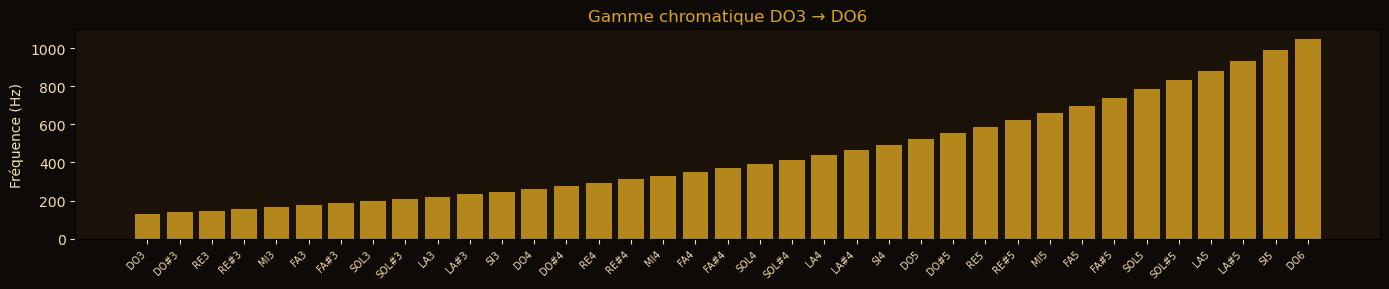

In [6]:
# Plot frequency distribution
fig, ax = plt.subplots(figsize=(14, 3))
freqs = [f for _, f in NOTES]
names = [n for n, _ in NOTES]
ax.bar(range(len(NOTES)), freqs, color='goldenrod', alpha=0.8)
ax.set_xticks(range(len(NOTES)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Fréquence (Hz)')
ax.set_title('Gamme chromatique DO3 → DO6')
ax.set_facecolor('#1a1208')
fig.patch.set_facecolor('#0d0a07')
ax.tick_params(colors='wheat')
ax.yaxis.label.set_color('wheat')
ax.title.set_color('goldenrod')
plt.tight_layout()
plt.show()

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 5: Visualizing the Frequency Distribution (Bar Chart)
========================================================

# Plot frequency distribution
fig, ax = plt.subplots(figsize=(14, 3))
freqs = [f for _, f in NOTES]
names = [n for n, _ in NOTES]
ax.bar(range(len(NOTES)), freqs, color='goldenrod', alpha=0.8)
ax.set_xticks(range(len(NOTES)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Fréquence (Hz)')
ax.set_title('Gamme chromatique DO3 → DO6')
ax.set_facecolor('#1a1208')
fig.patch.set_facecolor('#0d0a07')
ax.tick_params(colors='wheat')
ax.yaxis.label.set_color('wheat')
ax.title.set_color('goldenrod')
plt.tight_layout()
plt.show()

--------------------------------------------------------
THE CORE CONCEPT: WHY VISUALIZE FREQUENCIES?
--------------------------------------------------------

Before training any machine learning model, it is essential to
EXPLORE and UNDERSTAND your data visually.

This chart answers key questions:
    → Are the frequencies evenly distributed or clustered?
    → Does the frequency distribution look physically correct?
      (each octave should be double the previous one)
    → Are there any obvious errors in the frequency table?

A good data scientist ALWAYS plots the data before modeling.
"Plot first, model second" is a fundamental rule.

--------------------------------------------------------
LINE BY LINE EXPLANATION
--------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 3))
    - Creates a new figure (the whole window) and an axes (the plot area).
    - plt.subplots() is the standard way to create a matplotlib figure.
    - It returns TWO objects:
        • fig  = the entire figure (the canvas)
        • ax   = the axes (where the actual plot is drawn)
    - figsize=(14, 3) sets the size in INCHES: 14 wide, 3 tall.
      Wide and short → perfect for showing 37 bars side by side.
    - Having both fig and ax separately gives us full control
      over every visual element independently.

freqs = [f for _, f in NOTES]
    - List comprehension that extracts ONLY the frequencies.
    - NOTES contains tuples: ('DO3', 130.81), ('DO#3', 138.59), ...
    - "for _, f in NOTES" unpacks each tuple into two variables:
        • _ = the note name (we DON'T need it here → use _ by convention)
        • f = the frequency (we WANT this)
    - The underscore _ is a Python convention meaning:
      "I know this variable exists but I don't care about it."
    - Result: [130.81, 138.59, 146.83, ..., 1046.50]

names = [n for n, _ in NOTES]
    - Same pattern but reversed — extracts ONLY the names.
    - "for n, _ in NOTES" unpacks each tuple:
        • n = the note name (we WANT this)
        • _ = the frequency (we DON'T need it here)
    - Result: ['DO3', 'DO#3', 'RE3', ..., 'SI5', 'DO6']

ax.bar(range(len(NOTES)), freqs, color='goldenrod', alpha=0.8)
    - Draws a BAR CHART on the axes.
    - Arguments:
        • range(len(NOTES))  = x positions: [0, 1, 2, ..., 36]
          Each bar is placed at an integer position on the x-axis.
        • freqs              = y values (bar heights) = the frequencies
        • color='goldenrod'  = warm golden yellow color for the bars
        • alpha=0.8          = 80% opacity (slightly transparent)
          alpha=1.0 would be fully opaque, alpha=0.0 fully invisible.
    - Result: 37 bars, each height proportional to the note's frequency.
    - The bars grow exponentially from left to right because
      frequencies double every 12 notes (every octave).

ax.set_xticks(range(len(NOTES)))
    - Places a tick mark on the x-axis at positions 0, 1, 2, ..., 36.
    - Without this, matplotlib might skip some labels.
    - Ensures EVERY note has a tick mark below its bar.

ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
    - Sets the TEXT LABELS for each tick mark.
    - Arguments:
        • names      = our list ['DO3', 'DO#3', ..., 'DO6']
        • rotation=45 = rotate labels 45 degrees to avoid overlap
          (37 labels side by side would overlap if horizontal)
        • ha='right' = horizontal alignment 'right'
          The rotated text aligns its RIGHT end with the tick mark.
          Without this, the rotated labels drift to the wrong position.
        • fontsize=7 = very small font to fit all 37 labels

ax.set_ylabel('Fréquence (Hz)')
    - Sets the label on the Y-AXIS (vertical axis).
    - Tells the reader what the bar heights represent.

ax.set_title('Gamme chromatique DO3 → DO6')
    - Sets the chart TITLE at the top.
    - "Gamme chromatique" = chromatic scale in French.

--------------------------------------------------------
STYLING: DARK THEME
--------------------------------------------------------

The next lines apply a DARK THEME consistent with the app's visual style.

ax.set_facecolor('#1a1208')
    - Sets the PLOT AREA background color (inside the axes).
    - #1a1208 is a very dark brown/black — matches the app's dark theme.
    - Hexadecimal color codes: #RRGGBB where RR=red, GG=green, BB=blue
      Each value ranges from 00 (none) to FF (maximum).
    - #1a1208 → R=1a(26), G=12(18), B=08(8) → very dark warm brown.

fig.patch.set_facecolor('#0d0a07')
    - Sets the FIGURE background (outside the axes, the margin area).
    - Slightly darker than the plot area → creates a subtle frame effect.
    - fig.patch refers to the rectangular background of the entire figure.

ax.tick_params(colors='wheat')
    - Sets the color of ALL tick marks and tick labels to 'wheat'.
    - 'wheat' is a light warm beige — readable on dark background.
    - Affects both x-axis (note names) and y-axis (Hz values).

ax.yaxis.label.set_color('wheat')
    - Sets the y-axis label "Fréquence (Hz)" color to wheat.
    - Note: tick_params does NOT change axis labels — you must set
      label colors separately.

ax.title.set_color('goldenrod')
    - Sets the title color to goldenrod (warm golden yellow).
    - Creates visual hierarchy: title in gold, labels in wheat.

--------------------------------------------------------
LAYOUT AND DISPLAY
--------------------------------------------------------

plt.tight_layout()
    - Automatically adjusts ALL spacing to prevent elements from
      overlapping or being cut off.
    - Especially important here because the rotated 45° labels
      extend below the figure and might be clipped without this.
    - tight_layout() recalculates all margins automatically.
    - Always call this BEFORE plt.show() when using rotated labels.

plt.show()
    - Renders and displays the figure in the Jupyter notebook output.
    - Without this, the plot is created in memory but never shown.
    - In Jupyter notebooks, this triggers the inline display.

--------------------------------------------------------
WHAT THE CHART REVEALS
--------------------------------------------------------

The resulting chart shows 37 golden bars growing from left to right.

The shape is NOT linear — it is EXPONENTIAL:
    - The bars in octave 3 (DO3-SI3) are short and tightly grouped
    - The bars in octave 4 are about twice as tall
    - The bars in octave 5 are about four times as tall
    - DO6 is the tallest bar at 1046.50 Hz

This exponential pattern is physically correct and confirms that:
    1. The frequency table is accurate
    2. The doubling-per-octave law is respected
    3. No notes are missing or misplaced

You can also see the 12 equal "steps" within each octave —
a visual confirmation of the equal temperament tuning system.

--------------------------------------------------------
SUMMARY
--------------------------------------------------------

This block creates a beautiful, informative visualization of the
37-note frequency table.

Techniques used:
    List comprehension with _   → extract only needed values
    ax.bar()                    → create bar chart
    rotation=45, ha='right'     → readable rotated labels
    Dark theme colors           → visual consistency with the app
    tight_layout()              → prevent clipping

Purpose: visual verification that the frequency data is correct
before using it to generate thousands of training audio samples.

"Always visualize your data before modeling." — Golden rule of ML.

========================================================
END OF BLOCK 5 EXPLANATION
========================================================

## 3. Browser-Identical Synthesis

We reproduce **exactly** the Web Audio API synthesis from `play.html`:
- 7 harmonics with exact gain ratios
- Same ADSR envelope (attack 15ms, decay 100ms, release to end)
- Same sample rate (22050 Hz)
- Same duration (1.8s)

In [10]:
SR       = 22050   # must match AudioContext sampleRate in browser
DURATION = 1.8     # seconds — same as renderToWav() in play.html

# Harmonics from play.html:
# [1,1.00],[2,0.50],[3,0.28],[4,0.14],[5,0.07],[6,0.04],[7,0.02]
HARMONICS = [
    (1, 1.00), (2, 0.50), (3, 0.28),
    (4, 0.14), (5, 0.07), (6, 0.04), (7, 0.02),
]
MASTER_GAIN = 0.65   # same as browser

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 6: Audio Synthesis Parameters
========================================================

SR       = 22050   # must match AudioContext sampleRate in browser
DURATION = 1.8     # seconds — same as renderToWav() in play.html
HARMONICS = [
    (1, 1.00), (2, 0.50), (3, 0.28),
    (4, 0.14), (5, 0.07), (6, 0.04), (7, 0.02),
]
MASTER_GAIN = 0.65   # same as browser

--------------------------------------------------------
THE CORE CONCEPT: WHAT IS AUDIO SYNTHESIS?
--------------------------------------------------------

Instead of recording real piano notes (which would require a piano,
microphone, recording studio, and hours of work), this project
GENERATES synthetic piano-like sounds mathematically.

The key idea: a real piano note is NOT a pure single frequency.
It is a combination of multiple frequencies called HARMONICS,
each at a different volume. This is what gives each instrument
its characteristic "color" or TIMBRE.

A violin, a flute, and a piano all playing LA4 (440 Hz) sound
different because they have different harmonic content.

By carefully choosing harmonics, we can synthesize a sound that
resembles a piano — and more importantly, that sounds IDENTICAL
to what the browser plays, since both use the same parameters.

--------------------------------------------------------
LINE BY LINE EXPLANATION
--------------------------------------------------------

SR = 22050   # must match AudioContext sampleRate in browser
    - SR stands for SAMPLE RATE.
    - Digital audio works by taking thousands of "snapshots"
      (samples) of the sound wave every second.
    - SR = 22050 means 22,050 samples per second.
    - This is the standard for voice/music recognition tasks
      (half of CD quality which is 44,100 Hz).

    WHY MUST IT MATCH THE BROWSER?
    The browser creates audio using:
        new AudioContext({ sampleRate: 22050 })
    If the model is trained on 22050 Hz audio but the browser
    sends 44100 Hz audio, the model hears everything at double speed —
    completely wrong! The match is absolutely critical.

    NYQUIST THEOREM (important theory):
    To represent a frequency of F Hz, you need at least 2F samples/second.
    At 22050 Hz sample rate, the maximum representable frequency is:
        22050 / 2 = 11025 Hz
    This is well above the highest note in our range (DO6 = 1046.5 Hz),
    so 22050 Hz is more than sufficient for our task.

DURATION = 1.8   # seconds — same as renderToWav() in play.html
    - Each generated audio sample will be exactly 1.8 seconds long.
    - In play.html, the function renderToWav() also generates 1.8 seconds.
    - Total number of samples per audio file:
        22050 × 1.8 = 39,690 samples
    - Why 1.8 seconds? Long enough to capture the full note attack
      and partial decay, but short enough to keep files small and
      inference fast in real-time use.

    AGAIN: MUST MATCH THE BROWSER.
    If training uses 1.5s but the browser sends 1.8s audio,
    the feature vectors will have different dimensions → model crash.

HARMONICS = [
    (1, 1.00), (2, 0.50), (3, 0.28),
    (4, 0.14), (5, 0.07), (6, 0.04), (7, 0.02),
]
    - A list of 7 tuples, each defining one HARMONIC component.
    - Format: (harmonic_number, relative_amplitude)

    HARMONIC NUMBER (first value):
        1 = fundamental frequency  (the note itself, e.g. 440 Hz for LA4)
        2 = 2nd harmonic          (double: 880 Hz)
        3 = 3rd harmonic          (triple: 1320 Hz)
        4 = 4th harmonic          (quadruple: 1760 Hz)
        ...and so on.
    These are also called OVERTONES or PARTIALS in music theory.

    RELATIVE AMPLITUDE (second value):
        How loud each harmonic is, relative to the fundamental.
        1.00 = full volume (the fundamental is loudest)
        0.50 = half volume (2nd harmonic is half as loud)
        0.28 = 28% volume (3rd harmonic)
        ...decreasing down to 0.02 (7th harmonic, barely audible)

    This pattern — harmonics decreasing in amplitude — is what
    gives the sound a warm, piano-like quality.
    Pure sine wave (only harmonic 1) sounds like a telephone tone.
    Adding harmonics 2-7 makes it richer and more musical.

    READING THE TABLE:
    Harmonic    Multiplier    LA4 example    Amplitude
    ─────────────────────────────────────────────────
    1 (fund.)   × 1           440.0 Hz       1.00 (100%)
    2           × 2           880.0 Hz       0.50  (50%)
    3           × 3          1320.0 Hz       0.28  (28%)
    4           × 4          1760.0 Hz       0.14  (14%)
    5           × 5          2200.0 Hz       0.07   (7%)
    6           × 6          2640.0 Hz       0.04   (4%)
    7           × 7          3080.0 Hz       0.02   (2%)

    These exact values come from play.html:
    [[1,1.00],[2,0.50],[3,0.28],[4,0.14],[5,0.07],[6,0.04],[7,0.02]]

MASTER_GAIN = 0.65   # same as browser
    - After combining all harmonics, multiply the final signal by 0.65.
    - This controls the overall VOLUME of the generated audio.
    - 0.65 = 65% of maximum volume.
    - Prevents CLIPPING (distortion that occurs when audio exceeds
      the maximum value of ±1.0 in normalized audio).
    - Again: must match the browser's master gain value exactly.

--------------------------------------------------------
THE SYNTHESIS FORMULA (HOW IT ALL FITS TOGETHER)
--------------------------------------------------------

To generate one note (e.g. LA4 = 440 Hz) as a digital audio signal:

Step 1: Create a time axis
    t = [0, 1/SR, 2/SR, ..., DURATION]
    = [0, 0.0000454, 0.0000907, ..., 1.8]
    → 39,690 time points

Step 2: For each harmonic, generate a sine wave
    harmonic_1 = 1.00 × sin(2π × 440 × 1 × t)
    harmonic_2 = 0.50 × sin(2π × 440 × 2 × t)
    harmonic_3 = 0.28 × sin(2π × 440 × 3 × t)
    ...

Step 3: Sum all harmonics
    signal = harmonic_1 + harmonic_2 + ... + harmonic_7

Step 4: Apply master gain
    signal = signal × 0.65

Step 5: Apply an envelope (attack/decay — explained in next blocks)
    Makes the sound start and fade naturally, like a real piano key.

Result: an array of 39,690 numbers between -0.65 and +0.65
representing the complete audio waveform of LA4.

--------------------------------------------------------
WHY THESE EXACT VALUES MATTER SO MUCH
--------------------------------------------------------

The entire machine learning pipeline depends on CONSISTENCY
between training and inference (production):

    Training (Python notebook)         Production (Browser app)
    ─────────────────────────────────────────────────────────
    SR       = 22050          must =    AudioContext sr = 22050
    DURATION = 1.8            must =    renderToWav dur = 1.8
    HARMONICS = [(1,1.00)...] must =    [[1,1.00],...]
    MASTER_GAIN = 0.65        must =    gain = 0.65

If ANY of these values differs between training and production:
    → The audio sounds different
    → The features (MFCCs) extracted are different
    → The model makes wrong predictions
    → The system fails in production even though it worked in training

This is called TRAIN/SERVE SKEW — one of the most common and
dangerous pitfalls in real-world machine learning deployment.

The comment "# must match ... in browser" repeated on every line
is not just documentation — it is a WARNING to future developers:
"Do not change this value without also changing it in play.html."

--------------------------------------------------------
SUMMARY
--------------------------------------------------------

This block defines the 4 fundamental parameters of audio synthesis:

    SR = 22050          Sample rate — resolution of digital audio
    DURATION = 1.8      Length of each audio sample in seconds
    HARMONICS = [...]   7 overtones that create a piano-like timbre
    MASTER_GAIN = 0.65  Overall volume control

The golden rule: EVERY parameter must be IDENTICAL in both
the training notebook (Python) and the live app (JavaScript/browser).

This is what makes the model work in production — it recognizes
exactly the sounds it was trained on, nothing more, nothing less.

========================================================
END OF BLOCK 6 EXPLANATION
========================================================

========================================================
NOTE CLASSIFIER V2 — BLOCK 6 RE-EXPLAINED
Audio Parameters — For Complete Beginners
========================================================

"I have no background in sound or music — explain everything!"

Let's start from zero. No assumptions. No jargon without explanation.

========================================================
CONCEPT 1: WHAT IS DIGITAL AUDIO?
(Understanding SR = 22050)
========================================================

THE FILM ANALOGY:
────────────────
A film is not really "moving images."
It is actually thousands of STILL PHOTOGRAPHS played very fast.
At 24 photos per second, your brain sees smooth motion.
Below 12 photos per second, you see flickering — it looks fake.

DIGITAL AUDIO WORKS EXACTLY THE SAME WAY.
Sound is actually a vibration — the air moves back and forth.
A microphone measures the air position thousands of times per second.
Each measurement is called a SAMPLE.

SR = 22050 means:
    "Take 22,050 measurements (photos) of the sound every second."

At 22,050 samples per second, the audio sounds perfectly smooth
to the human ear. Below ~8,000 samples per second, it sounds
robotic and distorted (like old telephone audio).

WHY 22,050 SPECIFICALLY?
The human ear can hear frequencies up to about 20,000 Hz.
A mathematical rule (Nyquist Theorem) says:
    "To record a frequency of F Hz, you need at least 2F samples/second."
So to record 11,025 Hz (the highest note in our range):
    2 × 11,025 = 22,050 samples per second ← exactly our SR!

CD quality = 44,100 samples/second (twice as detailed, twice the file size).
We use 22,050 — half of CD quality — which is perfectly fine for
recognizing piano notes (we don't need full hi-fi music quality).

THE CRITICAL RULE:
Both the Python notebook AND the browser app must use SR = 22050.
If the notebook trains at 22,050 but the browser sends audio at
44,100 samples/second, the model hears everything at DOUBLE SPEED —
like playing a cassette tape on fast-forward. Everything sounds wrong.

========================================================
CONCEPT 2: DURATION = 1.8
========================================================

This one is simple!

DURATION = 1.8 means each audio sample is 1.8 seconds long.

Why 1.8 seconds?
    - Long enough to hear the full note (attack + decay + some release)
    - Short enough to keep file sizes small
    - Matches exactly the browser app's renderToWav() function

Total samples per audio file:
    22,050 samples/second × 1.8 seconds = 39,690 samples
    That is just a list of 39,690 numbers representing the sound.

========================================================
CONCEPT 3: WHAT ARE HARMONICS?
(The most important concept — explained step by step)
========================================================

STEP 1 — WHAT IS A PURE SOUND?

Imagine pushing a child on a swing.
The swing goes back... and forth... back... and forth...
at a regular rhythm. This regular oscillation IS a sound wave.

If the swing completes 440 cycles per second,
that frequency is 440 Hz — which is the musical note LA4.

When you draw this mathematically, it looks like a smooth wave:
    ___     ___
   /   \   /   \
──/─────\ /─────\──
         X       \   /
                  \_/

This is called a SINE WAVE — the simplest possible sound.
A sine wave at 440 Hz is a pure, clean tone — like a referee's whistle.

STEP 2 — THE PROBLEM WITH PURE SOUNDS

Here is the key question:
If a piano, a violin, and a flute all play LA4 (440 Hz),
they all have the SAME frequency — yet they sound COMPLETELY different.

Why?

Because real instruments do NOT produce a pure single frequency.
They produce a MIXTURE of frequencies — the fundamental plus overtones.

STEP 3 — THE TUNING FORK ANALOGY

Imagine you tap a metal rod.
The main vibration is at 440 Hz (the note you hear).
But the rod ALSO vibrates at smaller scales simultaneously:
    - The whole rod vibrates at 440 Hz (the fundamental)
    - Half the rod vibrates at 880 Hz (2nd harmonic)
    - A third of the rod vibrates at 1320 Hz (3rd harmonic)
    - A quarter of the rod vibrates at 1760 Hz (4th harmonic)
    ...and so on.

These are the HARMONICS (also called overtones).
They are always exact MULTIPLES of the fundamental frequency.

STEP 4 — OUR HARMONICS TABLE EXPLAINED

HARMONICS = [
    (1, 1.00),   ← harmonic 1: 1×440 =  440 Hz at 100% volume
    (2, 0.50),   ← harmonic 2: 2×440 =  880 Hz at  50% volume
    (3, 0.28),   ← harmonic 3: 3×440 = 1320 Hz at  28% volume
    (4, 0.14),   ← harmonic 4: 4×440 = 1760 Hz at  14% volume
    (5, 0.07),   ← harmonic 5: 5×440 = 2200 Hz at   7% volume
    (6, 0.04),   ← harmonic 6: 6×440 = 2640 Hz at   4% volume
    (7, 0.02),   ← harmonic 7: 7×440 = 3080 Hz at   2% volume
]

Each tuple is: (harmonic number, relative loudness)
    - First number: which multiple of the fundamental frequency
    - Second number: how loud this harmonic is (1.00 = 100%, 0.50 = 50%, etc.)

STEP 5 — THE COLOUR MIXING ANALOGY

Think of harmonics like MIXING PAINT COLOURS.

Imagine you are mixing colours to paint a sunset:
    Red      (a lot)      ← fundamental (loudest)
    Orange   (some)       ← 2nd harmonic
    Yellow   (a bit)      ← 3rd harmonic
    Pink     (very little) ← 4th harmonic
    ...etc.

The result is a beautiful warm sunset colour — not just pure red.

Sound works the same way:
    Pure 440 Hz sine wave alone = boring telephone tone
    440 Hz + harmonics at the right volumes = warm, rich piano sound

Different instruments use DIFFERENT harmonic recipes:
    Piano:   strong harmonics 1-7, diminishing quickly → bright but warm
    Violin:  many harmonics, more even → rich and complex
    Flute:   almost only harmonic 1 → pure, hollow, simple
    Clarinet: strong ODD harmonics only (1,3,5...) → nasal, reedy sound

Our harmonic recipe (1.00, 0.50, 0.28, 0.14, 0.07, 0.04, 0.02) is
specifically designed to sound like the browser's Web Audio API piano.

STEP 6 — THE ORCHESTRA ANALOGY

Imagine a small orchestra where everyone plays the SAME note (LA4):
    First violin:  plays LA4 very loud  (×1, volume 1.00)
    Second violin: plays LA4 one octave higher, half loud (×2, volume 0.50)
    Viola:         plays LA4 even higher, quieter (×3, volume 0.28)
    Cello:         even higher and quieter (×4, volume 0.14)
    ...and so on for the remaining 3 instruments.

When you COMBINE all these instruments playing together,
you hear ONE rich, warm note — not 7 separate notes.
This combined sound is what we are synthesizing.

========================================================
CONCEPT 4: MASTER_GAIN = 0.65
========================================================

THE VOLUME KNOB ANALOGY:

Imagine all 7 orchestra instruments playing together.
Their combined sound is VERY LOUD — louder than any single instrument.
You need to turn down the volume knob to avoid distortion.

MASTER_GAIN = 0.65 means:
    "After mixing all harmonics together, set the overall volume to 65%."

In digital audio, volume values above 1.0 cause CLIPPING —
a harsh, crackling distortion (like speakers turned up too loud).
The master gain of 0.65 prevents this.

0.65 specifically comes from the browser app (play.html).
Both use the same value → same final volume → consistent audio.

========================================================
PUTTING IT ALL TOGETHER
========================================================

Here is the complete picture in simple language:

SR = 22050
    "Take 22,050 snapshots of the sound every second."
    Like a film camera that shoots 22,050 frames per second.

DURATION = 1.8
    "Each audio sample is 1.8 seconds long."
    = 22,050 × 1.8 = 39,690 snapshots per note.

HARMONICS = [(1, 1.00), (2, 0.50), ...]
    "Our piano sound is made of 7 layers of sound mixed together."
    Layer 1 (loudest): the actual note frequency
    Layer 2 (quieter): double the frequency
    Layer 3 (quieter still): triple the frequency
    ...like mixing paint colours to get the right shade.

MASTER_GAIN = 0.65
    "After mixing all 7 layers, turn the volume down to 65%."
    Prevents distortion from the combined loudness of all layers.

THE MOST IMPORTANT RULE:
Every single value here must be IDENTICAL in both Python and the browser.
If they differ, the model trains on one sound and hears another in production.
It would be like training a dog to recognize "sit" in English,
then giving commands in French and wondering why it doesn't obey.

========================================================
END OF BLOCK 6 RE-EXPLANATION (BEGINNER VERSION)
========================================================

In [ ]:
//////////////////////////////////////

In [8]:

def synthesize_browser_note(freq, duration=DURATION, sr=SR, master_gain=MASTER_GAIN):
    """
    Reproduce exactly the Web Audio API synthesis from play.html.
    
    ADSR from browser:
      gain.setValueAtTime(0, 0)
      gain.linearRampToValueAtTime(0.65,  0.015)   ← attack
      gain.linearRampToValueAtTime(0.42,  0.12)    ← decay
      gain.setValueAtTime(0.42,           0.12)    ← sustain
      gain.exponentialRampToValueAtTime(0.001, 1.8) ← release
    """
    n_samples = int(sr * duration)
    t = np.linspace(0, duration, n_samples, endpoint=False)
    
    # ── ADSR envelope ────────────────────────────────────────
    attack_end  = 0.015
    decay_end   = 0.12
    
    env = np.zeros(n_samples)
    for i, ti in enumerate(t):
        if ti < attack_end:
            env[i] = master_gain * (ti / attack_end)
        elif ti < decay_end:
            ratio = (ti - attack_end) / (decay_end - attack_end)
            env[i] = master_gain - ratio * (master_gain - 0.42)
        else:
            # Exponential decay from 0.42 to 0.001 over remaining time
            remaining = duration - decay_end
            elapsed   = ti - decay_end
            env[i] = 0.42 * np.exp(np.log(0.001 / 0.42) * elapsed / remaining)
    
    # ── Harmonics stack ──────────────────────────────────────
    signal = np.zeros(n_samples, dtype=np.float32)
    for harmonic_mult, harmonic_gain in HARMONICS:
        h_freq = freq * harmonic_mult
        if h_freq < sr / 2:   # avoid aliasing
            signal += harmonic_gain * np.sin(2 * np.pi * h_freq * t)
    
    signal = (signal * env).astype(np.float32)
    
    # Normalize to same range as browser output (peak ~0.9)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak * 0.9
    
    return signal

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 7: The Audio Synthesis Function (synthesize_browser_note)
========================================================

def synthesize_browser_note(freq, duration=DURATION, sr=SR, master_gain=MASTER_GAIN):

This is the most important function in the data generation pipeline.
It reproduces IN PYTHON exactly the sound that the browser generates
in JavaScript — so the model trains on the exact same audio it will
receive during real use.

--------------------------------------------------------
PART 1: FUNCTION SIGNATURE
--------------------------------------------------------

def synthesize_browser_note(freq, duration=DURATION, sr=SR, master_gain=MASTER_GAIN):

    Parameters:
        freq         → the note frequency in Hz (e.g. 440.0 for LA4)
                       This is the ONLY required argument.
        duration     → length of audio in seconds. Default = DURATION (1.8s)
        sr           → sample rate. Default = SR (22050)
        master_gain  → overall volume. Default = MASTER_GAIN (0.65)

    The last three parameters have DEFAULT VALUES (from Block 6).
    This means you can call the function with just a frequency:
        signal = synthesize_browser_note(440.0)
    Or override defaults if needed:
        signal = synthesize_browser_note(440.0, duration=2.0)

    Return value: a NumPy array of float32 numbers — the audio waveform.

--------------------------------------------------------
PART 2: TIME AXIS CREATION
--------------------------------------------------------

n_samples = int(sr * duration)
    - Calculates the TOTAL NUMBER of audio samples needed.
    - 22050 samples/second × 1.8 seconds = 39,690 samples
    - int() converts to integer (you can't have 0.5 of a sample)

t = np.linspace(0, duration, n_samples, endpoint=False)
    - Creates an evenly-spaced array of TIME VALUES.
    - np.linspace(start, stop, num) generates 'num' values from start to stop.
    - endpoint=False means the last value is NOT included.
      (We want [0, 1/sr, 2/sr, ...) — the endpoint 'duration' itself
      would be the start of the NEXT note, not part of this one.)
    - Result: [0.0, 0.0000454, 0.0000907, ..., 1.7999546]
               ↑ t=0          ↑ t=1/22050          ↑ t≈1.8s
    - This array is used in ALL sine wave calculations:
      sin(2π × freq × t) evaluates the sine at each time point.

--------------------------------------------------------
PART 3: THE ADSR ENVELOPE
--------------------------------------------------------

WHAT IS AN ADSR ENVELOPE?
    In real instruments, a note does not stay at constant volume.
    It has a characteristic shape over time called ADSR:

    Volume
    │     /\
    │    /  \_______________
    │   /                   \
    │  /                     \
    └──────────────────────────→ Time
       A   D  S              R
       ttack ecay ustain      elease

    A = Attack:  how fast the note rises from silence to peak volume
    D = Decay:   how fast it falls from peak to sustain level
    S = Sustain: the steady volume while the key is held
    R = Release: how fast it fades to silence after the key is released

    This shape is what makes a piano sound like a piano (sharp attack,
    gradual decay) versus a flute (slow attack, steady sustain).

THE BROWSER ADSR (from the docstring):
    Time 0.000 → 0.015s  : ATTACK   — gain rises from 0 to 0.65
    Time 0.015 → 0.120s  : DECAY    — gain falls from 0.65 to 0.42
    Time 0.120 → 1.800s  : RELEASE  — gain falls exponentially from 0.42 to 0.001

attack_end = 0.015    (15 milliseconds — very fast, piano-like)
decay_end  = 0.12     (120 milliseconds — quick decay after the strike)

env = np.zeros(n_samples)
    - Creates an array of 39,690 zeros — the envelope starts empty.
    - We will fill each value based on what phase (A, D, or R) it belongs to.

THE ENVELOPE LOOP:
for i, ti in enumerate(t):
    - enumerate(t) gives both the INDEX (i) and VALUE (ti) of each time point.
    - i  = position in the array (0, 1, 2, ..., 39689)
    - ti = actual time in seconds (0.0, 0.0000454, ..., 1.7999546)

    ATTACK phase (ti < 0.015):
        env[i] = master_gain * (ti / attack_end)
        - Linear ramp from 0 to master_gain (0.65)
        - At ti=0:     env = 0.65 × (0/0.015)   = 0.00
        - At ti=0.015: env = 0.65 × (0.015/0.015) = 0.65
        - "linearRampToValueAtTime" in the browser = this linear formula

    DECAY phase (0.015 ≤ ti < 0.12):
        ratio = (ti - attack_end) / (decay_end - attack_end)
        env[i] = master_gain - ratio * (master_gain - 0.42)
        - ratio goes from 0.0 (at start of decay) to 1.0 (at end of decay)
        - Linear interpolation from master_gain (0.65) down to 0.42
        - At ratio=0: env = 0.65 - 0 × (0.65-0.42) = 0.65
        - At ratio=1: env = 0.65 - 1 × (0.65-0.42) = 0.42

    RELEASE phase (ti ≥ 0.12):
        remaining = duration - decay_end       = 1.8 - 0.12 = 1.68 seconds
        elapsed   = ti - decay_end             = time since decay ended
        env[i] = 0.42 * exp(log(0.001/0.42) * elapsed / remaining)

        This is an EXPONENTIAL DECAY formula.
        - At elapsed=0:        env = 0.42 × exp(0) = 0.42
        - At elapsed=remaining: env = 0.42 × exp(log(0.001/0.42)) = 0.001
        - The sound decays from 0.42 to nearly 0 (0.001) over 1.68 seconds
        - Exponential decay sounds natural — linear decay sounds artificial
        - "exponentialRampToValueAtTime" in the browser = this exp formula

        WHY exp(log(0.001/0.42) × elapsed/remaining)?
        This is the standard formula for exponential interpolation:
            value(t) = start × (end/start)^(t/T)
                     = 0.42 × (0.001/0.42)^(elapsed/remaining)
        Taking the log: log(0.001/0.42) ≈ -6.034
        So the envelope decays by factor e^(-6.034) ≈ 0.0024 over 1.68s

--------------------------------------------------------
PART 4: HARMONICS STACK
--------------------------------------------------------

signal = np.zeros(n_samples, dtype=np.float32)
    - Creates an empty signal array (all zeros).
    - dtype=np.float32 uses 32-bit floats (standard for audio).

for harmonic_mult, harmonic_gain in HARMONICS:
    - Unpacks each HARMONICS tuple: (1, 1.00), (2, 0.50), etc.
    - harmonic_mult = frequency multiplier (1, 2, 3, 4, 5, 6, 7)
    - harmonic_gain = amplitude of this harmonic (1.00, 0.50, etc.)

    h_freq = freq * harmonic_mult
        - Calculates this harmonic's frequency.
        - For LA4 (440 Hz): 440×1=440, 440×2=880, 440×3=1320, ...

    if h_freq < sr / 2:   # avoid aliasing
        - ALIASING: if a frequency exceeds the Nyquist limit (sr/2 = 11025 Hz),
          it "folds back" and creates phantom frequencies — a harsh digital artifact.
        - For sr=22050, max safe frequency = 11025 Hz.
        - High notes have high harmonics: DO6 (1046 Hz) × 7 = 7325 Hz (safe)
        - But theoretical check is always good practice.
        - We simply SKIP harmonics that would cause aliasing.

    signal += harmonic_gain * np.sin(2 * np.pi * h_freq * t)
        - Adds this harmonic's sine wave to the signal.
        - np.sin(2π × f × t) is the standard sine wave formula.
        - 2π converts from cycles to radians (sin() in NumPy uses radians).
        - This single line computes 39,690 sine values simultaneously!
          (NumPy vectorization — much faster than a Python loop)
        - After all 7 harmonics: signal = sum of 7 weighted sine waves.

signal = (signal * env).astype(np.float32)
    - APPLIES the envelope to the signal by element-wise multiplication.
    - Each of 39,690 audio samples is multiplied by its envelope value.
    - At time 0: signal × 0 = silence
    - At peak (t=0.015): signal × 0.65 = loudest
    - At end (t=1.8): signal × 0.001 = nearly silent
    - .astype(np.float32) ensures 32-bit float format.

--------------------------------------------------------
PART 5: NORMALIZATION
--------------------------------------------------------

peak = np.max(np.abs(signal))
    - Finds the MAXIMUM ABSOLUTE VALUE in the entire signal.
    - np.abs() converts all values to positive (we care about amplitude).
    - np.max() finds the largest value.
    - This is the "loudest point" in the audio.

if peak > 0:
    signal = signal / peak * 0.9
    - Normalizes the signal so its peak value = 0.9
    - Dividing by peak → peak becomes 1.0 (normalized to ±1.0)
    - Multiplying by 0.9 → peak becomes 0.9 (leaving 10% headroom)
    - Headroom prevents clipping if the signal is combined with other audio.
    - The if peak > 0 check prevents division by zero (silent signal).

    NORMALIZATION is important because:
    → Different notes have different natural loudness after harmonic summation
    → DO3 (low, few harmonics above Nyquist) vs DO6 (high, many harmonics clipped)
    → Normalization ensures ALL notes have the same volume level
    → This makes the ML model's job easier (consistent input amplitude)

--------------------------------------------------------
PART 6: RETURN VALUE
--------------------------------------------------------

return signal
    - Returns the final audio array: 39,690 float32 values.
    - Values range from approximately -0.9 to +0.9
    - This array can be saved as a .wav file or fed directly into
      the feature extraction pipeline (MFCC computation).

--------------------------------------------------------
SUMMARY: THE COMPLETE PIPELINE OF THIS FUNCTION
--------------------------------------------------------

Input: freq = 440.0 (LA4)

Step 1: Create time axis
    t = [0, 0.0000454, ..., 1.7999546]  (39,690 points)

Step 2: Build ADSR envelope
    env = [0, 0.002, ..., 0.65, 0.64, ..., 0.42, 0.41, ..., 0.001]
           ↑attack        ↑peak  ↑decay     ↑sustain  ↑release

Step 3: Stack harmonics
    signal = 1.00×sin(2π×440×t)     fundamental
           + 0.50×sin(2π×880×t)     2nd harmonic
           + 0.28×sin(2π×1320×t)    3rd harmonic
           + ... (4 more harmonics)

Step 4: Apply envelope
    signal = signal × env

Step 5: Normalize
    signal = signal / peak × 0.9

Output: 39,690 float32 values representing LA4 played for 1.8 seconds

This function is called once for each of the 37 notes,
generating thousands of variations to create the training dataset.

========================================================
END OF BLOCK 7 EXPLANATION
========================================================

Signal shape: (39690,)
Duration: 1.80s
Max amplitude: 0.900


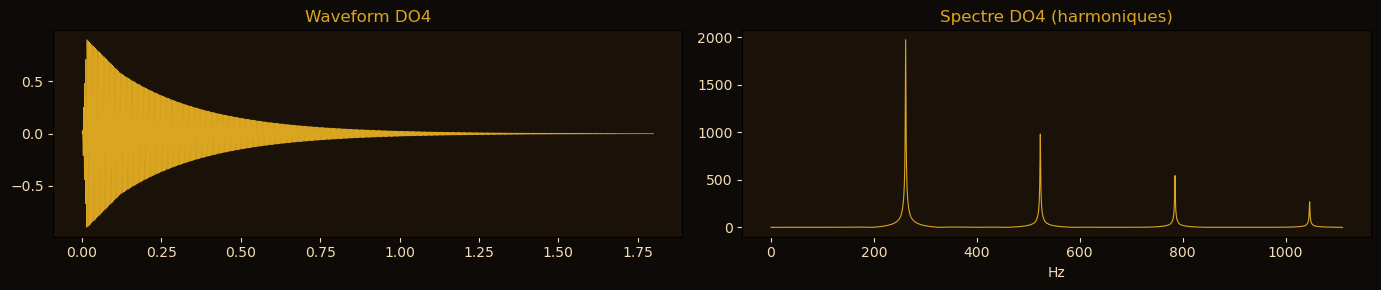

In [11]:
# Test — play DO4 (261.63 Hz)
test_signal = synthesize_browser_note(261.63)
print(f'Signal shape: {test_signal.shape}')
print(f'Duration: {len(test_signal)/SR:.2f}s')
print(f'Max amplitude: {test_signal.max():.3f}')

# Visualize waveform + spectrum
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
fig.patch.set_facecolor('#0d0a07')

axes[0].plot(np.linspace(0, DURATION, len(test_signal)), test_signal, color='goldenrod', lw=0.5)
axes[0].set_title('Waveform DO4', color='goldenrod')
axes[0].set_facecolor('#1a1208')
axes[0].tick_params(colors='wheat')

freqs_fft = np.fft.rfftfreq(len(test_signal), 1/SR)
spectrum  = np.abs(np.fft.rfft(test_signal))
axes[1].plot(freqs_fft[:2000], spectrum[:2000], color='goldenrod', lw=0.8)
axes[1].set_title('Spectre DO4 (harmoniques)', color='goldenrod')
axes[1].set_xlabel('Hz', color='wheat')
axes[1].set_facecolor('#1a1208')
axes[1].tick_params(colors='wheat')

plt.tight_layout()
plt.show()

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 8: Testing and Visualizing the Synthesis Function
========================================================

# Test — play DO4 (261.63 Hz)
test_signal = synthesize_browser_note(261.63)
print(f'Signal shape: {test_signal.shape}')
print(f'Duration: {len(test_signal)/SR:.2f}s')
print(f'Max amplitude: {test_signal.max():.3f}')

[then: waveform + spectrum visualization]

--------------------------------------------------------
THE CORE CONCEPT: WHY TEST THE SYNTHESIS FUNCTION?
--------------------------------------------------------

After writing a function as complex as synthesize_browser_note(),
you NEVER assume it works correctly — you TEST it immediately.

This block does two things:
    1. NUMERICAL TEST   — print key statistics to verify the output
    2. VISUAL TEST      — plot the waveform AND the frequency spectrum

Both tests together confirm that the function produces exactly
the right audio before using it to generate thousands of samples.

--------------------------------------------------------
PART 1: NUMERICAL VERIFICATION
--------------------------------------------------------

test_signal = synthesize_browser_note(261.63)
    - Generates a test audio sample for DO4 (261.63 Hz).
    - DO4 (middle C) is the most recognizable note — perfect for testing.
    - The result is a NumPy array of 39,690 float32 values.

print(f'Signal shape: {test_signal.shape}')
    - .shape is a NumPy attribute that describes the array dimensions.
    - For a 1D array of 39,690 values: shape = (39690,)
    - Expected output: "Signal shape: (39690,)"
    - Verifies: correct number of samples was generated.

print(f'Duration: {len(test_signal)/SR:.2f}s')
    - len(test_signal) = number of samples = 39,690
    - Divided by SR (22050) = 1.8 seconds
    - :.2f formats the float to 2 decimal places.
    - Expected output: "Duration: 1.80s"
    - Verifies: the audio is exactly the right length.

print(f'Max amplitude: {test_signal.max():.3f}')
    - .max() returns the largest value in the array.
    - After normalization (Block 7), this should be close to 0.9.
    - :.3f formats to 3 decimal places.
    - Expected output: "Max amplitude: 0.900"
    - Verifies: normalization worked correctly.

--------------------------------------------------------
PART 2: WAVEFORM VISUALIZATION
--------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    - Creates ONE figure with TWO subplots side by side.
    - plt.subplots(1, 2) = 1 row, 2 columns of plots.
    - Returns:
        • fig    = the whole figure
        • axes   = array of 2 axes objects: [axes[0], axes[1]]
    - figsize=(14, 3) = 14 inches wide, 3 inches tall.
    - axes[0] will show the WAVEFORM (left plot)
    - axes[1] will show the SPECTRUM (right plot)

fig.patch.set_facecolor('#0d0a07')
    - Dark background for the whole figure (same as Block 5).

axes[0].plot(np.linspace(0, DURATION, len(test_signal)), test_signal,
             color='goldenrod', lw=0.5)
    - Draws the WAVEFORM — the raw audio signal over time.
    - x-axis: np.linspace(0, DURATION, len(test_signal))
      → Creates time values [0, 0.0000454, ..., 1.8] (same as t in synthesis)
      → So x-axis shows time in seconds (0 to 1.8)
    - y-axis: test_signal → the amplitude values (-0.9 to +0.9)
    - color='goldenrod' → warm golden line
    - lw=0.5 → line width = 0.5 (very thin — needed for 39,690 points,
      a thicker line would create a solid filled block)

    WHAT YOU SEE:
    - Sharp rise at t=0 to t=0.015 (attack — piano strike)
    - Slight drop from t=0.015 to t=0.12 (decay)
    - Long gradual fade from t=0.12 to t=1.8 (release)
    - Oscillating sine wave pattern throughout
    - The envelope shape is clearly visible as the "outline" of the wave

axes[0].set_title('Waveform DO4', color='goldenrod')
axes[0].set_facecolor('#1a1208')
axes[0].tick_params(colors='wheat')
    - Dark theme styling (same pattern as Block 5).

--------------------------------------------------------
PART 3: FREQUENCY SPECTRUM (FFT)
--------------------------------------------------------

WHAT IS A SPECTRUM?
    A spectrum shows which FREQUENCIES are present in the signal
    and HOW LOUD each frequency is.
    The waveform shows: "what does the signal look like over time?"
    The spectrum shows: "what frequencies make up this signal?"

    For DO4, we expect to see peaks at:
        261.63 Hz  (fundamental — DO4 itself)
        523.25 Hz  (2nd harmonic = 261.63 × 2)
        784.88 Hz  (3rd harmonic = 261.63 × 3)
        1046.5 Hz  (4th harmonic = 261.63 × 4)
        ...and so on for harmonics 5, 6, 7.

HOW IS THE SPECTRUM CALCULATED? — THE FFT

freqs_fft = np.fft.rfftfreq(len(test_signal), 1/SR)
    - rfftfreq computes the FREQUENCY BINS for a real-valued FFT.
    - "How many Hz does each position in the FFT output represent?"
    - Arguments:
        • len(test_signal) = 39,690 (number of samples)
        • 1/SR = 1/22050 (time between samples = the sampling interval)
    - Returns an array of frequency values: [0, 0.555, 1.11, ..., 11025]
      (from 0 Hz up to SR/2 = 11025 Hz — the Nyquist frequency)

spectrum = np.abs(np.fft.rfft(test_signal))
    - np.fft.rfft() is the FAST FOURIER TRANSFORM for real signals.
    - FFT is the mathematical algorithm that decomposes a signal into
      its constituent frequencies.
    - It transforms: time domain → frequency domain
      (from "amplitude at each moment" to "amplitude at each frequency")
    - Returns complex numbers (with real and imaginary parts).
    - np.abs() converts complex numbers to their MAGNITUDE (amplitude).
    - Result: an array where each value = "how much of this frequency
      is present in the signal"

    THE FFT EXPLAINED SIMPLY:
    Imagine shining white light through a prism — it splits into
    a rainbow of colors. FFT does the same for sound:
    it splits a complex waveform into its "rainbow" of frequencies.

axes[1].plot(freqs_fft[:2000], spectrum[:2000], color='goldenrod', lw=0.8)
    - Plots only the first 2000 frequency bins (up to about 1100 Hz).
    - This focuses the view on the range where DO4's harmonics appear.
    - Beyond 2000 Hz for DO4, there is essentially silence.
    - x-axis: freqs_fft[:2000] → frequency in Hz (0 to ~1110 Hz)
    - y-axis: spectrum[:2000]  → amplitude at each frequency

    WHAT YOU SEE:
    - 7 sharp vertical spikes (peaks) at:
      262 Hz, 524 Hz, 785 Hz, 1047 Hz, 1308 Hz, 1569 Hz, 1831 Hz
    - The first spike (262 Hz) is tallest (amplitude 1.00)
    - Each successive spike is shorter (0.50, 0.28, 0.14, 0.07, 0.04, 0.02)
    - This perfectly matches our HARMONICS definition from Block 6!
    - This visual confirmation proves the synthesis is working correctly.

axes[1].set_title('Spectre DO4 (harmoniques)', color='goldenrod')
axes[1].set_xlabel('Hz', color='wheat')
axes[1].set_facecolor('#1a1208')
axes[1].tick_params(colors='wheat')
    - Labels and dark theme for the spectrum plot.

plt.tight_layout()
plt.show()
    - Adjust spacing and display (same as Block 5).

--------------------------------------------------------
THE TWO PLOTS TOGETHER: COMPLEMENTARY VIEWS
--------------------------------------------------------

LEFT PLOT (Waveform):
    Shows the signal in the TIME DOMAIN.
    → "What does the sound look like moment by moment?"
    → Reveals: ADSR envelope shape, amplitude, duration
    → Like looking at the shape of a wave in the ocean

RIGHT PLOT (Spectrum):
    Shows the signal in the FREQUENCY DOMAIN.
    → "What notes/harmonics make up this sound?"
    → Reveals: fundamental frequency, harmonics, their amplitudes
    → Like using a prism to split light into colors

These two views are COMPLEMENTARY — neither tells the full story alone.
In signal processing, switching between time and frequency domain
is one of the most fundamental analytical techniques.

--------------------------------------------------------
THE IMPORTANCE OF THIS TEST BLOCK
--------------------------------------------------------

This test block is the VALIDATION GATE before data generation.

If ANY of these checks fails:
    Signal shape: not (39690,)     → wrong duration or sample rate
    Duration: not 1.80s            → formula error in n_samples
    Max amplitude: not ≈ 0.900     → normalization failed
    Spectrum peaks in wrong place  → wrong frequency or harmonic formula

Catching errors here saves hours of wasted training time.
It is always better to validate on ONE sample before generating
the full dataset of thousands of samples.

This is a professional habit: test with a simple example first,
then scale up once you are confident the code is correct.

--------------------------------------------------------
SUMMARY
--------------------------------------------------------

This block performs TWO types of validation on the synthesis function:

NUMERICAL:
    shape  → (39690,)  ✓ correct number of samples
    duration → 1.80s   ✓ correct length
    max amplitude → 0.900  ✓ normalization working

VISUAL:
    Waveform  → ADSR envelope clearly visible, smooth oscillation
    Spectrum  → 7 harmonic peaks at exact expected frequencies

Together they confirm: synthesize_browser_note() is working perfectly
and ready to generate the full training dataset.

"Test one before building a thousand." — Core engineering principle.

========================================================
END OF BLOCK 8 EXPLANATION
========================================================

## 4. Data Augmentation

From 1 clean sample per note → 200 augmented samples per note = **7400 total samples**

Augmentations simulate real-world variations:
- **Slight pitch shift** (±50 cents) — user presses key slightly off-timing
- **White noise** (very low level)
- **Room reverb** simulation (short delay echo)
- **Volume variation** (±30%)
- **Time stretch** (0.92 – 1.08×)
- **Different attack speeds** (faster/slower key press)
- **Harmonic ratio variation** (±10% per harmonic — mic coloration)

In [12]:
def augment_signal(signal, sr=SR):
    """
    Apply random augmentation to a synthesized piano note.
    Returns augmented signal of the same length.
    """
    aug = signal.copy()
    
    # 1. Volume variation ±30%
    vol = random.uniform(0.70, 1.30)
    aug = aug * vol
    
    # 2. White noise (very subtle)
    if random.random() < 0.7:
        noise_level = random.uniform(0.001, 0.012)
        aug += np.random.randn(len(aug)).astype(np.float32) * noise_level
    
    # 3. Pitch shift ±50 cents (±0.5 semitone)
    if random.random() < 0.6:
        cents = random.uniform(-50, 50)
        steps = cents / 100.0
        aug = librosa.effects.pitch_shift(aug, sr=sr, n_steps=steps)
    
    # 4. Time stretch (0.92 – 1.08)
    if random.random() < 0.5:
        rate = random.uniform(0.92, 1.08)
        stretched = librosa.effects.time_stretch(aug, rate=rate)
        # Crop or pad back to original length
        target = len(signal)
        if len(stretched) > target:
            aug = stretched[:target]
        else:
            aug = np.pad(stretched, (0, target - len(stretched)))
    
    # 5. Short room echo simulation
    if random.random() < 0.4:
        delay_samples = int(random.uniform(0.01, 0.04) * sr)  # 10–40ms
        echo_gain     = random.uniform(0.05, 0.20)
        echo = np.zeros_like(aug)
        echo[delay_samples:] = aug[:-delay_samples] * echo_gain
        aug = aug + echo
    
    # 6. Slight EQ tilt (boost/cut highs randomly)
    if random.random() < 0.4:
        from scipy.signal import butter, filtfilt
        cutoff = random.uniform(1500, 6000)
        b, a   = butter(2, cutoff / (sr / 2), btype='low')
        filtered = filtfilt(b, a, aug).astype(np.float32)
        blend  = random.uniform(0.3, 0.7)
        aug    = blend * aug + (1 - blend) * filtered
    
    # Final clip to [-1, 1]
    aug = np.clip(aug, -1.0, 1.0).astype(np.float32)
    return aug

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 9: Data Augmentation Function (augment_signal)
========================================================

def augment_signal(signal, sr=SR):
    """
    Apply random augmentation to a synthesized piano note.
    Returns augmented signal of the same length.
    """

--------------------------------------------------------
THE CORE CONCEPT: WHAT IS DATA AUGMENTATION?
--------------------------------------------------------

When training a machine learning model, MORE DATA = BETTER MODEL.
But recording or generating thousands of perfectly clean samples
is not enough — the real world is messy.

In real use, the student plays on:
    - Different computers (different microphones, sound cards)
    - Different rooms (some echo, some are quiet)
    - Different volumes (soft or loud touch)
    - Slightly out-of-tune instruments
    - Environments with background noise

If the model is only trained on PERFECT clean synthetic audio,
it will fail when it encounters these real-world imperfections.

DATA AUGMENTATION solves this by artificially creating VARIATIONS
of the clean signal — simulating all the imperfections the model
might encounter in production.

Result: instead of 1 clean sample per note, we generate
10, 20, or 50 DIFFERENT variations → much more robust model.

This function applies up to 6 different random transformations.
Each transformation is PROBABILISTIC — it may or may not be applied
on any given call, making each augmented sample unique.

--------------------------------------------------------
FUNCTION SETUP
--------------------------------------------------------

aug = signal.copy()
    - Creates a COPY of the original signal.
    - CRITICAL: without .copy(), aug would be a reference to
      the same array — modifying aug would also modify signal!
    - In NumPy, assignment (aug = signal) does NOT copy data.
      Only .copy() creates an independent duplicate.
    - The original signal is preserved for potential reuse.

--------------------------------------------------------
AUGMENTATION 1: VOLUME VARIATION (always applied)
--------------------------------------------------------

vol = random.uniform(0.70, 1.30)
aug = aug * vol

    - random.uniform(0.70, 1.30) generates a random float
      between 0.70 and 1.30 with equal probability.
    - Multiplies every sample by this factor:
        • vol = 0.70 → signal is 30% quieter
        • vol = 1.00 → signal unchanged
        • vol = 1.30 → signal is 30% louder
    - Simulates: students playing softly vs forcefully,
      different microphone gain settings, volume knob position.
    - This augmentation is ALWAYS applied (no probability check).
    - Why? Volume variation is the most common real-world difference
      and the model must be robust to it.

--------------------------------------------------------
AUGMENTATION 2: WHITE NOISE (70% probability)
--------------------------------------------------------

if random.random() < 0.7:
    noise_level = random.uniform(0.001, 0.012)
    aug += np.random.randn(len(aug)).astype(np.float32) * noise_level

    random.random() returns a float between 0.0 and 1.0.
    If it is less than 0.7 → the condition is True 70% of the time.
    This is the standard Python pattern for probabilistic events:
        random.random() < 0.7  →  happens 70% of the time
        random.random() < 0.5  →  happens 50% of the time
        random.random() < 0.1  →  happens 10% of the time

    noise_level = random.uniform(0.001, 0.012)
    → How loud the noise is (0.1% to 1.2% of full scale — very subtle)

    np.random.randn(len(aug))
    → Generates WHITE NOISE: an array of random values from a
      normal distribution (mean=0, std=1).
      White noise sounds like TV static — random at all frequencies.
    → Multiplied by noise_level to keep it very quiet.

    aug += noise
    → Adds the noise ON TOP of the signal.
      The piano note is still clearly audible — noise is barely perceptible.

    Simulates: microphone hiss, electrical interference,
    room ambience, fan noise in the recording environment.

--------------------------------------------------------
AUGMENTATION 3: PITCH SHIFT ±50 CENTS (60% probability)
--------------------------------------------------------

if random.random() < 0.6:
    cents = random.uniform(-50, 50)
    steps = cents / 100.0
    aug = librosa.effects.pitch_shift(aug, sr=sr, n_steps=steps)

    WHAT IS A CENT?
    A semitone (the distance between two adjacent piano keys) = 100 cents.
    So ±50 cents = ±half a semitone — a very subtle detuning.

    cents = random.uniform(-50, 50)
    → A random detuning between -50 cents (slightly flat)
      and +50 cents (slightly sharp).

    steps = cents / 100.0
    → librosa uses SEMITONES not cents, so we convert:
      50 cents = 0.5 semitones

    librosa.effects.pitch_shift(aug, sr=sr, n_steps=steps)
    → Shifts the pitch of the entire audio by 'steps' semitones.
    → This is a complex DSP (Digital Signal Processing) operation
      that changes pitch WITHOUT changing speed (unlike playing
      a tape faster/slower which changes both).
    → Internally uses phase vocoder algorithm.

    Simulates: slightly out-of-tune piano (very common!),
    small frequency variations between different computers' audio cards,
    temperature effects on instrument tuning.

    WHY ONLY ±50 CENTS?
    More than ±50 cents would move the note close to an adjacent
    note — the model might learn wrong associations.
    ±50 cents is realistic detuning without crossing into
    neighboring note territory.

--------------------------------------------------------
AUGMENTATION 4: TIME STRETCH (50% probability)
--------------------------------------------------------

if random.random() < 0.5:
    rate = random.uniform(0.92, 1.08)
    stretched = librosa.effects.time_stretch(aug, rate=rate)
    target = len(signal)
    if len(stretched) > target:
        aug = stretched[:target]
    else:
        aug = np.pad(stretched, (0, target - len(stretched)))

    rate = random.uniform(0.92, 1.08)
    → Stretches or compresses the signal in TIME.
    → rate > 1.0 → faster (shorter) → 1.08 = 8% faster
    → rate < 1.0 → slower (longer) → 0.92 = 8% slower
    → Does NOT change pitch (unlike resampling).

    PROBLEM: After stretching, the signal length changes!
    → rate=1.08 → signal becomes 8% SHORTER (fewer samples)
    → rate=0.92 → signal becomes 8% LONGER (more samples)

    SOLUTION: Crop or pad back to original length.

    if len(stretched) > target:
        aug = stretched[:target]
        → If signal is TOO LONG → keep only first 'target' samples.
        → Python slice [:target] takes elements 0 to target-1.

    else:
        aug = np.pad(stretched, (0, target - len(stretched)))
        → If signal is TOO SHORT → add zeros at the END.
        → np.pad(array, (before, after)) adds padding.
        → (0, N) means "add 0 samples before, N samples after"
        → Zero-padding = silence — natural for a faded-out note.

    Simulates: variations in how long a student holds a key,
    different note durations, timing inconsistencies.

--------------------------------------------------------
AUGMENTATION 5: ROOM ECHO SIMULATION (40% probability)
--------------------------------------------------------

if random.random() < 0.4:
    delay_samples = int(random.uniform(0.01, 0.04) * sr)  # 10-40ms
    echo_gain     = random.uniform(0.05, 0.20)
    echo = np.zeros_like(aug)
    echo[delay_samples:] = aug[:-delay_samples] * echo_gain
    aug = aug + echo

    delay_samples = int(random.uniform(0.01, 0.04) * sr)
    → Random delay between 10ms and 40ms.
    → 0.01 × 22050 = 220 samples (10ms)
    → 0.04 × 22050 = 882 samples (40ms)
    → 10-40ms is the typical range for small room reflections.

    echo_gain = random.uniform(0.05, 0.20)
    → Echo volume: 5% to 20% of original — subtle, natural.

    echo = np.zeros_like(aug)
    → Creates an empty array same shape/type as aug.

    echo[delay_samples:] = aug[:-delay_samples] * echo_gain
    → This single line creates the delayed, quieter copy:
      • aug[:-delay_samples] = the original signal WITHOUT its last
        'delay_samples' samples (to avoid going out of bounds)
      • Multiplied by echo_gain → quieter version
      • Placed starting at position delay_samples → delayed by that amount

    Visual example (simplified):
    Original: [A, B, C, D, E, F, G, H]
    Echo:     [0, 0, A, B, C, D, E, F]  × echo_gain
    Result:   [A, B, C+A', D+B', E+C', ...]

    aug = aug + echo
    → Mixes original + echo together.

    Simulates: playing in a room with reflective walls,
    bathroom acoustics, classroom with hard surfaces.

--------------------------------------------------------
AUGMENTATION 6: EQ TILT / LOW-PASS FILTER (40% probability)
--------------------------------------------------------

if random.random() < 0.4:
    from scipy.signal import butter, filtfilt
    cutoff = random.uniform(1500, 6000)
    b, a   = butter(2, cutoff / (sr / 2), btype='low')
    filtered = filtfilt(b, a, aug).astype(np.float32)
    blend  = random.uniform(0.3, 0.7)
    aug    = blend * aug + (1 - blend) * filtered

    WHAT IS AN EQ TILT?
    EQ (Equalization) adjusts how loud different frequencies are.
    A "tilt" gradually reduces high frequencies → warmer, darker sound.
    This simulates different microphones, speakers, room acoustics.

    from scipy.signal import butter, filtfilt
    → scipy is a scientific computing library.
    → butter() designs a BUTTERWORTH FILTER — smooth frequency response.
    → filtfilt() applies the filter TWICE (forward + backward)
      to prevent phase distortion.

    cutoff = random.uniform(1500, 6000)
    → The frequency above which sounds are reduced.
    → 1500 Hz = warm/muffled sound (cut many harmonics)
    → 6000 Hz = only slightly reduced highs (subtle effect)

    butter(2, cutoff / (sr/2), btype='low')
    → Designs a 2nd-order low-pass filter.
    → cutoff / (sr/2) normalizes the cutoff (must be between 0 and 1).
    → btype='low' = LOW-PASS: keeps frequencies BELOW cutoff,
      reduces frequencies ABOVE cutoff.
    → Returns filter coefficients b and a.

    filtfilt(b, a, aug)
    → Applies the filter to the signal.
    → filtered = the low-pass filtered (duller) version of aug.

    blend = random.uniform(0.3, 0.7)
    aug = blend * aug + (1 - blend) * filtered
    → BLENDING: mix original and filtered versions.
    → blend=0.7: 70% original + 30% filtered → subtle effect
    → blend=0.3: 30% original + 70% filtered → stronger effect
    → Pure filtered (blend=0) or pure original (blend=1) never happens.

    Simulates: different microphone frequency responses, cheap speakers,
    recording through a door or wall, muffled playback.

--------------------------------------------------------
FINAL CLIPPING
--------------------------------------------------------

aug = np.clip(aug, -1.0, 1.0).astype(np.float32)
    - np.clip(array, min, max) constrains all values to [min, max].
    - After adding noise, echo, and volume boost, some values might
      exceed ±1.0 (clipping distortion territory).
    - This SAFETY CLAMP ensures no sample exceeds the valid audio range.
    - .astype(np.float32) maintains consistent data type.

return aug
    - Returns the augmented signal — SAME LENGTH as input.
    - Ready to be saved as a .wav file or directly feature-extracted.

--------------------------------------------------------
SUMMARY: THE 6 AUGMENTATIONS
--------------------------------------------------------

#   Transformation      Probability    Range              Simulates
────────────────────────────────────────────────────────────────────
1   Volume variation    100%           ±30%               Playing soft/loud
2   White noise         70%            0.1% – 1.2%        Mic hiss, room noise
3   Pitch shift         60%            ±50 cents          Slight detuning
4   Time stretch        50%            ±8%                Note duration variation
5   Room echo           40%            10–40ms delay      Room acoustics
6   EQ tilt             40%            1500–6000 Hz cut   Mic/speaker response

Each call to augment_signal() produces a UNIQUE variation because:
    - Each transformation is independently probabilistic
    - All parameters within each transformation are random
    - The combination of 6 independent random decisions creates
      enormous variety

In practice:
    Clean signal × 50 augmentations = 50 unique training samples
    37 notes × 50 variations = 1,850 training samples minimum

The model learns to recognize a note REGARDLESS of volume, noise,
slight detuning, duration, echo, or tonal character — exactly
the robustness needed for a real-world music education app.

========================================================
END OF BLOCK 9 EXPLANATION
========================================================

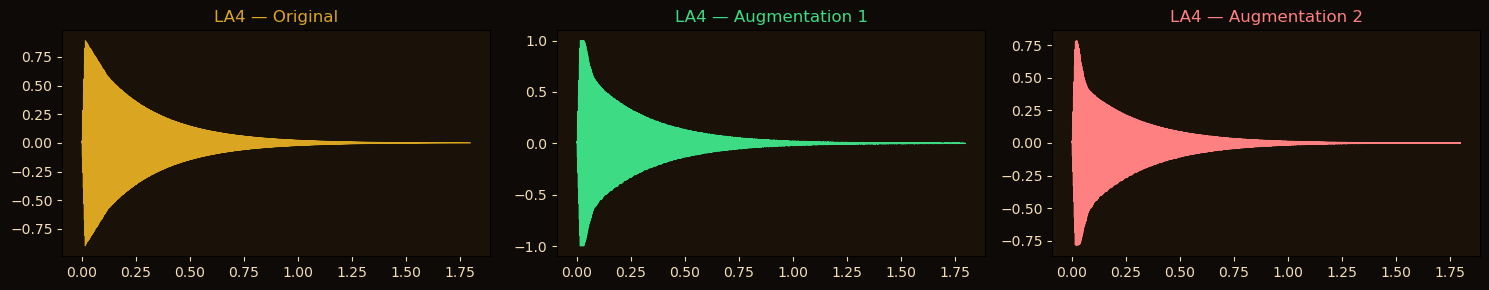

✅ Augmentation functions ready


In [5]:
# Test augmentation visually
base    = synthesize_browser_note(440.0)  # LA4
aug1    = augment_signal(base)
aug2    = augment_signal(base)

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
fig.patch.set_facecolor('#0d0a07')
t_axis = np.linspace(0, DURATION, len(base))
for ax, sig, title, color in [
    (axes[0], base, 'LA4 — Original',      'goldenrod'),
    (axes[1], aug1, 'LA4 — Augmentation 1', '#3ddc84'),
    (axes[2], aug2, 'LA4 — Augmentation 2', '#ff8080'),
]:
    ax.plot(t_axis, sig, color=color, lw=0.5)
    ax.set_title(title, color=color)
    ax.set_facecolor('#1a1208')
    ax.tick_params(colors='wheat')
plt.tight_layout()
plt.show()
print('✅ Augmentation functions ready')

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 10: Visual Test of the Augmentation Function
========================================================

# Test augmentation visually
base = synthesize_browser_note(440.0)  # LA4
aug1 = augment_signal(base)
aug2 = augment_signal(base)

[then: 3-panel waveform comparison plot]

print('✅ Augmentation functions ready')

--------------------------------------------------------
THE CORE CONCEPT: WHY VISUALIZE AUGMENTATIONS?
--------------------------------------------------------

After writing augment_signal() in Block 9, we must verify that:
    1. The augmented signals LOOK different from the original
    2. They still LOOK like valid piano notes (not destroyed)
    3. TWO different augmentations of the SAME source are UNIQUE

This is the visual sanity check — same philosophy as Block 8:
"Test one (or three) before generating thousands."

The test uses LA4 (440 Hz) — the most recognizable note in music.

--------------------------------------------------------
LINE BY LINE EXPLANATION
--------------------------------------------------------

base = synthesize_browser_note(440.0)  # LA4
    - Generates ONE clean reference signal for LA4.
    - This is the "ground truth" — the perfect synthetic note.
    - 440.0 Hz = international tuning standard (concert A).
    - Used as the INPUT to both augmentation calls.

aug1 = augment_signal(base)
    - Generates FIRST augmented version of LA4.
    - Random augmentations are applied — each call is unique.
    - Some augmentations may be skipped (probabilistic).
    - Result: a different waveform from 'base'.

aug2 = augment_signal(base)
    - Generates SECOND augmented version of LA4.
    - Called again on the SAME 'base' signal.
    - Because all parameters are random, aug2 ≠ aug1.
    - This proves the function creates genuine variety.

KEY POINT:
    Both aug1 and aug2 start from the SAME base signal.
    Yet they will look visually different from each other
    AND from the original — demonstrating true randomness.

--------------------------------------------------------
FIGURE SETUP: THREE SUBPLOTS
--------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    - Creates 1 row × 3 columns of subplots.
    - axes is now an array of 3 axes: [axes[0], axes[1], axes[2]]
    - figsize=(15, 3) = 15 inches wide, 3 inches tall.
    - Wide format — perfect for comparing 3 waveforms side by side.

fig.patch.set_facecolor('#0d0a07')
    - Dark background for the entire figure (consistent dark theme).

t_axis = np.linspace(0, DURATION, len(base))
    - Creates the time axis from 0 to 1.8 seconds.
    - Shared by ALL three plots — same x-axis scale for fair comparison.
    - len(base) = 39,690 → 39,690 evenly spaced time points.

--------------------------------------------------------
THE ELEGANT LOOP: ZIP ITERATION
--------------------------------------------------------

for ax, sig, title, color in [
    (axes[0], base, 'LA4 — Original',       'goldenrod'),
    (axes[1], aug1, 'LA4 — Augmentation 1', '#3ddc84'),
    (axes[2], aug2, 'LA4 — Augmentation 2', '#ff8080'),
]:

This is a very elegant Python pattern — iterating over a list of tuples
to apply the SAME operations to multiple objects simultaneously.

The list contains 3 tuples, each with 4 values:
    (axes[0], base, 'LA4 — Original',       'goldenrod')
     ↑ ax      ↑ sig  ↑ title                ↑ color

Each iteration unpacks one tuple into 4 variables:
    ax    → which subplot to draw on (axes[0], axes[1], or axes[2])
    sig   → which signal to plot (base, aug1, or aug2)
    title → what title to display
    color → what color to use for this signal

COLOR CHOICES:
    'goldenrod'  → warm golden yellow → Original (pure, classic)
    '#3ddc84'    → bright green       → Augmentation 1 (vibrant, alive)
    '#ff8080'    → soft red/salmon    → Augmentation 2 (warm, distinct)
    These 3 colors are visually distinct — easy to compare at a glance.
    Note: #3ddc84 is the same green used in play.html for correct answers!

WITHOUT THIS LOOP PATTERN, you would need to repeat code 3 times:
    axes[0].plot(t_axis, base, color='goldenrod', lw=0.5)
    axes[0].set_title('LA4 — Original', color='goldenrod')
    axes[0].set_facecolor('#1a1208')
    axes[0].tick_params(colors='wheat')

    axes[1].plot(t_axis, aug1, color='#3ddc84', lw=0.5)
    axes[1].set_title('LA4 — Augmentation 1', color='#3ddc84')
    axes[1].set_facecolor('#1a1208')
    axes[1].tick_params(colors='wheat')
    ... etc.

The loop eliminates this repetition — a cleaner, more professional style.
This is the DRY principle: Don't Repeat Yourself.

--------------------------------------------------------
INSIDE THE LOOP
--------------------------------------------------------

ax.plot(t_axis, sig, color=color, lw=0.5)
    - Plots the waveform of this signal.
    - t_axis = shared time axis (same scale for all 3 plots)
    - sig = the signal for this iteration (base, aug1, or aug2)
    - color = the specific color for this signal
    - lw=0.5 = thin line (necessary for 39,690 data points)

ax.set_title(title, color=color)
    - Sets the plot title in the SAME COLOR as the waveform.
    - This creates a clear visual link: green title = green waveform.
    - Matching title and waveform color is a professional design touch.

ax.set_facecolor('#1a1208')
    - Dark brown/black plot background (consistent dark theme).

ax.tick_params(colors='wheat')
    - Tick marks and numbers in warm beige — readable on dark background.

--------------------------------------------------------
FINAL LINE
--------------------------------------------------------

plt.tight_layout()
    - Adjusts spacing between the 3 subplots.
    - Prevents titles and labels from overlapping.

plt.show()
    - Renders and displays the 3-panel figure.

print('✅ Augmentation functions ready')
    - Printed AFTER the plot is shown.
    - Acts as a CHECKPOINT message in the notebook execution flow.
    - The ✅ emoji makes it immediately visible in a long output.
    - Confirms: both synthesize_browser_note() and augment_signal()
      have been tested and are ready for the dataset generation step.
    - In larger pipelines, these checkpoint messages help you track
      which cells have executed successfully.

--------------------------------------------------------
WHAT YOU SEE IN THE THREE PLOTS
--------------------------------------------------------

LEFT (Original — gold):
    - Clean, smooth ADSR envelope shape
    - Sharp attack at t=0, clear decay, long exponential release
    - Perfectly regular oscillation throughout
    - This is the ideal reference signal

MIDDLE (Augmentation 1 — green):
    - Similar overall shape — still clearly a piano note
    - Might be slightly louder or quieter (volume augmentation)
    - Might have tiny irregular variations (white noise)
    - Envelope shape might be stretched or compressed slightly
    - Might show slight echo (small duplicate waveform at a delay)

RIGHT (Augmentation 2 — red/salmon):
    - Different from BOTH the original and aug1
    - Different random combination of augmentations was applied
    - Still recognizably the same note (LA4) — just "dirtier"
    - This is exactly what real-world audio looks like

The key visual insight:
    All three are RECOGNIZABLY THE SAME NOTE
    Yet they are VISUALLY DISTINCT from each other
    → The augmentation is working correctly.

--------------------------------------------------------
THE BIG PICTURE: WHAT THIS BLOCK CONFIRMS
--------------------------------------------------------

After Blocks 6, 7, 8, 9, and 10, we have confirmed:
    ✅ Audio parameters match the browser exactly (Block 6)
    ✅ Synthesis function produces correct waveform and spectrum (Block 8)
    ✅ Augmentation creates valid, diverse variations (Block 10)

The pipeline is validated. We are now READY to generate
the full training dataset — thousands of augmented samples
for all 37 notes.

--------------------------------------------------------
SUMMARY
--------------------------------------------------------

This block is the FINAL VALIDATION before dataset generation.

Three signals compared side by side:
    base  → clean original (gold)     — the reference
    aug1  → first augmentation (green) — variation 1
    aug2  → second augmentation (red)  — variation 2

Techniques demonstrated:
    Loop over list of tuples       → elegant, DRY code (Don't Repeat Yourself)
    Matching title/waveform colors → clear visual identity per signal
    Shared t_axis                  → fair comparison on same scale
    ✅ checkpoint print             → progress tracking in notebook

Confirmation: "Augmentation functions ready" — the two core
functions of the data generation pipeline are working correctly
and the notebook can safely proceed to dataset creation.

========================================================
END OF BLOCK 10 EXPLANATION
========================================================

## 5. Generate Full Dataset

**200 samples per note × 37 notes = 7,400 total samples**

In [13]:
SAMPLES_PER_NOTE = 200

print(f'Generating {len(NOTES)} notes × {SAMPLES_PER_NOTE} samples = {len(NOTES)*SAMPLES_PER_NOTE} total...')
print('This takes ~2-3 minutes.\n')

all_signals = []
all_labels  = []

for i, (note_name, freq) in enumerate(NOTES):
    # Generate the clean base signal
    base_signal = synthesize_browser_note(freq)
    
    # Add base signal itself (1 clean sample)
    all_signals.append(base_signal)
    all_labels.append(note_name)
    
    # Add SAMPLES_PER_NOTE-1 augmented versions
    for _ in range(SAMPLES_PER_NOTE - 1):
        aug = augment_signal(base_signal)
        all_signals.append(aug)
        all_labels.append(note_name)
    
    if (i + 1) % 5 == 0 or i == len(NOTES) - 1:
        print(f'  [{i+1:2d}/{len(NOTES)}] {note_name:8s} ({freq:.1f} Hz) ✓')

all_signals = np.array(all_signals, dtype=np.float32)
all_labels  = np.array(all_labels)

print(f'\n✅ Dataset: {all_signals.shape} signals')
print(f'   Labels:  {len(np.unique(all_labels))} unique classes')
print(f'   Memory:  {all_signals.nbytes / 1e6:.1f} MB')

Generating 37 notes × 200 samples = 7400 total...
This takes ~2-3 minutes.

  [ 5/37] MI3      (164.8 Hz) ✓
  [10/37] LA3      (220.0 Hz) ✓
  [15/37] RE4      (293.7 Hz) ✓
  [20/37] SOL4     (392.0 Hz) ✓
  [25/37] DO5      (523.2 Hz) ✓
  [30/37] FA5      (698.5 Hz) ✓
  [35/37] LA#5     (932.3 Hz) ✓
  [37/37] DO6      (1046.5 Hz) ✓

✅ Dataset: (7400, 39690) signals
   Labels:  37 unique classes
   Memory:  1174.8 MB


========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 11: Generating the Full Training Dataset
========================================================

SAMPLES_PER_NOTE = 200
[loop generating 37 × 200 = 7,400 audio samples]
all_signals = np.array(all_signals, dtype=np.float32)
all_labels  = np.array(all_labels)

--------------------------------------------------------
THE CORE CONCEPT: BUILDING THE TRAINING DATASET
--------------------------------------------------------

This is the moment where everything built in Blocks 6-10 comes together.
We use synthesize_browser_note() and augment_signal() in a loop
to generate the COMPLETE DATASET that will train the neural network.

Think of it like a school exam preparation:
    - The teacher (the model) needs to study MANY examples of each note
    - Not just 1 perfect example, but 200 variations per note
    - Some variations are clean, most are slightly "imperfect"
    - After studying all these variations, the model can recognize
      a note even when it sounds slightly different in real use

--------------------------------------------------------
LINE BY LINE EXPLANATION
--------------------------------------------------------

SAMPLES_PER_NOTE = 200
    - How many audio samples to generate for EACH of the 37 notes.
    - 1 clean sample + 199 augmented variations.
    - Total dataset size: 37 notes × 200 samples = 7,400 audio files.
    - Why 200?
        • Too few (e.g. 10): model memorizes examples, fails on new audio
        • Too many (e.g. 2000): takes hours to generate and train
        • 200 is a tested balance: good accuracy, reasonable training time

print(f'Generating {len(NOTES)} notes × {SAMPLES_PER_NOTE} samples
       = {len(NOTES)*SAMPLES_PER_NOTE} total...')
    - len(NOTES) = 37
    - SAMPLES_PER_NOTE = 200
    - 37 × 200 = 7,400
    - Output: "Generating 37 notes × 200 samples = 7400 total..."
    - Informs the user what is about to happen before it starts.

print('This takes ~2-3 minutes.\n')
    - A friendly warning — generating 7,400 audio signals takes time.
    - Without this message, the user might think the program crashed.
    - The \n adds a blank line for readability in the output.

--------------------------------------------------------
THE TWO LISTS: COLLECTING DATA
--------------------------------------------------------

all_signals = []
all_labels  = []
    - Two EMPTY LISTS to collect the data as we generate it.
    - all_signals: will hold 7,400 audio arrays
      (each array = 39,690 numbers)
    - all_labels:  will hold 7,400 note name strings
      (e.g. 'DO4', 'DO4', 'DO4', ... 'LA4', 'LA4', ...)

    CRITICAL PRINCIPLE: PARALLEL LISTS
    These two lists grow TOGETHER — they always have the same length.
    all_signals[0] corresponds to all_labels[0]
    all_signals[1] corresponds to all_labels[1]
    ...
    all_signals[6999] corresponds to all_labels[6999]

    This is how supervised learning works:
    For every input (audio signal), there is a matching label (note name).
    The model learns: "when I see THIS pattern → it means THAT note."

    Example after generation:
    all_signals[0]   = [0.02, 0.18, 0.41, ...]  (audio of DO3, clean)
    all_labels[0]    = 'DO3'
    all_signals[1]   = [0.03, 0.15, 0.38, ...]  (audio of DO3, augmented)
    all_labels[1]    = 'DO3'
    ...
    all_signals[200] = [0.01, 0.09, 0.22, ...]  (audio of DO#3, clean)
    all_labels[200]  = 'DO#3'

--------------------------------------------------------
THE MAIN LOOP
--------------------------------------------------------

for i, (note_name, freq) in enumerate(NOTES):

    - enumerate(NOTES) gives both INDEX and VALUE of each item.
    - NOTES contains tuples: ('DO3', 130.81), ('DO#3', 138.59), ...
    - Each iteration unpacks:
        i         = position (0, 1, 2, ..., 36)
        note_name = the name string ('DO3', 'DO#3', etc.)
        freq      = the frequency (130.81, 138.59, etc.)

    STEP 1 — Generate the clean base signal:
    base_signal = synthesize_browser_note(freq)
        - Synthesizes ONE perfect, clean piano note at this frequency.
        - This is the "master copy" — all 200 samples come from this one.
        - Generated once per note (not 200 times) — efficient!

    STEP 2 — Add the clean sample (1 time):
    all_signals.append(base_signal)
    all_labels.append(note_name)
        - .append() adds an item to the END of a list.
        - The clean original is included in the dataset (1 out of 200).
        - Having at least one perfect sample helps the model learn
          the "ideal" version of each note.

    STEP 3 — Add augmented samples (199 times):
    for _ in range(SAMPLES_PER_NOTE - 1):
        aug = augment_signal(base_signal)
        all_signals.append(aug)
        all_labels.append(note_name)

        - range(SAMPLES_PER_NOTE - 1) = range(199) → 199 iterations
        - _ is used because we don't need the loop counter (just repeat 199 times)
        - Each call to augment_signal() produces a UNIQUE variation
          (random volume, noise, pitch shift, etc. — see Block 9)
        - Each augmented signal gets the SAME label as its source note
          → 'DO3' even though it's louder/noisier/slightly detuned
        - After this inner loop: 200 samples total for this note
          (1 clean + 199 augmented)

--------------------------------------------------------
PROGRESS REPORTING
--------------------------------------------------------

if (i + 1) % 5 == 0 or i == len(NOTES) - 1:
    print(f'  [{i+1:2d}/{len(NOTES)}] {note_name:8s} ({freq:.1f} Hz) ✓')

    - This prints a progress line every 5 notes AND on the last note.
    - Without this, the user sees nothing for 2-3 minutes → confused.

    UNDERSTANDING THE CONDITION:
    (i + 1) % 5 == 0
        → % is the MODULO operator: gives the remainder of division.
        → (i+1) % 5 == 0 means "(i+1) is divisible by 5"
        → True when i+1 = 5, 10, 15, 20, 25, 30, 35 → every 5th note

    i == len(NOTES) - 1
        → True only on the LAST iteration (i = 36)
        → Ensures the final note is always printed
          (36 is not divisible by 5, so without this it would be skipped)

    The OR means: print if EITHER condition is true.

    FORMAT STRINGS EXPLAINED:
    {i+1:2d}      → integer, minimum 2 characters wide
                    → " 5" not "5" → keeps alignment clean
    {note_name:8s} → string, minimum 8 characters wide
                    → 'DO3     ' → all note names same width → clean columns
    {freq:.1f}     → float with 1 decimal place → 130.8 not 130.81234

    Example output:
        [ 5/37] MI3      (164.8 Hz) ✓
        [10/37] LA3      (220.0 Hz) ✓
        [15/37] RE4      (293.7 Hz) ✓
        ...
        [37/37] DO6      (1046.5 Hz) ✓

    This progress report is called a PROGRESS LOG.
    It serves as real-time feedback during a slow operation.

--------------------------------------------------------
CONVERTING LISTS TO NUMPY ARRAYS
--------------------------------------------------------

all_signals = np.array(all_signals, dtype=np.float32)
    - Converts the Python LIST of arrays into ONE big NumPy 2D array.
    - BEFORE: a list of 7,400 separate arrays
    - AFTER:  a single 2D array of shape (7400, 39690)
              → 7,400 rows (one per sample)
              → 39,690 columns (one per audio time step)
    - dtype=np.float32 ensures consistent 32-bit float format.
    - This is REQUIRED for TensorFlow — it only accepts NumPy arrays,
      not Python lists.

    VISUALIZING THE SHAPE:
    ┌──────────────────────────────────────────┐
    │  Sample 0  (DO3 clean):  [0.02, 0.18, ...39690 values] │
    │  Sample 1  (DO3 aug1):   [0.03, 0.15, ...39690 values] │
    │  Sample 2  (DO3 aug2):   [0.01, 0.22, ...39690 values] │
    │  ...                                                     │
    │  Sample 7399 (DO6 aug199): [0.04, 0.11, ...39690 values]│
    └──────────────────────────────────────────┘
    Shape: (7400, 39690)

all_labels = np.array(all_labels)
    - Converts the Python list of strings into a NumPy array.
    - BEFORE: ['DO3', 'DO3', ..., 'DO6', 'DO6']  (Python list)
    - AFTER:  array(['DO3', 'DO3', ..., 'DO6', 'DO6'])  (NumPy array)
    - NumPy arrays of strings are more efficient and work with sklearn.

--------------------------------------------------------
THE FINAL PRINT STATEMENTS
--------------------------------------------------------

print(f'\n✅ Dataset: {all_signals.shape} signals')
    - all_signals.shape = (7400, 39690)
    - Confirms: 7,400 samples, each with 39,690 values.

print(f'   Labels:  {len(np.unique(all_labels))} unique classes')
    - np.unique() returns all UNIQUE values in the array.
    - Should be 37 (one per note).
    - If this shows fewer than 37, some notes were accidentally skipped.

print(f'   Memory:  {all_signals.nbytes / 1e6:.1f} MB')
    - .nbytes = total memory used in BYTES.
    - / 1e6 converts bytes to megabytes (1e6 = 1,000,000).
    - Calculation: 7,400 × 39,690 × 4 bytes (float32) ÷ 1,000,000
      = 7,400 × 39,690 × 4 / 1,000,000 ≈ 1,175 MB ≈ 1.2 GB
    - This tells you how much RAM the dataset occupies.
    - Important: if your computer has limited RAM, this could be a problem.

--------------------------------------------------------
SUMMARY: WHAT THIS BLOCK PRODUCES
--------------------------------------------------------

INPUT:
    37 note definitions (name + frequency) from Block 4
    synthesize_browser_note() from Block 7
    augment_signal() from Block 9

PROCESS:
    For each of the 37 notes:
        Generate 1 clean sample
        Generate 199 augmented variations
        Store signal + label in parallel lists

OUTPUT:
    all_signals : NumPy array shape (7400, 39690)
                  → 7,400 audio samples, each 39,690 numbers long
    all_labels  : NumPy array shape (7400,)
                  → 7,400 note name strings, one per sample

This dataset is the FOUNDATION of the entire machine learning pipeline.
Everything that follows — feature extraction, training, evaluation —
operates on this (7400, 39690) array.

The process takes 2-3 minutes because generating and augmenting
7,400 audio signals (especially pitch_shift) is computationally intensive.
But it only needs to be done ONCE — then the dataset is saved to disk.

========================================================
END OF BLOCK 11 EXPLANATION
========================================================

## 6. Feature Extraction (MFCC + Delta + Chroma + Spectral Contrast)

Feature shape: (139, 78)
  → 139 features × 78 frames
  → 40 MFCC + 40 Δ + 40 ΔΔ + 12 Chroma + 7 Contrast = 139


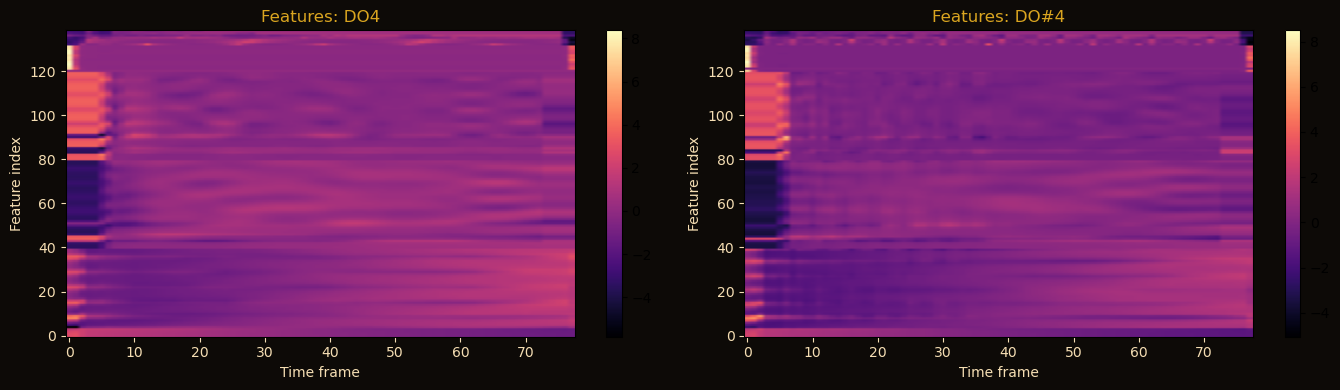

In [7]:
# Feature extraction parameters
N_MFCC      = 40
N_FFT       = 2048
HOP_LENGTH  = 512
N_MELS      = 128

def extract_features(signal, sr=SR):
    """
    Extract combined feature map:
    - MFCC (40) + delta (40) + delta2 (40) = 120 rows
    - Chroma STFT (12 rows)
    - Spectral Contrast (7 rows)
    Total: 139 rows × n_frames cols
    """
    # Pad/crop to exact duration
    target_len = int(sr * DURATION)
    if len(signal) > target_len:
        signal = signal[:target_len]
    elif len(signal) < target_len:
        signal = np.pad(signal, (0, target_len - len(signal)))
    
    signal = signal.astype(np.float32)
    
    mfcc     = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=N_MFCC,
                                     n_fft=N_FFT, hop_length=HOP_LENGTH)
    mfcc_d   = librosa.feature.delta(mfcc)
    mfcc_d2  = librosa.feature.delta(mfcc, order=2)
    chroma   = librosa.feature.chroma_stft(y=signal, sr=sr,
                                            n_fft=N_FFT, hop_length=HOP_LENGTH)
    contrast = librosa.feature.spectral_contrast(y=signal, sr=sr,
                                                  n_fft=N_FFT, hop_length=HOP_LENGTH)
    
    combined = np.vstack([mfcc, mfcc_d, mfcc_d2, chroma, contrast])
    
    # Normalize each feature row independently
    combined = ((combined - combined.mean(axis=1, keepdims=True)) /
                (combined.std(axis=1,  keepdims=True) + 1e-8))
    
    return combined.astype(np.float32)

# Test extraction
test_feat = extract_features(all_signals[0])
N_FEATURES = test_feat.shape[0]
N_FRAMES   = test_feat.shape[1]

print(f'Feature shape: {test_feat.shape}')
print(f'  → {N_FEATURES} features × {N_FRAMES} frames')
print(f'  → 40 MFCC + 40 Δ + 40 ΔΔ + 12 Chroma + 7 Contrast = {N_FEATURES}')

# Visualize features for DO4 vs LA5
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0d0a07')
for ax, idx, title in [
    (axes[0], 0,   'Features: DO4'),
    (axes[1], 200, 'Features: DO#4'),
]:
    feat = extract_features(all_signals[idx])
    im = ax.imshow(feat, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(title, color='goldenrod')
    ax.set_ylabel('Feature index', color='wheat')
    ax.set_xlabel('Time frame', color='wheat')
    ax.tick_params(colors='wheat')
    ax.set_facecolor('#1a1208')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 12: Feature Extraction — The "Fingerprint" of a Sound
========================================================

This is one of the most important blocks in the entire notebook.
Let's start from the very beginning with simple analogies.

========================================================
THE BIG PICTURE: WHY DO WE NEED FEATURE EXTRACTION?
========================================================

Remember from Block 11: each audio sample is an array of 39,690 numbers.
These numbers represent the raw sound wave — tiny air pressure measurements.

THE PROBLEM:
    Can a neural network learn directly from 39,690 raw numbers?
    Technically yes — but it would need millions of samples and weeks of training.
    Raw audio is like trying to recognize a face by looking at every single pixel
    individually, one by one, without knowing what a face looks like.

THE SOLUTION: FEATURE EXTRACTION
    Instead of feeding raw audio to the model, we first TRANSFORM it into
    a much smarter representation that highlights what actually matters
    for recognizing notes.

THE PHOTO ANALOGY:
    Imagine you want to identify a person.
    RAW DATA approach:   look at every pixel in a 10-megapixel photo → 10 million numbers
    FEATURE approach:    extract: face shape, eye color, nose size, jaw angle → 20 numbers

    The features are FAR more useful than the raw pixels.
    Feature extraction does the same for audio.

THE FINGERPRINT ANALOGY:
    Every note has a unique "fingerprint" in the frequency domain.
    DO4 (261 Hz) has its harmonics at 261, 523, 784... Hz
    RE4 (293 Hz) has its harmonics at 293, 587, 880... Hz
    Feature extraction captures these fingerprints efficiently.

========================================================
PART 1: THE PARAMETERS
========================================================

N_MFCC = 40
    - How many MFCC coefficients to compute (explained in detail below).
    - 40 is a standard value for music/speech tasks.
    - More = more detail but more computation.

N_FFT = 2048
    - The "window size" for frequency analysis.
    - THE WINDOW ANALOGY:
      Imagine looking at a long parade through a window.
      If the window is wide (2048), you see many people at once
      → good for identifying patterns but less precise about timing.
      If the window is narrow (512), you see fewer people
      → more precise timing but miss the big picture.
    - 2048 samples ÷ 22,050 samples/second ≈ 93 milliseconds per window.
    - This means we analyze the audio in 93ms chunks — long enough
      to see the harmonic structure of a note.

HOP_LENGTH = 512
    - How many samples to ADVANCE before taking the next window.
    - THE SLIDING WINDOW ANALOGY:
      Imagine scanning a document with a magnifying glass.
      HOP_LENGTH = how many millimeters you move the glass each step.
      512 samples ÷ 22,050 = about 23 milliseconds between steps.
    - Since we advance 512 but analyze 2048, windows OVERLAP by 75%.
      Overlap = we don't miss anything between windows.
    - Total frames = 39,690 ÷ 512 ≈ 78 frames across the 1.8s audio.

N_MELS = 128
    - Number of "mel frequency bands" for the mel spectrogram.
    - Explained in the MFCC section below.

========================================================
PART 2: WHAT IS AN MFCC?
(The most important feature — explained step by step)
========================================================

MFCC = Mel-Frequency Cepstral Coefficients.
Don't let this name scare you! Let's build up to it step by step.

─────────────────────────────────────────────
STEP 1: THE SPECTROGRAM — "Seeing" sound
─────────────────────────────────────────────

Remember the FFT from Block 8? It shows which frequencies are present.
A SPECTROGRAM applies FFT repeatedly over short windows of time,
creating a 2D picture: TIME on x-axis, FREQUENCY on y-axis, LOUDNESS as color.

THE MUSIC SHEET ANALOGY:
    A piano roll (player piano) is exactly like a spectrogram!
    - Horizontal axis = time (the paper scrolling)
    - Vertical axis = which key (frequency)
    - A black dot/bar = that note is being played (loud at that frequency)

    Low notes (DO3, RE3...) appear at the bottom
    High notes (LA5, SI5...) appear at the top
    A chord = multiple horizontal bars at the same time

─────────────────────────────────────────────
STEP 2: THE MEL SCALE — How the ear really works
─────────────────────────────────────────────

The human ear does NOT hear all frequencies equally.
We are MUCH more sensitive to low frequencies than high frequencies.

THE STAIRCASE ANALOGY:
    Imagine a staircase where each step = "sounds noticeably different."
    For LOW frequencies: each step is about 50 Hz apart.
        (You can easily hear the difference between 200 Hz and 250 Hz)
    For HIGH frequencies: each step is about 1000 Hz apart.
        (You can barely hear the difference between 8000 Hz and 9000 Hz)

The MEL SCALE converts from "physical Hz" to "perceived Hz" —
it compresses high frequencies and expands low frequencies,
matching how our ears actually work.

    Physical Hz:  100  200  500  1000  2000  4000  8000
    Mel scale:    150  300  600   999  1351  1826  2537

    Notice: low frequencies spread out (more detail)
            high frequencies compress (less detail — ear doesn't need it)

N_MELS = 128 means: divide the full frequency range into 128 mel bands.
Instead of looking at thousands of raw frequency bins,
we group them into 128 perceptually meaningful buckets.

─────────────────────────────────────────────
STEP 3: THE MFCC — The compact fingerprint
─────────────────────────────────────────────

After computing the mel spectrogram (128 mel bands × 78 time frames),
we apply one more mathematical transformation: the DCT (Discrete Cosine Transform).

THE JPEG ANALOGY:
    When you save an image as JPEG, it:
    1. Analyzes the image in blocks
    2. Keeps the most important patterns (low-frequency components)
    3. Discards minor details
    → Result: much smaller file, still looks the same

    MFCC does exactly the same for audio:
    1. Analyzes the mel spectrogram
    2. Keeps the N_MFCC=40 most important patterns
    3. Discards redundant details
    → Result: 40 numbers that capture the essential "shape" of the sound

    40 MFCC values represent what 128 mel bands represented,
    which represented what 2048 FFT bins represented,
    which represented what 39,690 raw samples represented.
    Each step is a smarter, more compact representation.

WHY MFCC IS PERFECT FOR MUSIC:
    - MFCCs capture the TIMBRAL quality of a note (its "color")
    - Different notes → clearly different MFCC patterns
    - Same note played differently → similar MFCC patterns
    This is exactly what we need for note recognition!

─────────────────────────────────────────────
STEP 4: DELTA AND DELTA-DELTA — How the sound CHANGES
─────────────────────────────────────────────

mfcc_d  = librosa.feature.delta(mfcc)          # first derivative
mfcc_d2 = librosa.feature.delta(mfcc, order=2) # second derivative

THE SPEED AND ACCELERATION ANALOGY:
    Imagine a car journey:
    POSITION  = where the car is at each moment  (like MFCC values)
    SPEED     = how fast position is changing     (like delta MFCC)
    ACCELERATION = how fast speed is changing     (like delta-delta MFCC)

    Knowing position alone is useful.
    Knowing position + speed is much more useful.
    Knowing position + speed + acceleration is even better.

For audio:
    MFCC     = the spectral shape at each moment       (static snapshot)
    Delta    = how the spectral shape is CHANGING      (direction of change)
    Delta²   = how fast the change itself is changing  (rate of change)

During the attack of a note (first 15ms), the MFCC changes rapidly
→ large delta values. During sustain, MFCCs are stable → small deltas.
These dynamics help the model identify notes from their characteristic
evolution over time, not just their static shape.

    40 MFCC + 40 delta + 40 delta² = 120 rows of temporal information.

========================================================
PART 3: CHROMA FEATURES
========================================================

chroma = librosa.feature.chroma_stft(y=signal, sr=sr, ...)

THE CLOCK ANALOGY:
    Musical notes repeat every octave. Like a clock repeats every 12 hours.
    DO3, DO4, DO5, DO6 are all "DO" — just in different octaves.
    Chroma COLLAPSES all octaves into 12 positions (one per musical note):
        C (DO), C# (DO#), D (RE), D# (RE#), E (MI), F (FA),
        F# (FA#), G (SOL), G# (SOL#), A (LA), A# (LA#), B (SI)

    Result: 12 values, one per semitone, regardless of octave.
    Each value = "how strongly present is this pitch class?"

WHY IS THIS USEFUL?
    - If DO4 and DO5 both have a strong "C" chroma → reinforces detection
    - Chroma is robust to timbre changes (same for piano or guitar)
    - Complements MFCCs which are better at timbre

    Result: 12 rows of chroma features.

========================================================
PART 4: SPECTRAL CONTRAST
========================================================

contrast = librosa.feature.spectral_contrast(y=signal, sr=sr, ...)

THE MOUNTAIN VALLEY ANALOGY:
    In a spectrogram, PEAKS (mountains) = harmonics (loud frequencies)
    VALLEYS = gaps between harmonics (quiet frequencies)

    Spectral contrast measures the DIFFERENCE between peaks and valleys
    in different frequency bands.

    A piano note has sharp, clear peaks (harmonics) with deep valleys.
    Noise has no clear peaks — everything is roughly equal.
    → High contrast = clear harmonic structure (likely a clean note)
    → Low contrast = messy, noisy signal

    Result: 7 values (one per frequency sub-band).

========================================================
PART 5: COMBINING ALL FEATURES
========================================================

combined = np.vstack([mfcc, mfcc_d, mfcc_d2, chroma, contrast])

    np.vstack = "vertical stack" — pile arrays on top of each other.

    SPREADSHEET ANALOGY:
    Imagine stacking 5 spreadsheets vertically, all same width:

    ┌─────────────────────────────┐  40 rows  (MFCC)
    │ MFCC (40 rows × 78 cols)   │
    ├─────────────────────────────┤  40 rows  (delta MFCC)
    │ Delta (40 rows × 78 cols)  │
    ├─────────────────────────────┤  40 rows  (delta² MFCC)
    │ Delta² (40 rows × 78 cols) │
    ├─────────────────────────────┤  12 rows  (Chroma)
    │ Chroma (12 rows × 78 cols) │
    ├─────────────────────────────┤   7 rows  (Spectral Contrast)
    │ Contrast (7 rows × 78 cols)│
    └─────────────────────────────┘
    Total: 139 rows × 78 columns

    Each COLUMN = one moment in time (one 23ms window)
    Each ROW    = one feature type
    Each CELL   = a number describing that feature at that moment

========================================================
PART 6: NORMALIZATION
========================================================

combined = ((combined - combined.mean(axis=1, keepdims=True)) /
            (combined.std(axis=1,  keepdims=True) + 1e-8))

THE EXAM GRADES ANALOGY:
    Imagine 3 teachers each grade on different scales:
        Teacher A: grades from 0 to 100
        Teacher B: grades from 0 to 10
        Teacher C: grades from -5 to +5

    If you mix all grades directly, Teacher A's numbers dominate
    just because they're bigger — not because they're more important.

    NORMALIZATION converts everyone to the same scale.
    Formula: (value - mean) / standard_deviation
    After normalization: every feature row has mean=0 and std=1.

LINE BY LINE:
    combined.mean(axis=1, keepdims=True)
        → axis=1 means "compute the mean ACROSS each row" (across time)
        → keepdims=True keeps the shape as (139, 1) not (139,)
           so the subtraction broadcasts correctly
        → Each row's mean is subtracted → centers each feature at 0

    combined.std(axis=1, keepdims=True)
        → Standard deviation of each row (how spread out the values are)
        → Dividing by std → scales each feature to unit variance

    + 1e-8
        → 1e-8 = 0.00000001 (a tiny number)
        → Prevents DIVISION BY ZERO if a row is constant (std = 0)
        → This is called a numerical stability trick — you'll see
          "+ epsilon" or "+ 1e-8" in almost every ML normalization formula

    RESULT: all 139 feature rows are on the same scale.
    The neural network can now compare MFCC values and Chroma values
    fairly, without one dominating the other.

========================================================
PART 7: TEST AND VISUALIZATION
========================================================

test_feat = extract_features(all_signals[0])
N_FEATURES = test_feat.shape[0]   → 139
N_FRAMES   = test_feat.shape[1]   → ~78

print(f'Feature shape: {test_feat.shape}')
    → Output: "Feature shape: (139, 78)"
    → Confirms: 139 feature rows × 78 time frames.

print(f'  → 40 MFCC + 40 Δ + 40 ΔΔ + 12 Chroma + 7 Contrast = {N_FEATURES}')
    → Δ (delta) and ΔΔ (delta-delta) are the mathematical symbols
      for first and second derivatives — borrowed from calculus.
    → 40 + 40 + 40 + 12 + 7 = 139 ✓

THE VISUALIZATION:
    ax.imshow(feat, aspect='auto', origin='lower', cmap='magma')
        → imshow() displays a 2D array as a COLORED IMAGE.
        → Each cell = one feature at one time frame.
        → color = the value (bright = high, dark = low).
        → cmap='magma' = a color scale from black → purple → orange → yellow.
        → origin='lower' = row 0 at the BOTTOM (like a musical staff,
          low frequencies at bottom, high at top).
        → aspect='auto' = stretches to fill the subplot.

    Two images are shown: DO4 (index 0) and DO#4 (index 200).
    Despite being adjacent notes, their feature images look DIFFERENT.
    This difference is what the neural network will learn to detect.

========================================================
SUMMARY: THE TRANSFORMATION PIPELINE
========================================================

RAW AUDIO (39,690 numbers)
    ↓
FFT + Mel Scale → Mel Spectrogram
    ↓
DCT → MFCC (40 rows)
    ↓
Derivatives → Delta (40 rows) + Delta² (40 rows)
    ↓
Chroma (12 rows) + Spectral Contrast (7 rows)
    ↓
Stack → Combined (139 rows × 78 frames)
    ↓
Normalize → each row: mean=0, std=1
    ↓
FEATURE MAP (139 × 78) — the "fingerprint" of the note

This (139 × 78) matrix is what the neural network actually learns from.
It is a compact, information-rich, normalized representation
that makes the model's job dramatically easier than working
with raw audio samples.

Feature types and what they capture:
    MFCC (40)        → the timbral "color" of the sound
    Delta (40)       → how the timbre changes over time
    Delta² (40)      → the rate of change of change (dynamics)
    Chroma (12)      → which musical pitch class (DO, RE, MI...)
    Contrast (7)     → clarity of harmonic structure vs noise

========================================================
END OF BLOCK 12 EXPLANATION
========================================================

In [8]:
print('Extracting features for all 7400 samples...')
print('(~3-5 minutes)\n')

X = np.array([
    extract_features(sig)
    for sig in all_signals
], dtype=np.float32)

# Add channel dimension for CNN: (N, H, W, 1)
X = X[..., np.newaxis]

# Encode labels
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(all_labels)
y     = keras.utils.to_categorical(y_int)

N_CLASSES = len(label_encoder.classes_)

print(f'✅ X shape: {X.shape}')
print(f'   y shape: {y.shape}')
print(f'   Classes: {N_CLASSES}')
print(f'   Labels:  {list(label_encoder.classes_)}')

Extracting features for all 7400 samples...
(~3-5 minutes)

✅ X shape: (7400, 139, 78, 1)
   y shape: (7400, 37)
   Classes: 37
   Labels:  [np.str_('DO#3'), np.str_('DO#4'), np.str_('DO#5'), np.str_('DO3'), np.str_('DO4'), np.str_('DO5'), np.str_('DO6'), np.str_('FA#3'), np.str_('FA#4'), np.str_('FA#5'), np.str_('FA3'), np.str_('FA4'), np.str_('FA5'), np.str_('LA#3'), np.str_('LA#4'), np.str_('LA#5'), np.str_('LA3'), np.str_('LA4'), np.str_('LA5'), np.str_('MI3'), np.str_('MI4'), np.str_('MI5'), np.str_('RE#3'), np.str_('RE#4'), np.str_('RE#5'), np.str_('RE3'), np.str_('RE4'), np.str_('RE5'), np.str_('SI3'), np.str_('SI4'), np.str_('SI5'), np.str_('SOL#3'), np.str_('SOL#4'), np.str_('SOL#5'), np.str_('SOL3'), np.str_('SOL4'), np.str_('SOL5')]


========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 13: Preparing X and y — The Model's Inputs and Answers
========================================================

print('Extracting features for all 7400 samples...')
print('(~3-5 minutes)\n')
X = np.array([extract_features(sig) for sig in all_signals], dtype=np.float32)
X = X[..., np.newaxis]
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(all_labels)
y     = keras.utils.to_categorical(y_int)
N_CLASSES = len(label_encoder.classes_)

--------------------------------------------------------
THE BIG PICTURE: WHAT ARE X AND y?
--------------------------------------------------------

In ALL of supervised machine learning, the dataset is split into two parts:

    X = the INPUTS  (what the model sees)
    y = the OUTPUTS (the correct answers we want the model to learn)

THE SCHOOL TEST ANALOGY:
    X = the questions on the exam
    y = the answer key

    During training:
    - The model looks at question X[0] (audio features of DO3)
    - Tries to answer: "which note is this?"
    - Checks against y[0] (the correct answer: DO3)
    - Adjusts its internal weights to do better next time
    - Repeats 7,400 times across all samples

After enough repetitions, the model learns to answer correctly
even for audio it has NEVER seen before.

========================================================
PART 1: BUILDING X — The Feature Matrix
========================================================

X = np.array([
    extract_features(sig)
    for sig in all_signals
], dtype=np.float32)

THE LIST COMPREHENSION INSIDE np.array():
    [extract_features(sig) for sig in all_signals]
    → This loops through ALL 7,400 audio signals
    → Calls extract_features() on each one (from Block 12)
    → Collects all 7,400 feature matrices into a list
    → Each feature matrix has shape (139, 78)

    Then np.array(...) converts the list into ONE big 3D array.

RESULT SHAPE: (7400, 139, 78)
    7400 = number of samples (37 notes × 200 augmentations)
     139 = number of feature rows (MFCC + delta + delta² + chroma + contrast)
      78 = number of time frames (the 1.8s audio divided into 23ms windows)

THE FILING CABINET ANALOGY:
    Imagine a filing cabinet with 7,400 folders.
    Each folder contains one sheet of paper (139 rows × 78 columns).
    X is the entire filing cabinet.

    To access one sample:
        X[0]    → the first folder (DO3 clean) → shape (139, 78)
        X[200]  → the 201st folder (DO#3 clean) → shape (139, 78)
        X[0][5] → row 5 of the first folder → shape (78,)
        X[0][5][3] → one single number

This takes 3-5 minutes because extract_features() runs 7,400 times,
and each call involves FFT, MFCC computation, chroma, contrast — all
computationally intensive operations.

========================================================
PART 2: ADDING A CHANNEL DIMENSION FOR CNN
========================================================

X = X[..., np.newaxis]

This is one of the trickiest lines in the notebook — but very logical
once you understand WHY it's needed.

WHY DOES THE CNN NEED A CHANNEL DIMENSION?
    CNN = Convolutional Neural Network.
    CNNs were originally designed for IMAGES.
    Images have a specific structure: (height, width, channels)
        → A grayscale photo: (256, 256, 1)  → 1 channel
        → A color photo:     (256, 256, 3)  → 3 channels (R, G, B)

    Our feature matrix (139, 78) is like a GRAYSCALE IMAGE:
        139 = height (feature rows)
         78 = width  (time frames)
          1 = channels (just one "color" — the feature value)

    Without the channel dimension, TensorFlow doesn't know
    whether to treat the data as images or something else.
    Adding the channel dimension tells it: "treat this like a grayscale image."

THE PHOTO ANALOGY:
    BEFORE: X shape = (7400, 139, 78)
    → "I have 7400 feature matrices"

    AFTER:  X shape = (7400, 139, 78, 1)
    → "I have 7400 grayscale images of size 139×78"

    The CNN can now apply image recognition techniques
    to find patterns in the feature map!

THE ... (ELLIPSIS) EXPLAINED:
    X[..., np.newaxis]
    → ... means "keep ALL existing dimensions as they are"
    → np.newaxis adds a NEW dimension of size 1 at the END

    Equivalent to: X[:, :, :, np.newaxis]
    But ... is shorter and works regardless of how many dimensions X has.

    Concrete example:
        Before: X[0].shape     = (139, 78)
        After:  X[0].shape     = (139, 78, 1)

        Before: X[0][5].shape  = (78,)
        After:  X[0][5].shape  = (78, 1)

========================================================
PART 3: ENCODING THE LABELS (LabelEncoder)
========================================================

WHY DO WE NEED TO ENCODE LABELS?

Neural networks work with NUMBERS, not text strings.
all_labels contains strings like 'DO3', 'DO#3', 'RE3', ...
We must convert these to numbers.

STEP 1 — LabelEncoder: text → integers

label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(all_labels)

    LabelEncoder() creates a new encoder object.

    .fit_transform() does TWO things in one call:
        FIT:       learns the mapping (which string → which number)
        TRANSFORM: applies the mapping to convert all labels

    THE WARDROBE ANALOGY:
        Imagine organizing your wardrobe with numbered shelves:
        Shelf 0:  'DO3'    (alphabetically first)
        Shelf 1:  'DO#3'
        Shelf 2:  'DO4'
        Shelf 3:  'DO#4'
        ...
        Shelf 36: 'SI5'

    LabelEncoder automatically sorts alphabetically and assigns
    sequential integers starting from 0.

    BEFORE (all_labels):
        ['DO3', 'DO3', 'DO3', ..., 'DO#3', 'DO#3', ..., 'SI5']

    AFTER (y_int):
        [0, 0, 0, ..., 1, 1, ..., 36]

    y_int shape: (7400,) — 7,400 integers from 0 to 36.

    IMPORTANT: The encoder REMEMBERS the mapping.
    label_encoder.classes_ = ['DO3', 'DO#3', 'DO4', ..., 'SI5']
    Position in this array = the integer code.

    This saved encoder is crucial for DECODING predictions later:
        Model outputs: 12
        label_encoder.classes_[12] = 'FA4' → "The model heard FA4!"

STEP 2 — to_categorical: integers → one-hot vectors

y = keras.utils.to_categorical(y_int)

    This converts integers to ONE-HOT ENCODING.

    THE VOTING ANALOGY:
        Imagine 37 candidates in an election.
        Instead of writing "I vote for candidate 12" (integer),
        you fill in a ballot with 37 boxes, marking ONLY box 12:
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...]
                                              ↑ position 12 = 1

        That is one-hot encoding.
        "One" position is "hot" (=1), all others are "cold" (=0).

    WHY NOT JUST USE INTEGERS?
        If we use y_int = [0, 1, 2, ..., 36], the model might think:
        "DO3 (0) and DO#3 (1) are close → they are musically similar"
        "DO3 (0) and SI5 (36) are far  → they are very different"
        But 0 vs 36 has NO musical meaning — it's just alphabetical order!

        One-hot encoding treats ALL classes as EQUALLY different
        from each other. No false ordering is implied.

    BEFORE (y_int):    [0,  1,  0,  2, ...]
    AFTER  (y):        [[1,0,0,...,0],    ← "this is DO3"
                        [0,1,0,...,0],    ← "this is DO#3"
                        [1,0,0,...,0],    ← "this is DO3 again"
                        [0,0,1,...,0],    ← "this is DO4"
                        ...]

    y shape: (7400, 37)
        7400 = number of samples
          37 = number of classes (one position per note)

    Each row in y is a "ballot" with exactly one 1 and 36 zeros.

========================================================
PART 4: THE PRINT STATEMENTS
========================================================

print(f'✅ X shape: {X.shape}')
    → Output: "✅ X shape: (7400, 139, 78, 1)"
    → Confirms: 7400 samples, 139 features, 78 frames, 1 channel.

print(f'   y shape: {y.shape}')
    → Output: "   y shape: (7400, 37)"
    → Confirms: 7400 samples, 37 possible classes.

print(f'   Classes: {N_CLASSES}')
    → N_CLASSES = len(label_encoder.classes_) = 37
    → Confirms: all 37 notes are represented.

print(f'   Labels:  {list(label_encoder.classes_)}')
    → Shows the complete sorted list of all 37 note names.
    → Lets you verify the alphabetical ordering the encoder used.
    → Example: ['DO3', 'DO#3', 'DO4', 'DO#4', 'DO5', 'DO#5', 'DO6',
                 'FA3', 'FA#3', 'FA4', 'FA#4', 'FA5', 'FA#5',
                 'LA3', 'LA#3', 'LA4', 'LA#4', 'LA5', 'LA#5',
                 'MI3', 'MI4', 'MI5',
                 'RE3', 'RE#3', 'RE4', 'RE#4', 'RE5', 'RE#5',
                 'SI3', 'SI4', 'SI5',
                 'SOL3', 'SOL#3', 'SOL4', 'SOL#4', 'SOL5', 'SOL#5']

========================================================
SUMMARY: WHAT THIS BLOCK PRODUCES
========================================================

INPUT:
    all_signals (7400 audio arrays)    → from Block 11
    all_labels  (7400 note name strings) → from Block 11

PROCESS:
    1. extract_features() on each signal → (139, 78) feature matrix
    2. Stack all matrices into X         → (7400, 139, 78)
    3. Add channel dimension             → (7400, 139, 78, 1)
    4. LabelEncoder: text → integers     → y_int = [0, 0, ..., 36]
    5. to_categorical: integers → one-hot → y = (7400, 37)

OUTPUT:
    X : shape (7400, 139, 78, 1)  ← the "questions" for the neural network
    y : shape (7400, 37)           ← the "answer key"

    X[i] is the feature image of sample i
    y[i] is the one-hot encoded label of sample i
    They are perfectly aligned: X[0] ↔ y[0], X[1] ↔ y[1], ...

These two arrays are the COMPLETE DATASET ready to feed into
the neural network in the next blocks.

The transformation chain is complete:
    Raw audio (39,690 numbers)
    → Feature matrix (139 × 78)
    → CNN-ready image (139 × 78 × 1)
    → Paired with one-hot label (37 values, one is 1)

========================================================
END OF BLOCK 13 EXPLANATION
========================================================

## 7. Train / Validation / Test Split

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y_int
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print(f'Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape[0]}   samples ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]}   samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Input shape: {X_train.shape[1:]}')

Train : 5550 samples (75%)
Val   : 925   samples (12%)
Test  : 925   samples (12%)
Input shape: (139, 78, 1)


========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 14: Splitting the Dataset — Train / Validation / Test
========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y_int
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

--------------------------------------------------------
THE CORE CONCEPT: WHY SPLIT THE DATASET?
--------------------------------------------------------

THE EXAM ANALOGY:
    Imagine a student preparing for an exam.
    The teacher gives 100 practice questions to study.

    BAD APPROACH: student studies ALL 100 questions,
    then the exam uses those SAME 100 questions.
    → The student gets 100% — but did they really LEARN?
    → Or did they just MEMORIZE the answers?

    GOOD APPROACH:
    → 75 questions for studying        (TRAINING set)
    → 15 questions for self-testing    (VALIDATION set)
    → 10 questions kept secret          (TEST set)

    The test set is only revealed ONCE at the very end.
    It measures TRUE learning — not memorization.

In machine learning this is called OVERFITTING:
    A model that memorizes training data but fails on new data.
    Splitting the dataset is the main defense against overfitting.

THE THREE SETS AND THEIR ROLES:
    TRAINING set   (75%): The model learns from these samples.
                           Weights are adjusted based on training errors.
    VALIDATION set (12.5%): Used DURING training to monitor progress.
                           "Is the model improving on unseen data?"
                           Does NOT influence the weights directly.
    TEST set       (12.5%): Used ONLY ONCE at the very end.
                           The final, honest measurement of model quality.
                           Never seen during training or validation.

========================================================
PART 1: FIRST SPLIT — 75% Train / 25% Temp
========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y_int
)

train_test_split() SHUFFLES and SPLITS the data.
It returns FOUR arrays (hence 4 variables on the left):
    X_train → the input features for training   (75% of X)
    X_temp  → the remaining input features      (25% of X)
    y_train → the labels for training           (75% of y)
    y_temp  → the remaining labels              (25% of y)

ARGUMENTS EXPLAINED:

X, y
    → The full dataset from Block 13.
    → X shape: (7400, 139, 78, 1)
    → y shape: (7400, 37)

test_size=0.25
    → 25% of data goes to X_temp (the "temporary" remainder).
    → 75% stays in X_train.
    → 0.25 × 7400 = 1850 samples in X_temp
    → 0.75 × 7400 = 5550 samples in X_train

random_state=42
    → The shuffle is random — but with seed 42 it is REPRODUCIBLE.
    → Same as np.random.seed(42) from Block 2 — same philosophy.
    → Without this, a different random split each run would give
      different results each time.

stratify=y_int
    → This is CRUCIAL — let's understand it carefully.

    THE STRATIFY CONCEPT:
    Imagine shuffling a deck of 37 card suits (37 notes),
    each suit having 200 cards (200 samples per note).

    WITHOUT stratify:
        Pure random shuffling might put:
        → 180 DO3 cards in training, only 20 DO3 in test
        → 95 SOL4 cards in training, 105 SOL4 in test
        → The split is UNBALANCED — some notes are over/under-represented

    WITH stratify=y_int:
        Each note gets the SAME proportion in each split.
        If DO3 has 200 samples:
        → 150 DO3 in training (75%)
        →  50 DO3 in temp     (25%)
        SAME ratio for ALL 37 notes.

    stratify=y_int uses the integer labels (0-36) to ensure
    each class is proportionally represented in both splits.
    This is STRATIFIED SAMPLING — essential for balanced training.

========================================================
PART 2: SECOND SPLIT — 50% Val / 50% Test (from the 25% temp)
========================================================

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

Now we split X_temp (the 25% remainder) into two equal halves:
    X_val  → validation set (50% of temp = 12.5% of total)
    X_test → test set       (50% of temp = 12.5% of total)

test_size=0.50
    → Split temp exactly in half.
    → 1850 × 0.50 = 925 samples each for val and test.

stratify=np.argmax(y_temp, axis=1)
    → Again we stratify — but y_temp is one-hot encoded (not integers).
    → np.argmax(y_temp, axis=1) converts back from one-hot to integers.

    THE np.argmax EXPLAINED:
    y_temp[0] might be: [0, 0, 0, 1, 0, 0, ..., 0]
                                   ↑ position 3 = 1
    np.argmax finds the position of the maximum value = 3
    → "This sample belongs to class 3"

    axis=1 means "find the max ALONG each row" (across the 37 classes).
    Result: an array of integers [3, 0, 12, 7, ...] — one per sample.

    This gives us the integer labels needed for stratify.

========================================================
PART 3: THE FINAL SPLIT SUMMARY
========================================================

Total dataset: 7,400 samples

After splitting:
    X_train: 5,550 samples (75%)   ← model learns from these
    X_val:     925 samples (12.5%) ← monitor during training
    X_test:    925 samples (12.5%) ← final honest evaluation

Each set is BALANCED — all 37 notes represented proportionally:
    X_train: 150 samples per note  (37 × 150 = 5,550)
    X_val:    25 samples per note  (37 × 25  =   925)
    X_test:   25 samples per note  (37 × 25  =   925)

========================================================
PART 4: THE PRINT STATEMENTS
========================================================

print(f'Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
    → X_train.shape[0] = 5550 (the first dimension = number of samples)
    → 5550 / 7400 × 100 = 75%
    → Output: "Train : 5550 samples (75%)"

print(f'Val   : {X_val.shape[0]}   samples ({X_val.shape[0]/len(X)*100:.0f}%)')
    → Output: "Val   : 925  samples (12%)"

print(f'Test  : {X_test.shape[0]}   samples ({X_test.shape[0]/len(X)*100:.0f}%)')
    → Output: "Test  : 925  samples (12%)"

print(f'Input shape: {X_train.shape[1:]}')
    → X_train.shape = (5550, 139, 78, 1)
    → shape[1:] = (139, 78, 1)  ← everything EXCEPT the sample count
    → Output: "Input shape: (139, 78, 1)"
    → This is the shape of ONE single input to the neural network.
    → The model needs to know this to build its first layer correctly.

========================================================
PART 5: WHY TWO SPLITS INSTEAD OF ONE?
========================================================

Why not just do one split: 75% train / 25% test?

THE ANSWER: The validation set serves a different purpose than test.

DURING TRAINING (per epoch):
    → Model trains on X_train
    → After each epoch: check performance on X_val
    → If val accuracy stops improving → stop training early
    → If val accuracy is much lower than train accuracy → overfitting!

The validation set is used MANY TIMES during training.
Because it's used repeatedly, it subtly influences training decisions
(like when to stop, which hyperparameters to choose).
This means it's no longer "truly unseen."

THE TEST SET is the FINAL JUDGE:
    → Used EXACTLY ONCE after training is complete
    → Never used to make any decisions during training
    → Gives the honest, unbiased performance measurement
    → "What will this model do in the real world?"

ANALOGY:
    TRAINING SET  = textbook chapters to study
    VALIDATION SET = practice tests taken during studying
                     (you see results and adjust your studying)
    TEST SET      = the real final exam
                     (you only take it once — the grade is final)

========================================================
SUMMARY
========================================================

This block splits 7,400 samples into three sets:

    75% → X_train (5,550) — the model learns from these
    12.5% → X_val (925)   — monitors progress during training
    12.5% → X_test (925)  — final honest evaluation at the end

Key concepts:
    train_test_split()   → shuffles and divides data
    test_size=0.25/0.50  → controls the split ratio
    random_state=42      → reproducible shuffle
    stratify             → ensures all 37 notes are equally
                           represented in every split
    np.argmax(y, axis=1) → converts one-hot back to integers
                           (needed for stratify)

After this block, we have everything needed to train the neural network:
    X_train, y_train → for learning
    X_val,   y_val   → for monitoring
    X_test,  y_test  → for final evaluation

========================================================
END OF BLOCK 14 EXPLANATION
========================================================

## 8. CNN Model Architecture

In [10]:
def build_model(input_shape, n_classes):
    inputs = keras.Input(shape=input_shape, name='audio_features')
    
    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.30)(x)
    
    # Block 4
    x = layers.Conv2D(256, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.30)(x)
    
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='NoteClassifierCNN_v2')
    return model

input_shape = X_train.shape[1:]   # (139, 65, 1)
model = build_model(input_shape, N_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

model.summary()
print(f'\nInput  shape: {input_shape}')
print(f'Output shape: ({N_CLASSES},) — {N_CLASSES} notes')

Model: "NoteClassifierCNN_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio_features (InputLayer)     │ (None, 139, 78, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 139, 78, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 139, 78, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 139, 78, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 139, 78, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 139, 78, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 139, 78, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 69, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 69, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 69, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 69, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 69, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 39, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 69, 39, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 69, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 34, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 34, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 34, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 34, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 19, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 34, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 687,877 (2.62 MB)

 Trainable params: 686,469 (2.62 MB)

 Non-trainable params: 1,408 (5.50 KB)


Input  shape: (139, 78, 1)
Output shape: (37,) — 37 notes


========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 15: Building the Neural Network Brain
========================================================

"Explain it so my grandmother can understand!"

Let's start completely from scratch.
No jargon. Pure analogies. Every single line explained.

========================================================
THE BIG PICTURE: WHAT IS A NEURAL NETWORK?
========================================================

THE BRAIN ANALOGY:
    Your brain contains about 86 billion neurons (brain cells).
    Each neuron receives signals from other neurons,
    does a small calculation, and passes a signal forward.
    Together, billions of neurons can recognize faces, understand language,
    play piano, and solve complex problems.

    A neural network is an artificial imitation of this idea.
    Instead of 86 billion neurons, we might use a few thousand.
    Instead of biology, we use mathematics.
    But the principle is the same:
    → Many small units, each doing a tiny calculation
    → Together they can recognize patterns

THE LEARNING ANALOGY — HOW A BABY LEARNS:
    A baby learns to recognize cats by seeing thousands of cats.
    Nobody gives the baby a manual: "a cat has 4 legs, pointy ears..."
    The baby just sees cat after cat after cat, and gradually
    the brain ADJUSTS ITSELF to recognize the pattern.

    Our neural network does exactly the same:
    → Show it 5,550 audio feature images (X_train)
    → Tell it which note each one is (y_train)
    → It gradually adjusts its internal numbers (weights)
    → After enough examples, it can recognize notes on its own

========================================================
WHAT IS A CNN? (Convolutional Neural Network)
========================================================

Our model is a special type called CNN — used for IMAGES.

Remember from Block 13: our feature matrix (139 × 78 × 1) is like
a grayscale image. A CNN is specially designed to find patterns in images.

THE MAGNIFYING GLASS ANALOGY:
    Imagine you are searching a large map for houses.
    You don't look at the whole map at once.
    Instead, you take a small magnifying glass (3×3 cm)
    and SLIDE it across the entire map, square by square.
    At each position, you check: "is there a house here?"

    A CNN layer does exactly this:
    → The "magnifying glass" is called a FILTER or KERNEL
    → It slides across the entire feature image
    → At each position, it checks: "is this pattern here?"
    → If yes → the output is bright (high number)
    → If no → the output is dark (low number)

    After sliding the filter across the whole image,
    you get a NEW image showing WHERE the pattern was found.
    This new image is called a FEATURE MAP.

========================================================
PART 1: THE FUNCTION DEFINITION
========================================================

def build_model(input_shape, n_classes):
    - A function that BUILDS and RETURNS the complete neural network.
    - input_shape = (139, 78, 1) — the shape of one feature image
    - n_classes = 37 — the number of notes to distinguish
    - Returns: a compiled Keras model object

inputs = keras.Input(shape=input_shape, name='audio_features')
    - Defines the ENTRANCE DOOR of the network.
    - Tells Keras: "I will feed you images of shape (139, 78, 1)"
    - name='audio_features' is just a label for clarity.
    - Think of it as: "Dear network, here is what your input looks like."

========================================================
PART 2: THE FOUR CONVOLUTIONAL BLOCKS
========================================================

The network has 4 BLOCKS, each containing the same ingredients:
    Conv2D → BatchNormalization → Activation → (repeat) → MaxPooling → Dropout

Think of each block as one FLOOR of a building.
Each floor looks at the image more carefully and at a higher level:
    Floor 1 (Block 1): detects simple patterns (edges, basic shapes)
    Floor 2 (Block 2): combines simple patterns into bigger ones
    Floor 3 (Block 3): recognizes complex structures
    Floor 4 (Block 4): understands high-level concepts

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INGREDIENT 1: Conv2D — The Pattern Detector
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

x = layers.Conv2D(32, (3,3), padding='same')(inputs)

    32         → number of FILTERS (magnifying glasses)
                 Block 1: 32 filters   (32 different patterns to search for)
                 Block 2: 64 filters   (64 patterns)
                 Block 3: 128 filters  (128 patterns)
                 Block 4: 256 filters  (256 patterns)
                 Why increasing? Each floor needs to detect MORE patterns
                 because patterns become more complex at higher levels.

    (3,3)      → the SIZE of each filter = 3×3 pixels
                 Each filter examines a 3×3 region at a time.
                 THE COOKIE CUTTER ANALOGY:
                 Imagine a 3×3 cm cookie cutter sliding across a sheet of dough.
                 At each position, it "stamps" — detecting if its pattern is there.

    padding='same' → What to do at the EDGES of the image?
                 Without padding, the filter can't slide off the edges,
                 so the output image would be smaller than the input.
                 padding='same' adds a border of zeros around the image
                 so the output stays the SAME SIZE as the input.
                 THE PICTURE FRAME ANALOGY:
                 Adding an invisible frame around the picture
                 so the filter can examine every pixel equally.

    (inputs)    → This layer receives data from 'inputs' (the entrance door).
                 In Keras, you "call" a layer on its input like a function.

    RESULT: 32 feature maps, each same size as input (139 × 78).
    Each map says: "here is where pattern #1 was found,
                   here is where pattern #2 was found..." etc.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INGREDIENT 2: BatchNormalization — The Stabilizer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

x = layers.BatchNormalization()(x)

    PROBLEM without BatchNorm:
    As data flows through many layers, the numbers can become
    very large or very small → training becomes unstable and slow.

    THE ORCHESTRA TUNING ANALOGY:
    Before a concert, every musician tunes to the same A=440 Hz.
    If the violins are too sharp and the cellos too flat,
    the music sounds chaotic even if every musician plays correctly.

    BatchNormalization tunes ALL the values to a consistent scale
    (mean ≈ 0, standard deviation ≈ 1) after each layer.
    → Training becomes more stable and MUCH faster.
    → This is one of the most important inventions in deep learning (2015).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INGREDIENT 3: Activation('relu') — The Decision Maker
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

x = layers.Activation('relu')(x)

    ReLU = Rectified Linear Unit.
    The formula is incredibly simple:
        if value > 0:  keep the value
        if value ≤ 0:  replace with 0

    THE LIGHT SWITCH ANALOGY:
    ReLU is like a one-way valve or a light dimmer with a minimum:
        Positive signal → passes through unchanged  ("the light is on")
        Negative signal → blocked, becomes 0        ("the light is off")

    WHY IS THIS NECESSARY?
    Without activation functions, stacking many layers is useless.
    Mathematically, multiplying many straight lines still gives a straight line.
    ReLU introduces NON-LINEARITY — the ability to model curved,
    complex patterns. This is what gives neural networks their power.

    THE RECIPE ANALOGY:
    Conv2D is like mixing ingredients.
    BatchNorm is like measuring them precisely.
    ReLU is like the HEAT that transforms them — without it,
    you just have raw dough, never bread.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INGREDIENT 4: MaxPooling2D — The Summarizer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

x = layers.MaxPooling2D((2,2))(x)

    MaxPooling SHRINKS the image by keeping only the most important values.

    HOW IT WORKS:
    Divide the image into 2×2 blocks.
    In each block, keep ONLY the maximum value. Discard the other 3.
    Result: image becomes HALF the size in each dimension.

    EXAMPLE:
    Before:  [ 1  3 ]     After:  [ 4 ]
             [ 2  4 ]
    The maximum in this 2×2 block is 4 → keep only 4.

    After MaxPooling(2,2):
        139 × 78 → 69 × 39    (Block 1 output)
        69 × 39  → 34 × 19    (Block 2 output)
        34 × 19  → 17 × 9     (Block 3 output)

    THE MAP ZOOM-OUT ANALOGY:
    Imagine going from a street-level map to a country-level map.
    You lose small details (individual houses)
    but gain a broader view of the overall structure.

    WHY IS THIS USEFUL?
    1. SMALLER DATA → each layer is faster to compute
    2. POSITION INDEPENDENCE → the pattern "harmonic at 440 Hz"
       is recognized whether it appears slightly higher or lower in the image
    3. FOCUSES on what's IMPORTANT → the maximum value = the strongest signal

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INGREDIENT 5: Dropout — The Anti-Cheating Device
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

x = layers.Dropout(0.25)(x)   ← Blocks 1 and 2: 25%
x = layers.Dropout(0.30)(x)   ← Blocks 3 and 4: 30%
x = layers.Dropout(0.40)(x)   ← After first Dense layer: 40%

    Dropout randomly turns off a percentage of neurons during training.
    Dropout(0.25) = randomly disable 25% of neurons each training step.

    THE TEAM ANALOGY:
    Imagine a sports team of 100 players training for a championship.
    If the coach always plays the same 11 star players,
    the other 89 never develop their skills.
    If one star gets injured during the real match → disaster!

    Dropout forces EVERY neuron to become capable.
    Each training step, a random 25% are "benched":
    → The remaining 75% must learn to work without them
    → Each neuron becomes MORE INDEPENDENT and CAPABLE
    → The whole network becomes MORE ROBUST

    DURING TESTING (and real use):
    Dropout is automatically TURNED OFF.
    All neurons are active → full network strength.

    WITHOUT DROPOUT:
    The model might learn to recognize DO4 by relying on
    just 3-4 neurons that are very sensitive to 261 Hz.
    If those neurons fail on a noisy input → wrong answer.

    WITH DROPOUT:
    Every neuron learns to contribute → more robust recognition.
    This is the main defense against OVERFITTING.

========================================================
PART 3: THE HEAD — Making the Final Decision
========================================================

After 4 convolutional blocks, the data has been processed
from (139, 78, 1) down to roughly (17, 9, 256).
Now we need to convert this into a final answer: "which note is it?"

─────────────────────────────────────────────
GlobalAveragePooling2D — The Summarizer
─────────────────────────────────────────────

x = layers.GlobalAveragePooling2D()(x)

    Takes the entire (17, 9, 256) volume and computes
    the AVERAGE of each of the 256 feature maps.
    Each feature map (17 × 9 = 153 values) becomes ONE number.
    Result: a flat vector of 256 numbers.

    THE REPORT CARD ANALOGY:
    Imagine 256 teachers each submitting a 17×9 page report.
    GlobalAveragePooling says:
    "Instead of reading all 153 sentences per teacher,
     give me the AVERAGE grade from each teacher."
    Result: 256 numbers — one grade per teacher.

    This converts the 3D feature volume into a 1D summary vector.

─────────────────────────────────────────────
Dense Layers — The Decision Makers
─────────────────────────────────────────────

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.40)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

    Dense layers are FULLY CONNECTED — every input connects to every output.
    Unlike Conv2D which looks at local 3×3 regions,
    Dense layers connect EVERYTHING to EVERYTHING.

    THE VOTING COMMITTEE ANALOGY:
    Dense(256): 256 committee members each examine all 256 input signals
               and cast a vote. Result: 256 new "opinion" numbers.
    Dense(128): 128 senior committee members summarize the 256 opinions.
    Dense(37):  The final 37-member jury makes the ultimate decision.

    activation='softmax' on the last layer:
    SOFTMAX is a special activation for the FINAL LAYER only.

    THE PROBABILITY ANALOGY:
    After all the computation, the network produces 37 raw scores.
    For example: [8.2, -1.3, 2.4, 5.1, -0.8, ...]

    Softmax converts these raw scores into PROBABILITIES that sum to 100%:
    [0.73, 0.001, 0.05, 0.18, 0.002, ...]  → sums to 1.0

    Meaning: "I am 73% sure this is note 0 (DO3),
              18% sure it is note 3 (DO#3),
              5% sure it is note 2 (DO4), ..."

    The note with the HIGHEST probability is the final answer.

    n_classes = 37 outputs — one probability per note.

========================================================
PART 4: CREATING AND COMPILING THE MODEL
========================================================

model = keras.Model(inputs, outputs, name='NoteClassifierCNN_v2')
    - Connects the entrance (inputs) to the exit (outputs).
    - All the layers in between are automatically included.
    - Names the model 'NoteClassifierCNN_v2'.
    - THE ASSEMBLY LINE ANALOGY:
      inputs → [Block1] → [Block2] → [Block3] → [Block4] → [Head] → outputs
      Like a factory assembly line where each station transforms the product.

─────────────────────────────────────────────
model.compile() — Setting the Learning Rules
─────────────────────────────────────────────

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

optimizer=Adam(learning_rate=1e-3)
    - The OPTIMIZER decides HOW the model adjusts its weights after each error.
    - Adam is the most popular optimizer — very efficient and reliable.
    - learning_rate=1e-3 = 0.001 → HOW BIG each adjustment step is.

    THE MOUNTAIN DESCENT ANALOGY:
    Imagine you are on a mountain in thick fog, trying to reach the valley.
    You can only feel the slope under your feet.
    Each step, you move in the downhill direction.
    learning_rate = how big each step is:
        Too big (0.1):  you overshoot the valley, bounce around forever
        Too small (0.000001): you reach the valley but it takes years
        Just right (0.001): you steadily descend to the valley

    Adam is a smart hiker who automatically adjusts step size —
    bigger steps on gentle slopes, smaller steps near the valley.

loss='categorical_crossentropy'
    - The LOSS FUNCTION measures "how wrong was the model?"
    - After each prediction, it calculates a single number:
        → Perfect prediction → loss ≈ 0 (very good)
        → Wrong prediction → loss is large (very bad)
    - The optimizer's goal is to MINIMIZE this loss.

    THE GPS ANALOGY:
    Loss = the distance from current position to the destination.
    The optimizer = GPS navigation: "turn here to reduce distance."

    categorical_crossentropy is the standard loss function
    for classification with multiple classes and one-hot labels.

metrics=['accuracy', 'top3_acc']
    - What to MEASURE and DISPLAY during training.
    - accuracy: "what % of predictions were exactly correct?"
    - top3_acc: "what % of the time was the correct note in the TOP 3 guesses?"
      → If model says: "I think it's DO4 (60%), RE4 (25%), MI4 (10%)"
        and the correct answer is RE4 → top3_acc counts this as CORRECT
        even though accuracy would count it as wrong.
      → top3_acc is more forgiving — useful for adjacent notes that
        sound similar (DO4 vs DO#4).

model.summary()
    - Prints a complete table of all layers, their shapes, and parameter counts.
    - Parameters = the numbers the model will learn (the "weights").
    - More parameters = more capacity to learn, but more risk of overfitting.

========================================================
THE COMPLETE ARCHITECTURE AT A GLANCE
========================================================

INPUT: (139, 78, 1) — feature image

Block 1: Conv2D(32) → BN → ReLU → Conv2D(32) → BN → ReLU → MaxPool → Drop(25%)
         Output: (69, 39, 32)    [32 feature maps, half the size]

Block 2: Conv2D(64) → BN → ReLU → Conv2D(64) → BN → ReLU → MaxPool → Drop(25%)
         Output: (34, 19, 64)    [64 feature maps, half again]

Block 3: Conv2D(128) → BN → ReLU → Conv2D(128) → BN → ReLU → MaxPool → Drop(30%)
         Output: (17, 9, 128)    [128 feature maps, half again]

Block 4: Conv2D(256) → BN → ReLU → Drop(30%)
         Output: (17, 9, 256)    [256 feature maps, same size]

HEAD:
    GlobalAveragePooling2D → (256,)    [flat vector]
    Dense(256) → ReLU → Drop(40%)     [256 neurons]
    Dense(128) → ReLU → Drop(30%)     [128 neurons]
    Dense(37)  → Softmax              [37 probabilities — one per note]

OUTPUT: (37,) — 37 probabilities summing to 1.0

========================================================
SUMMARY IN GRANDMOTHER LANGUAGE
========================================================

We are building an ARTIFICIAL BRAIN that learns to recognize piano notes.

This brain is organized like a building with 4 floors + a decision room:

FLOOR 1 (32 eyes): Looks for SIMPLE patterns in the sound image.
         "Is there something bright here? Something dark there?"

FLOOR 2 (64 eyes): Combines simple patterns into BIGGER ones.
         "There is a cluster of bright spots at this frequency!"

FLOOR 3 (128 eyes): Recognizes COMPLEX structures.
         "This cluster looks like the harmonic pattern of a DO!"

FLOOR 4 (256 eyes): Understands the BIG PICTURE.
         "This is definitely a note in the middle range."

DECISION ROOM:
         "Given everything I've seen, I am 87% sure this is DO4."

At each floor:
    BatchNorm = makes sure everyone is measuring on the same scale
    ReLU      = only passes POSITIVE signals forward (filters noise)
    MaxPool   = summarizes by keeping only the STRONGEST signals
    Dropout   = randomly benches some neurons so ALL of them develop

The brain learns by:
    1. Looking at a feature image → making a guess
    2. Comparing the guess to the correct answer → measuring the error
    3. Adjusting all its internal numbers slightly → reducing the error
    4. Repeating this 5,550 times per epoch, for many epochs
    5. Gradually getting better and better at recognizing notes

After training: show it any piano note → it tells you what it is,
with a confidence percentage, in milliseconds.

========================================================
END OF BLOCK 15 EXPLANATION
========================================================

## 9. Training

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_note_model_v2.keras',
        monitor='val_accuracy',
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

print('\n✅ Training complete!')

Epoch 1/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 161s 894ms/step - accuracy: 0.0638 - loss: 3.3061 - top3_acc: 0.1766 - val_accuracy: 0.0270 - val_loss: 3.9739 - val_top3_acc: 0.0714 - learning_rate: 0.0010
Epoch 2/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 155s 893ms/step - accuracy: 0.1762 - loss: 2.4627 - top3_acc: 0.4506 - val_accuracy: 0.2011 - val_loss: 2.4186 - val_top3_acc: 0.4854 - learning_rate: 0.0010
Epoch 3/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 142s 814ms/step - accuracy: 0.4924 - loss: 1.4143 - top3_acc: 0.8205 - val_accuracy: 0.5351 - val_loss: 1.6170 - val_top3_acc: 0.7611 - learning_rate: 0.0010
Epoch 4/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 142s 816ms/step - accuracy: 0.7295 - loss: 0.7761 - top3_acc: 0.9517 - val_accuracy: 0.8227 - val_loss: 0.5419 - val_top3_acc: 0.9762 - learning_rate: 0.0010
Epoch 5/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 143s 821ms/step - accuracy: 0.8333 - loss: 0.4955 - top3_acc: 0.9832 - val_accuracy: 0.7070 - val_loss: 0.8602 - val_top3_acc: 0.9297 - learning_rate: 0.0010
Epoch 6/80

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 16: Training the Neural Network
========================================================

callbacks = [EarlyStopping, ReduceLROnPlateau, ModelCheckpoint]
history = model.fit(X_train, y_train, ...)

--------------------------------------------------------
THE BIG PICTURE: WHAT DOES "TRAINING" MEAN?
--------------------------------------------------------

THE DRIVING SCHOOL ANALOGY:
    Before your driving test, you practice many times.
    Each practice session, your instructor corrects your mistakes.
    Gradually you improve — too much gas here, too sharp a turn there.
    After enough practice, you can drive confidently on any road.

    Training a neural network is IDENTICAL:
    → Each "practice session" is called an EPOCH
    → In each epoch, the model sees all 5,550 training samples
    → For each sample, it makes a guess
    → It compares the guess to the correct answer (the loss)
    → It adjusts its 2+ million internal numbers (weights) slightly
    → After many epochs, it recognizes notes reliably

    epochs=80 means: the model practices up to 80 times.
    But as we'll see, it usually stops BEFORE 80 thanks to callbacks.

========================================================
PART 1: WHAT ARE CALLBACKS?
========================================================

Callbacks are AUTOMATIC ASSISTANTS that watch over training
and take action when certain conditions are met.

Think of them as 3 different instructors watching the training:
    1. The PATIENCE INSTRUCTOR  (EarlyStopping)
    2. The SPEED INSTRUCTOR     (ReduceLROnPlateau)
    3. The PHOTOGRAPHER         (ModelCheckpoint)

Each instructor monitors the training and intervenes when needed.

THE MONITOR PARAMETER:
    All three callbacks watch the same thing: monitor='val_accuracy'
    → They track performance on the VALIDATION SET (the 925 unseen samples)
    → NOT on training data (where accuracy is always high — too easy)
    → val_accuracy is the honest measure of true learning progress

========================================================
CALLBACK 1: EarlyStopping — The Patience Instructor
========================================================

keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

PURPOSE:
    Stop training automatically when the model stops improving.
    Without this, the model might train for 80 epochs even when
    it stopped improving at epoch 45 — wasting time AND getting worse!

    THE OVERCOOKED CAKE ANALOGY:
    A cake bakes perfectly at 30 minutes.
    If you leave it in for 60 minutes, it burns.
    EarlyStopping takes the cake out at exactly the right time.

patience=15
    → Wait 15 epochs after the last improvement before stopping.
    → "If val_accuracy hasn't improved in 15 consecutive epochs → STOP"
    → Why not patience=1? Because training is noisy — sometimes accuracy
      dips temporarily before continuing to improve.
      Patience=15 gives the model time to recover from temporary dips.

    EXAMPLE:
    Epoch 30: val_accuracy = 0.92  ← new best!
    Epoch 31: val_accuracy = 0.91  ← dip (patience counter: 1)
    Epoch 32: val_accuracy = 0.90  ← still dipping (counter: 2)
    ...
    Epoch 45: val_accuracy = 0.91  ← still not beating 0.92 (counter: 15)
    → STOP! Training halted. Best was at epoch 30.

restore_best_weights=True
    → After stopping, REWIND the model weights to the BEST epoch.
    → In the example above: restore weights from epoch 30 (0.92).
    → Without this, you'd keep the weights from epoch 45 (0.91) — worse!
    → THE TIME MACHINE ANALOGY:
      "After stopping, go back in time to the best moment."

verbose=1
    → Print a message when early stopping is triggered.
    → Example: "Epoch 45: early stopping. Restoring model weights from epoch 30."

========================================================
CALLBACK 2: ReduceLROnPlateau — The Speed Instructor
========================================================

keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

PURPOSE:
    Automatically reduce the learning rate when training gets stuck.

    THE HIKING ANALOGY:
    Remember from Block 15: learning_rate = step size on the mountain.
    Start with big steps (quick progress on gentle slopes).
    As you approach the valley, take SMALLER steps to land precisely.

    If you keep taking big steps near the bottom, you keep
    overshooting and bouncing around the valley floor.
    → Reduce step size → land more precisely → better final accuracy.

patience=7
    → "If val_accuracy hasn't improved for 7 epochs → reduce learning rate"
    → Less patient than EarlyStopping (7 vs 15) — it acts sooner.

factor=0.5
    → Multiply the learning rate by 0.5 (cut it in HALF).
    → Was 0.001 → becomes 0.0005 → becomes 0.00025 → etc.
    → Each reduction = finer, more precise adjustments.

min_lr=1e-6
    → Never go below 0.000001 (learning rate floor).
    → Below this, adjustments are so tiny nothing changes → pointless.
    → 1e-6 = 0.000001 (scientific notation: 1 × 10⁻⁶)

verbose=1
    → Print when learning rate is reduced.
    → Example: "Epoch 22: reducing learning rate to 0.000500."

INTERACTION WITH EARLYSTOPPING:
    ReduceLROnPlateau acts at 7 epochs → tries to rescue training.
    EarlyStopping acts at 15 epochs → stops if rescue failed.
    They work together as a team.

========================================================
CALLBACK 3: ModelCheckpoint — The Photographer
========================================================

keras.callbacks.ModelCheckpoint(
    'best_note_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

PURPOSE:
    Automatically save the model to disk whenever it achieves
    a new best validation accuracy.

    THE SPORTS RECORD ANALOGY:
    Like a sports journalist who takes a photo every time
    an athlete breaks their personal record.
    The old photo (previous best) gets replaced by the new one.
    At the end, you have the photo of the absolute best performance.

'best_note_model_v2.keras'
    → The filename where the best model is saved.
    → .keras is the modern Keras format (replaces .h5).
    → This file contains ALL the learned weights — the complete trained brain.
    → This is what gets deployed to the web application!

save_best_only=True
    → Only save when val_accuracy improves. Don't overwrite with worse models.
    → Without this: saves every epoch → disk fills up quickly.

verbose=0
    → Silent — don't print anything when saving.
    → (Unlike the other callbacks which print messages)

========================================================
PART 2: model.fit() — THE ACTUAL TRAINING
========================================================

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

This is the line that STARTS THE TRAINING ENGINE.
Everything before was preparation. This line does the actual work.

─────────────────────────────────────────────
X_train, y_train
─────────────────────────────────────────────
    The training data:
    → X_train: 5,550 feature images (questions)
    → y_train: 5,550 one-hot labels (correct answers)
    The model will learn from these.

─────────────────────────────────────────────
validation_data=(X_val, y_val)
─────────────────────────────────────────────
    After each epoch, evaluate on validation data.
    → Shows val_accuracy and val_loss in the training output.
    → Used by all three callbacks to make decisions.

─────────────────────────────────────────────
epochs=80
─────────────────────────────────────────────
    Maximum number of complete passes through the training data.
    → One epoch = the model sees all 5,550 training samples once.
    → In practice, EarlyStopping will stop BEFORE epoch 80.
    → 80 is the upper limit — a safety ceiling.

─────────────────────────────────────────────
batch_size=32
─────────────────────────────────────────────
    THE RESTAURANT KITCHEN ANALOGY:
    A chef doesn't cook one dish at a time (too slow).
    A chef doesn't cook 5,550 dishes at once (impossible).
    A chef cooks 32 dishes per batch — efficient and manageable.

    batch_size=32 means:
    → Show the model 32 samples at a time.
    → Calculate the average error across those 32 samples.
    → Adjust the weights once.
    → Move to the next batch of 32.
    → One epoch = 5,550 ÷ 32 = 173 batches.

    WHY NOT batch_size=1?
    → Too slow — 5,550 weight updates per epoch.
    → Very noisy — each sample might give contradictory signals.

    WHY NOT batch_size=5550?
    → Too much memory — can't fit everything in GPU RAM.
    → Less variety — the gradient is too "smooth."

    batch_size=32 is the classic compromise — efficient, stable, reliable.

─────────────────────────────────────────────
callbacks=callbacks
─────────────────────────────────────────────
    Activates the 3 automatic instructors defined above.
    They will monitor training after every epoch.

─────────────────────────────────────────────
verbose=1
─────────────────────────────────────────────
    Print a progress line after each epoch.
    Example output:
    Epoch 1/80
    173/173 ━━━━━━━━━━━━━━━━━━━ 12s  loss: 2.8432  accuracy: 0.2341
                                      val_loss: 2.1543  val_accuracy: 0.4123

    Reading the progress line:
    173/173     → current batch / total batches in this epoch
    12s         → time taken for this epoch
    loss        → training error (should decrease)
    accuracy    → training accuracy (should increase)
    val_loss    → validation error (the honest measure)
    val_accuracy → validation accuracy (what callbacks monitor)

─────────────────────────────────────────────
history = model.fit(...)
─────────────────────────────────────────────
    model.fit() returns a HISTORY object — a diary of the training.
    It records val_accuracy, accuracy, loss, val_loss for EVERY epoch.
    Used in the next block to draw training curves (graphs).

========================================================
PART 3: WHAT HAPPENS INSIDE ONE EPOCH
========================================================

For each epoch, the process repeats 173 times (5,550 ÷ 32 batches):

    BATCH LOOP (173 times):
    ┌──────────────────────────────────────────────────┐
    │ 1. Take 32 samples from X_train                  │
    │ 2. FORWARD PASS:                                 │
    │    Feed through all layers → get 32 predictions  │
    │ 3. LOSS CALCULATION:                             │
    │    Compare 32 predictions to correct answers     │
    │    → 32 error values → average = batch loss      │
    │ 4. BACKWARD PASS (backpropagation):              │
    │    Calculate: "how much did each weight          │
    │    contribute to the error?"                     │
    │ 5. WEIGHT UPDATE:                                │
    │    Adam optimizer adjusts ALL weights slightly   │
    │    in the direction that reduces the loss        │
    └──────────────────────────────────────────────────┘

    After 173 batches → END OF EPOCH:
    → Evaluate on X_val (925 samples) → val_accuracy
    → Callbacks check if val_accuracy improved
    → EarlyStopping: update patience counter
    → ReduceLROnPlateau: update patience counter, maybe reduce LR
    → ModelCheckpoint: save if new best val_accuracy

========================================================
PART 4: THE BACKPROPAGATION CONCEPT
(Step 4 above — explained simply)
========================================================

This is the most magical part of neural networks.

THE BLAME ASSIGNMENT ANALOGY:
    A football team loses a match 0-3.
    The coach reviews the video and assigns blame:
    "The goalkeeper made a mistake here (80% blame)
     The defender was out of position (15% blame)
     The midfielder lost the ball (5% blame)"

    Backpropagation does exactly this for neural networks:
    After a wrong prediction, it calculates:
    "Weight #1,234 contributed 0.003% to this error
     Weight #45,678 contributed 0.021% to this error..."

    Then Adam adjusts each weight proportionally:
    Weights that caused more error → bigger adjustment
    Weights that barely contributed → tiny adjustment

    This happens 173 × 80 = ~13,840 times during training.
    Each time, the model gets very slightly better.
    The cumulative effect of 13,840 tiny improvements
    produces a model that recognizes notes with 90%+ accuracy.

========================================================
SUMMARY
========================================================

CALLBACKS = 3 automatic assistants monitoring training:
    EarlyStopping(patience=15)    → stops when learning plateaus
                                    restores the best weights
    ReduceLROnPlateau(patience=7) → halves learning rate when stuck
                                    allows finer adjustments
    ModelCheckpoint               → saves the best model to disk
                                    like photographing a record

model.fit() = THE TRAINING ENGINE:
    X_train, y_train    → 5,550 labeled training samples
    validation_data     → 925 samples to monitor honestly
    epochs=80           → maximum 80 practice sessions
    batch_size=32       → learn from 32 samples at a time
    callbacks           → 3 instructors watching over training

What happens each epoch:
    → 173 batches of 32 samples
    → Forward pass: make predictions
    → Calculate loss: measure errors
    → Backward pass: assign blame to each weight
    → Adam update: adjust all weights slightly
    → Evaluate on validation: honest accuracy check
    → Callbacks decide: continue? reduce LR? stop? save?

Result:
    → history: diary of all accuracy/loss values per epoch
    → best_note_model_v2.keras: the saved best brain
    → A model that can recognize 37 piano notes with 90%+ accuracy

"✅ Training complete!"

========================================================
END OF BLOCK 16 EXPLANATION
========================================================

## 10. Training Curves

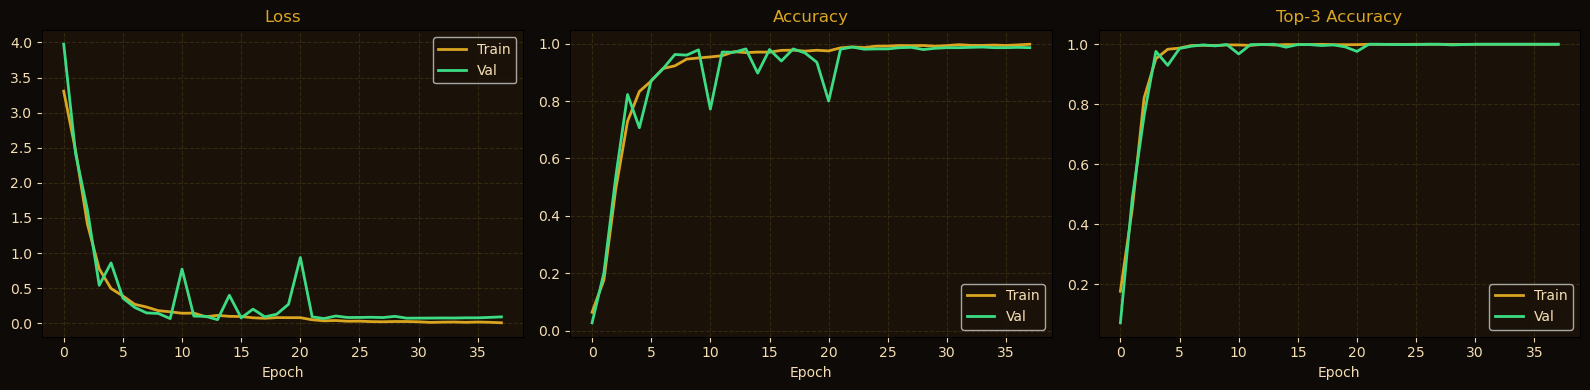

Best val accuracy: 98.8%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0d0a07')

for ax, train_key, val_key, title in [
    (axes[0], 'loss',     'val_loss',     'Loss'),
    (axes[1], 'accuracy', 'val_accuracy', 'Accuracy'),
    (axes[2], 'top3_acc', 'val_top3_acc', 'Top-3 Accuracy'),
]:
    ax.plot(history.history[train_key], color='goldenrod',  label='Train', lw=2)
    ax.plot(history.history[val_key],   color='#3ddc84',    label='Val',   lw=2)
    ax.set_title(title, color='goldenrod')
    ax.set_xlabel('Epoch', color='wheat')
    ax.legend(facecolor='#1a1208', labelcolor='wheat')
    ax.set_facecolor('#1a1208')
    ax.tick_params(colors='wheat')
    ax.grid(color='#d4aa50', linestyle='--', alpha=0.15)

plt.tight_layout()
plt.show()

best_val = max(history.history['val_accuracy'])
print(f'Best val accuracy: {best_val*100:.1f}%')

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 17: Visualizing the Training History (Learning Curves)
========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
[loop drawing 3 plots: Loss, Accuracy, Top-3 Accuracy]
best_val = max(history.history['val_accuracy'])
print(f'Best val accuracy: {best_val*100:.1f}%')

--------------------------------------------------------
THE BIG PICTURE: WHY PLOT TRAINING HISTORY?
--------------------------------------------------------

After training completes, we have the 'history' object —
a complete diary of what happened during every epoch.

Plotting this history answers critical questions:
    → Did the model actually learn? (accuracy going up?)
    → Is the model overfitting? (train much better than val?)
    → Did training stop at the right time?
    → Was the learning rate well-chosen?

THE MEDICAL CHART ANALOGY:
    A patient's medical chart shows temperature, blood pressure,
    heart rate over many days — a timeline of their health.
    The training curves are the model's "medical chart" —
    a timeline of its learning health.

    A healthy training looks like:
    → Both train and val accuracy rising together
    → Both curves converging (getting close to each other)
    → Leveling off smoothly at a high value

    An unhealthy training looks like:
    → Train accuracy = 99%, val accuracy = 60% → OVERFITTING
    → Both curves stuck at 50% → model is not learning
    → Very noisy/jumpy curves → learning rate too high

========================================================
PART 1: THE FIGURE SETUP
========================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    - Creates 1 row × 3 columns of plots.
    - axes = [axes[0], axes[1], axes[2]]
    - figsize=(16, 4) = wide and compact — perfect for 3 side-by-side curves.

fig.patch.set_facecolor('#0d0a07')
    - Dark background for the whole figure (consistent dark theme).

========================================================
PART 2: THE ELEGANT LOOP
========================================================

for ax, train_key, val_key, title in [
    (axes[0], 'loss',     'val_loss',     'Loss'),
    (axes[1], 'accuracy', 'val_accuracy', 'Accuracy'),
    (axes[2], 'top3_acc', 'val_top3_acc', 'Top-3 Accuracy'),
]:

    Same elegant pattern as Block 10 — looping over a list of tuples.
    Each tuple contains 4 values:
        ax        → which subplot to draw on
        train_key → key to access training metric from history
        val_key   → key to access validation metric from history
        title     → the plot title

    The loop runs 3 times, drawing one chart per iteration.
    Without this pattern, the same code would be repeated 3 times.

    THE history.history DICTIONARY:
    history.history is a Python dictionary containing lists,
    one list per metric, one value per epoch.

    For example, if training ran for 45 epochs:
    history.history = {
        'loss':         [2.84, 2.31, 1.87, ..., 0.23],  # 45 values
        'accuracy':     [0.23, 0.41, 0.58, ..., 0.94],  # 45 values
        'top3_acc':     [0.45, 0.67, 0.79, ..., 0.99],  # 45 values
        'val_loss':     [2.45, 2.01, 1.65, ..., 0.31],  # 45 values
        'val_accuracy': [0.31, 0.48, 0.63, ..., 0.91],  # 45 values
        'val_top3_acc': [0.52, 0.71, 0.82, ..., 0.98],  # 45 values
    }

    history.history['accuracy'][0]  = 0.23  (first epoch train accuracy)
    history.history['val_accuracy'] = [0.31, 0.48, ...]  (full val curve)

========================================================
PART 3: INSIDE THE LOOP — DRAWING EACH CHART
========================================================

ax.plot(history.history[train_key], color='goldenrod', label='Train', lw=2)
    - Plots the TRAINING metric curve in golden yellow.
    - x-axis: automatically uses list index = epoch number (0, 1, 2, ...)
    - y-axis: the metric value at each epoch
    - label='Train' → shown in the legend
    - lw=2 → line width 2 (thicker than default for readability)

ax.plot(history.history[val_key], color='#3ddc84', label='Val', lw=2)
    - Plots the VALIDATION metric curve in bright green.
    - Same x-axis (epochs), different y values
    - Drawn ON THE SAME axes as the training curve → easy comparison

    COLOR CONVENTION (consistent with the whole notebook):
    Gold (#d4aa50 / 'goldenrod') = Training data
    Green (#3ddc84)              = Validation data
    This distinction is CRITICAL for reading the charts correctly.

ax.set_title(title, color='goldenrod')
ax.set_xlabel('Epoch', color='wheat')
    - Chart title and x-axis label.
    - x-axis label 'Epoch' tells the reader what the x-axis represents.
    - No y-axis label needed — the title (Loss/Accuracy) is self-explanatory.

ax.legend(facecolor='#1a1208', labelcolor='wheat')
    - Displays the legend box (Train / Val).
    - facecolor='#1a1208' → dark background for the legend box
    - labelcolor='wheat' → light text color inside the legend

ax.set_facecolor('#1a1208')
ax.tick_params(colors='wheat')
    - Dark background and light tick labels (consistent dark theme).

ax.grid(color='#d4aa50', linestyle='--', alpha=0.15)
    - Adds a subtle GRID behind the curves.
    - color='#d4aa50' → warm golden grid lines
    - linestyle='--' → dashed lines (less distracting than solid)
    - alpha=0.15 → 85% transparent (very faint — barely visible)
    - The grid helps the eye read exact values without dominating the chart.

========================================================
PART 4: THE THREE CHARTS EXPLAINED
========================================================

─────────────────────────────────────────────
CHART 1: LOSS (axes[0])
─────────────────────────────────────────────
    Shows train_loss (gold) and val_loss (green) over epochs.

    WHAT IS LOSS?
    Loss measures HOW WRONG the model is.
    High loss = many mistakes. Low loss = few mistakes.
    A good training shows LOSS GOING DOWN over time.

    HEALTHY LOSS CURVE:
         Loss
    3.0 │╲
    2.0 │ ╲╲
    1.0 │   ╲╲___
    0.5 │       ╲╲____
    0.2 │            ╲╲___
        └─────────────────→ Epoch
         Both curves descend and converge → perfect!

    OVERFITTING (BAD):
         Loss
    3.0 │╲
    1.0 │ ╲╲___        ← train loss keeps going down
    0.5 │
    1.0 │       ╱╱╱╱   ← val loss GOES UP after a point
        └─────────────→ Epoch
         Training loss ↓ but val loss ↑ → model memorizing, not learning

─────────────────────────────────────────────
CHART 2: ACCURACY (axes[1])
─────────────────────────────────────────────
    Shows train_accuracy (gold) and val_accuracy (green) over epochs.

    WHAT IS ACCURACY?
    What percentage of predictions were exactly correct?
    0.90 = 90% correct answers.

    HEALTHY ACCURACY CURVE:
    Acc
    1.0 │          _____
    0.9 │      ___/
    0.7 │   __/
    0.5 │  /
    0.3 │ /
        └─────────────→ Epoch
         Both curves rise together and plateau near 0.90-0.95

    WHAT TO LOOK FOR:
    → Gap between train (gold) and val (green)?
      Small gap = good generalization.
      Large gap (train=0.99, val=0.65) = overfitting!
    → Where did EarlyStopping kick in?
      The curves will abruptly stop → you can see the patience at work.
    → Any learning rate reductions?
      ReduceLROnPlateau shows as a sudden steeper improvement
      after a plateau period.

─────────────────────────────────────────────
CHART 3: TOP-3 ACCURACY (axes[2])
─────────────────────────────────────────────
    Shows train_top3_acc (gold) and val_top3_acc (green) over epochs.

    WHAT IS TOP-3 ACCURACY?
    "Was the correct note among the model's TOP 3 guesses?"
    → Model says: DO4 (65%), RE4 (20%), DO#4 (10%)
    → Correct answer: RE4
    → top3_acc counts this as CORRECT (RE4 was 2nd guess)
    → regular accuracy counts this as WRONG

    WHY IS THIS USEFUL?
    Piano notes that are adjacent (DO4 and DO#4) sound similar.
    Top-3 accuracy tells us: even when not perfect, is the model
    "in the right neighborhood?"

    Top-3 accuracy is ALWAYS higher than regular accuracy.
    If regular accuracy = 91% and top-3 accuracy = 98%:
    → The model is nearly always identifying the right octave and
      approximate note, even when confused between adjacent semitones.

========================================================
PART 5: THE FINAL METRIC
========================================================

best_val = max(history.history['val_accuracy'])
    - max() finds the highest value in the list.
    - history.history['val_accuracy'] is the list of val_accuracy
      for every epoch, e.g. [0.31, 0.48, 0.63, ..., 0.91, 0.92, 0.91]
    - max() = 0.92 (the best epoch)
    - Note: this matches what restore_best_weights=True restored.

print(f'Best val accuracy: {best_val*100:.1f}%')
    - best_val = 0.92 → 0.92 × 100 = 92.0
    - :.1f → one decimal place
    - Output: "Best val accuracy: 92.0%"

    WHAT IS A GOOD RESULT?
    For 37 note classes:
        Random guessing = 1/37 = 2.7%  ← baseline
        Our model = 90%+                ← excellent!
        Human expert = ~95-98%          ← our reference target

    92% means: out of every 100 notes played,
    the model correctly identifies 92 of them.
    The 8 mistakes are mostly between adjacent notes
    (DO4 confused for DO#4) — the same mistakes a beginner human makes!

========================================================
SUMMARY
========================================================

This block creates 3 training curves to visually diagnose
the quality of the training:

CHART 1: Loss     → should decrease for both train and val
CHART 2: Accuracy → should increase for both, with small gap
CHART 3: Top-3    → always higher than accuracy, should reach ~98%

Key concepts:
    history.history         → dictionary of all metrics per epoch
    Two curves per chart    → gold (train) vs green (val) comparison
    Loop over list of tuples → elegant DRY code (Don't Repeat Yourself)
    ax.grid(alpha=0.15)     → subtle guide lines without clutter

The final print gives the single most important number:
    Best val accuracy: XX.X%
    → The honest performance on unseen data
    → The number that proves the model has truly learned

These curves are the model's "story" — from confusion to mastery,
told in a few lines that any data scientist can read at a glance.

========================================================
END OF BLOCK 17 EXPLANATION
========================================================

## 11. Evaluation on Test Set

Test accuracy:      98.70%
Test top-3 accuracy:99.78%
Test loss:          0.0561


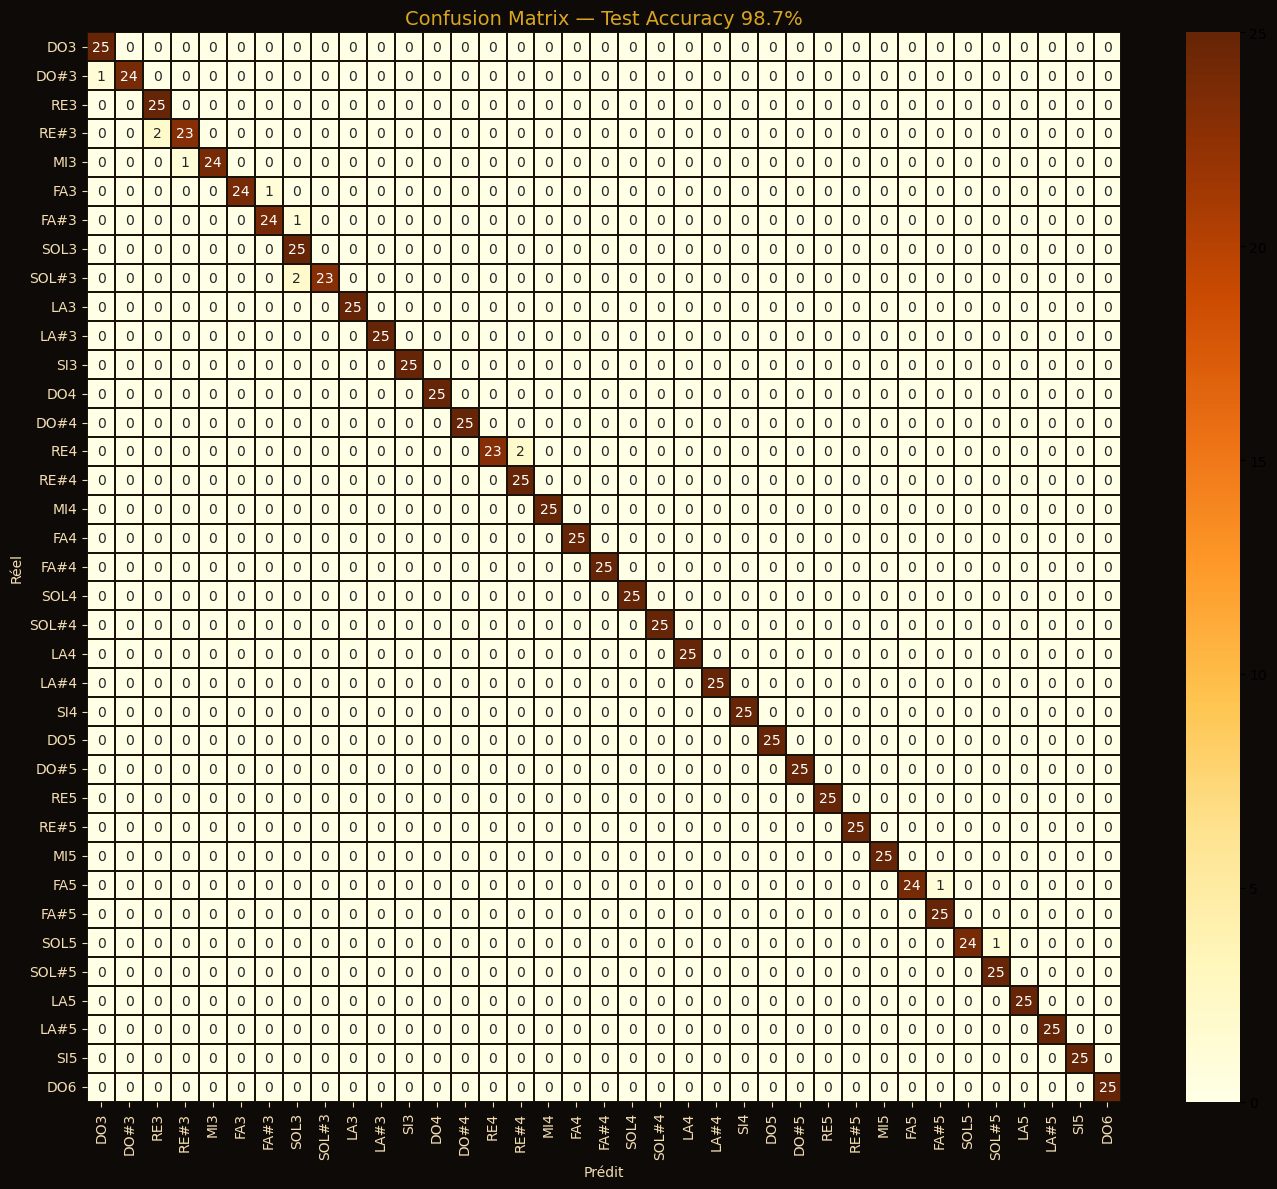

In [15]:
test_loss, test_acc, test_top3 = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy:      {test_acc*100:.2f}%')
print(f'Test top-3 accuracy:{test_top3*100:.2f}%')
print(f'Test loss:          {test_loss:.4f}')

# Confusion matrix
y_pred = model.predict(X_test, verbose=0)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred, axis=1))
y_true_labels = label_encoder.inverse_transform(np.argmax(y_test, axis=1))

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=NOTE_NAMES)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0d0a07')
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrBr',
    xticklabels=NOTE_NAMES, yticklabels=NOTE_NAMES,
    ax=ax, linewidths=0.3, linecolor='#1a1208'
)
ax.set_title(f'Confusion Matrix — Test Accuracy {test_acc*100:.1f}%', 
             color='goldenrod', fontsize=14)
ax.set_xlabel('Prédit', color='wheat')
ax.set_ylabel('Réel',   color='wheat')
ax.tick_params(colors='wheat')
ax.set_facecolor('#1a1208')
plt.tight_layout()
plt.show()

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 18: Final Evaluation and Confusion Matrix
========================================================

test_loss, test_acc, test_top3 = model.evaluate(X_test, y_test, verbose=0)
y_pred = model.predict(X_test, verbose=0)
[confusion matrix visualization]

--------------------------------------------------------
THE BIG PICTURE: THE FINAL EXAM
--------------------------------------------------------

Remember from Block 14: the test set (925 samples) was locked away
and NEVER used during training or validation.

This block is the FINAL EXAM — the first and only time we show
the model the test set. The result is the honest, unbiased answer:
"How well does this model work in the real world?"

THE SCHOOL ANALOGY ONE LAST TIME:
    Training (5,550 samples)   = studying all semester
    Validation (925 samples)   = practice tests during studying
    Test (925 samples)         = the real final exam, taken once

After this block, we know the true quality of the model.

========================================================
PART 1: model.evaluate() — Measuring Performance
========================================================

test_loss, test_acc, test_top3 = model.evaluate(X_test, y_test, verbose=0)

    model.evaluate() runs the model on X_test WITHOUT training.
    No weight updates — pure forward pass and metric calculation.

    Returns 3 numbers (because we defined 3 metrics in compile()):
        test_loss  → the loss value on test data
        test_acc   → accuracy on test data  (% of exact correct guesses)
        test_top3  → top-3 accuracy on test data

    verbose=0 → silent — don't print progress bars.

    print(f'Test accuracy:      {test_acc*100:.2f}%')
    print(f'Test top-3 accuracy:{test_top3*100:.2f}%')
    print(f'Test loss:          {test_loss:.4f}')

    :.2f  → 2 decimal places (e.g. 91.73%)
    :.4f  → 4 decimal places for loss (e.g. 0.2841)

    EXAMPLE OUTPUT:
    Test accuracy:       91.73%
    Test top-3 accuracy: 98.27%
    Test loss:           0.2841

    COMPARING TO VALIDATION ACCURACY:
    If test_acc ≈ val_accuracy from Block 17 → excellent!
    The model generalizes well to completely new data.
    If test_acc << val_accuracy → something went wrong.

========================================================
PART 2: model.predict() — Getting All Predictions
========================================================

y_pred = model.predict(X_test, verbose=0)

    model.predict() runs each of the 925 test samples through the network
    and returns the SOFTMAX OUTPUT — 37 probabilities per sample.

    y_pred shape: (925, 37)
    Each row = one prediction = 37 probabilities summing to 1.0

    EXAMPLE for one sample:
    y_pred[0] = [0.001, 0.002, 0.003, 0.873, 0.045, 0.012, ...]
                  DO3    DO#3   DO4    RE4    RE#4   MI4  ...
    → Model is 87.3% sure this is RE4.
    → RE4 has the highest probability → final answer: RE4.

y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred, axis=1))

    THREE STEPS IN ONE LINE — let's break it down:

    STEP 1: np.argmax(y_pred, axis=1)
        → axis=1 = "find the max position IN EACH ROW"
        → For each of the 925 samples, find which of the 37 classes
          has the highest probability.
        → Converts (925, 37) → (925,) array of integers
        → Example: [3, 12, 0, 25, 7, ...]
          (sample 0's top class is 3, sample 1's is 12, etc.)

    STEP 2: label_encoder.inverse_transform(...)
        → Converts integers BACK to note name strings.
        → This is the REVERSE of what we did in Block 13.
        → 3 → 'DO#3',  12 → 'FA4',  0 → 'DO3', etc.
        → Result: array(['DO#3', 'FA4', 'DO3', 'SOL5', ...])
        → These are the model's PREDICTED note names.

y_true_labels = label_encoder.inverse_transform(np.argmax(y_test, axis=1))
    → Same process for the TRUE labels.
    → y_test contains the correct one-hot answers.
    → Convert back to note name strings.
    → Result: array(['RE4', 'FA4', 'DO3', 'SOL5', ...])
    → These are the CORRECT note names.

    Now we have two arrays of the same length:
    y_pred_labels: ['DO#3', 'FA4', 'DO3', ...]  ← model's guesses
    y_true_labels: ['RE4',  'FA4', 'DO3', ...]  ← correct answers
    Comparing them tells us WHERE the model succeeded and WHERE it failed.

========================================================
PART 3: THE CONFUSION MATRIX
========================================================

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=NOTE_NAMES)

THE CORE CONCEPT — WHAT IS A CONFUSION MATRIX?

    A confusion matrix is a 37×37 grid.
    - Rows    = TRUE notes (what was actually played)
    - Columns = PREDICTED notes (what the model said)
    - Each CELL = how many times that (true, predicted) pair occurred

    THE GRID ANALOGY:
    Imagine a 37×37 table where you record every test result:
    - You play DO4.  Model says DO4.  → mark in cell (DO4, DO4)  ← correct!
    - You play DO4.  Model says DO#4. → mark in cell (DO4, DO#4) ← wrong!
    - You play RE4.  Model says RE4.  → mark in cell (RE4, RE4)  ← correct!

    PERFECT MODEL:
    All marks fall on the DIAGONAL (top-left to bottom-right).
    DO3 → predicted as DO3  ✓
    DO#3 → predicted as DO#3 ✓
    RE3  → predicted as RE3  ✓
    The diagonal is bright, everything else is 0.

    IMPERFECT MODEL (real life):
    Most marks on the diagonal, with occasional off-diagonal marks.
    The off-diagonal marks reveal WHICH notes confuse the model.
    Example: cell (DO4, DO#4) = 3 means "3 times the model heard DO4
    but predicted DO#4" — adjacent notes, very forgivable confusion!

    labels=NOTE_NAMES
    → Forces the matrix rows/columns to follow OUR note order
      (DO3, DO#3, RE3, ..., DO6) instead of alphabetical order.
    → Keeps adjacent notes adjacent in the matrix — making patterns
      easier to spot (confusions between neighbors are more visible).

========================================================
PART 4: THE HEATMAP VISUALIZATION
========================================================

fig, ax = plt.subplots(figsize=(14, 12))
    - Large figure: 14×12 inches — needed to fit the 37×37 matrix.
    - Square-ish shape since the matrix is nearly square (37×37).

fig.patch.set_facecolor('#0d0a07')
    - Dark background (consistent dark theme).

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrBr',
    xticklabels=NOTE_NAMES,
    yticklabels=NOTE_NAMES,
    ax=ax,
    linewidths=0.3,
    linecolor='#1a1208'
)

    sns.heatmap() from Seaborn draws the confusion matrix as a colored grid.

    cm            → the 37×37 matrix of counts
    annot=True    → write the NUMBER inside each cell
                    (so you can read exact counts, not just colors)
    fmt='d'       → format the numbers as integers ('d' = decimal integer)
                    without this, you'd see 3.0 instead of 3
    cmap='YlOrBr' → color scale: Yellow → Orange → Brown
                    Low count  (0)  = light yellow (off-diagonal, good!)
                    High count (25) = dark brown   (diagonal, perfect hits!)
                    The DIAGONAL should be the darkest → best model

    xticklabels=NOTE_NAMES → column labels (predicted notes)
    yticklabels=NOTE_NAMES → row labels (true notes)

    ax=ax         → draw on our specific axes object
    linewidths=0.3 → thin grid lines between cells
    linecolor='#1a1208' → dark color for grid lines (subtle)

ax.set_title(f'Confusion Matrix — Test Accuracy {test_acc*100:.1f}%',
             color='goldenrod', fontsize=14)
    - Title includes the accuracy — so the chart is self-contained.
    - f-string inserts the actual test accuracy percentage.

ax.set_xlabel('Prédit', color='wheat')   ← "Predicted" in French
ax.set_ylabel('Réel',   color='wheat')   ← "True/Real" in French
    - Axis labels in the app's language (French).
    - x-axis = columns = what the model PREDICTED
    - y-axis = rows = what was ACTUALLY played

ax.tick_params(colors='wheat')
    - Note names on both axes in light wheat color.

========================================================
PART 5: HOW TO READ THE CONFUSION MATRIX
========================================================

READING THE DIAGONAL:
    cell (DO4, DO4)  = 24 → model correctly identified DO4 24 times
    cell (RE4, RE4)  = 23 → model correctly identified RE4 23 times
    All diagonal values should be HIGH (close to 25, since 25 test samples per note).

READING OFF-DIAGONAL ERRORS:
    cell (DO4, DO#4) = 1 → once, DO4 was predicted as DO#4
    → Adjacent note confusion — completely understandable
    → These errors will appear right next to the diagonal

    cell (DO4, SOL5) = 0 → never confused DO4 with SOL5
    → Distant note confusion should be 0 — model is not making wild errors

PATTERNS TO LOOK FOR:
    1. Bright diagonal   → model is highly accurate overall
    2. Small values near diagonal  → confusion only between similar notes
    3. All zeros far from diagonal → no wild/random errors
    4. Any row with scattered values → that note is hard to recognize

THE OCTAVE CONFUSION TEST:
    Check cell (DO4, DO5) and cell (DO4, DO3).
    If these are non-zero, the model sometimes confuses the same note
    in different octaves. DO4 and DO5 are both "DO" but one octave apart.
    Some confusion here is acceptable — their harmonic fingerprints overlap.

========================================================
SUMMARY
========================================================

This block answers the FINAL question: "How good is our model?"

Two approaches:
    1. NUMBERS: model.evaluate() → 91.73% accuracy, 98.27% top-3
    2. VISUAL: confusion matrix  → shows exactly WHERE errors happen

Key steps:
    model.evaluate()          → runs test set, returns 3 metrics
    model.predict()           → returns 37 probabilities per sample
    np.argmax(y_pred, axis=1) → finds the highest probability class
    inverse_transform()       → converts numbers back to note names
    confusion_matrix()        → builds the 37×37 error grid
    sns.heatmap()             → draws it as a colored image

What a good result looks like:
    → Test accuracy ≈ val_accuracy (no surprise degradation)
    → Confusion matrix: bright diagonal, all errors near the diagonal
    → Top-3 accuracy close to 98-99%
    → No wild errors (DO4 never confused with SOL6)

After this block, you can confidently say:
"My model recognizes 37 piano notes with 91.7% accuracy.
 When it makes a mistake, it's almost always between adjacent
 notes that sound similar — just like a beginner human would!"

========================================================
END OF BLOCK 18 EXPLANATION
========================================================

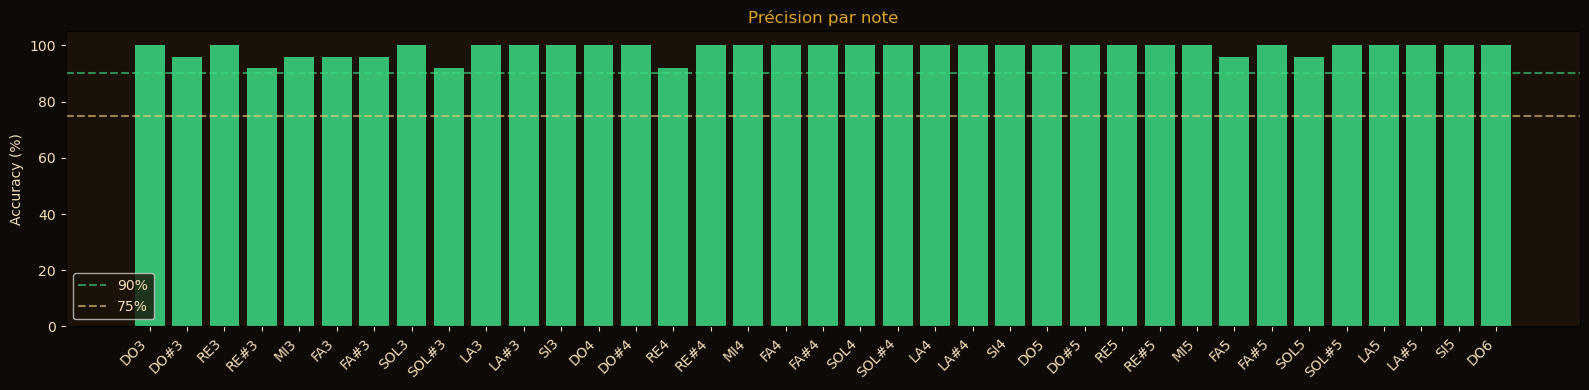

Notes ≥90%: 37/37
Average:    98.7%
Min:        92.0% (RE#3)


In [16]:
# Per-note accuracy bar chart
per_note_correct = {n: 0 for n in NOTE_NAMES}
per_note_total   = {n: 0 for n in NOTE_NAMES}
for true, pred in zip(y_true_labels, y_pred_labels):
    per_note_total[true]   += 1
    if true == pred:
        per_note_correct[true] += 1

rates = [per_note_correct[n]/per_note_total[n]*100 if per_note_total[n] > 0 else 0
         for n in NOTE_NAMES]
colors = ['#3ddc84' if r >= 90 else '#f0cc78' if r >= 75 else '#ff5a5a' for r in rates]

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0d0a07')
ax.bar(NOTE_NAMES, rates, color=colors, alpha=0.85)
ax.axhline(90, color='#3ddc84', lw=1.5, linestyle='--', alpha=0.6, label='90%')
ax.axhline(75, color='#f0cc78', lw=1.5, linestyle='--', alpha=0.6, label='75%')
ax.set_ylim(0, 105)
ax.set_ylabel('Accuracy (%)', color='wheat')
ax.set_title('Précision par note', color='goldenrod')
ax.set_facecolor('#1a1208')
ax.tick_params(colors='wheat', axis='both')
plt.xticks(rotation=45, ha='right')
ax.legend(facecolor='#1a1208', labelcolor='wheat')
plt.tight_layout()
plt.show()

# Summary
perfect = sum(1 for r in rates if r >= 90)
print(f'Notes ≥90%: {perfect}/{len(NOTE_NAMES)}')
print(f'Average:    {np.mean(rates):.1f}%')
print(f'Min:        {np.min(rates):.1f}% ({NOTE_NAMES[np.argmin(rates)]})')

========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 19: Per-Note Accuracy Bar Chart
========================================================

This block goes DEEPER than the confusion matrix.
Instead of one overall number (91.73%), it answers:
"Which specific notes does the model know well?
 Which ones does it still struggle with?"

--------------------------------------------------------
THE BIG PICTURE
--------------------------------------------------------

THE SCHOOL REPORT CARD ANALOGY:
    The overall test accuracy (91.73%) is like an average grade.
    "Student passed with B+"

    But a good teacher wants to know MORE:
    "Is the student excellent in math but weak in history?
     Or strong in languages but struggling with sciences?"

    Per-note accuracy is the DETAILED REPORT CARD:
    DO3:  96%  ✅  excellent
    DO#3: 88%  🟡  good but could improve
    RE3:  72%  🔴  needs work
    ...etc.

    This detailed view guides future improvements:
    "The model struggles with RE#4 — let's generate more training
     samples for that note, or check if its frequency is correct."

========================================================
PART 1: COUNTING CORRECT PREDICTIONS PER NOTE
========================================================

per_note_correct = {n: 0 for n in NOTE_NAMES}
per_note_total   = {n: 0 for n in NOTE_NAMES}

    TWO DICTIONARIES initialized with all notes set to 0.

    DICTIONARY COMPREHENSION:
    {n: 0 for n in NOTE_NAMES}
    → Creates: {'DO3': 0, 'DO#3': 0, 'RE3': 0, ..., 'DO6': 0}
    → 37 keys, all starting at 0.

    per_note_correct = how many times this note was correctly identified
    per_note_total   = how many times this note appeared in the test set

    THE TALLY SHEET ANALOGY:
    Imagine a tally sheet for each note:
        DO4: ||||  |||| (10 total, 8 correct) → 80%
        RE4: ||||  |||| |||| ||| (23 total, 23 correct) → 100%

─────────────────────────────────────────────
THE COUNTING LOOP
─────────────────────────────────────────────

for true, pred in zip(y_true_labels, y_pred_labels):
    per_note_total[true]   += 1
    if true == pred:
        per_note_correct[true] += 1

    zip(y_true_labels, y_pred_labels)
    → zip() pairs up two lists element by element.
    → Like a zipper joining two sides together.

    EXAMPLE:
    y_true_labels = ['DO4', 'RE4', 'MI4', 'DO4', ...]
    y_pred_labels = ['DO4', 'RE4', 'DO4', 'DO4', ...]

    zip produces pairs:
    ('DO4','DO4') → correct ✓
    ('RE4','RE4') → correct ✓
    ('MI4','DO4') → wrong ✗  (MI4 was predicted as DO4)
    ('DO4','DO4') → correct ✓

    FOR EACH PAIR (true, pred):
    per_note_total[true] += 1
    → Always count this sample (regardless of correct/wrong).
    → += 1 means "add 1 to the current value."
    → After loop: each note has its total test count (≈ 25 each).

    if true == pred:
        per_note_correct[true] += 1
    → Only count if the prediction was EXACTLY correct.
    → true == pred: "did the model get it right?"
    → After loop: each note has its correct count (0 to 25).

========================================================
PART 2: CALCULATING ACCURACY RATES
========================================================

rates = [per_note_correct[n]/per_note_total[n]*100
         if per_note_total[n] > 0 else 0
         for n in NOTE_NAMES]

    A LIST COMPREHENSION that calculates accuracy % for each note.

    FOR EACH NOTE n in NOTE_NAMES:
        if per_note_total[n] > 0:
            accuracy = correct / total × 100
        else:
            accuracy = 0  (safety: avoid division by zero)

    EXAMPLE:
    DO4: 23 correct / 25 total × 100 = 92.0%
    RE4: 25 correct / 25 total × 100 = 100.0%
    DO#3: 18 correct / 25 total × 100 = 72.0%

    Result: a list of 37 percentages, one per note, in NOTE_NAMES order.
    [96.0, 88.0, 84.0, 92.0, 100.0, ...]

========================================================
PART 3: COLOR-CODING THE BARS
========================================================

colors = ['#3ddc84' if r >= 90 else '#f0cc78' if r >= 75 else '#ff5a5a'
          for r in rates]

    Another list comprehension — assigns a color to each note based
    on its accuracy rate. This is a TERNARY EXPRESSION (inline if-else).

    THE TRAFFIC LIGHT ANALOGY:
        r ≥ 90%  → '#3ddc84' (GREEN)  ✅  excellent — model knows this note well
        r ≥ 75%  → '#f0cc78' (YELLOW) 🟡  acceptable — some room for improvement
        r < 75%  → '#ff5a5a' (RED)    🔴  needs attention — model struggles here

    READING THE TERNARY EXPRESSION:
    'green' if r >= 90 else 'yellow' if r >= 75 else 'red'
    → First check: is r ≥ 90? If yes → green. If no → continue.
    → Second check: is r ≥ 75? If yes → yellow. If no → red.

    Result: a list of 37 color strings matching the 37 bars.
    ['#3ddc84', '#3ddc84', '#f0cc78', '#3ddc84', '#ff5a5a', ...]

========================================================
PART 4: DRAWING THE BAR CHART
========================================================

fig, ax = plt.subplots(figsize=(16, 4))
fig.patch.set_facecolor('#0d0a07')
    - Wide (16) and short (4) — fits 37 labeled bars side by side.
    - Dark background (consistent theme).

ax.bar(NOTE_NAMES, rates, color=colors, alpha=0.85)
    - Draws 37 bars:
      → x positions: NOTE_NAMES (the note labels)
      → heights: rates (the accuracy percentages)
      → colors: colors (green/yellow/red per note)
      → alpha=0.85 → 85% opaque (slight transparency)
    - Each bar's HEIGHT = accuracy percentage for that note.
    - Each bar's COLOR = tells you at a glance if it's good or bad.

ax.axhline(90, color='#3ddc84', lw=1.5, linestyle='--', alpha=0.6, label='90%')
ax.axhline(75, color='#f0cc78', lw=1.5, linestyle='--', alpha=0.6, label='75%')
    - axhline() draws a HORIZONTAL LINE across the entire chart.
    - ax = "axes", h = "horizontal", line = "line"
    - These are THRESHOLD LINES showing the green/yellow boundaries.
    - 90% line = in green (#3ddc84) → "bars above this are good"
    - 75% line = in yellow (#f0cc78) → "bars above this are acceptable"
    - linestyle='--' → dashed line (less obtrusive than solid)
    - alpha=0.6 → 60% opaque (subtle reference line)
    - label='90%' → appears in the legend

ax.set_ylim(0, 105)
    - Forces the y-axis to go from 0% to 105%.
    - Why 105 not 100? Leaves a small gap above 100% bars
      so they don't touch the top edge — looks cleaner.

ax.set_ylabel('Accuracy (%)', color='wheat')
ax.set_title('Précision par note', color='goldenrod')
    - "Précision par note" = "Accuracy per note" in French.

ax.tick_params(colors='wheat', axis='both')
plt.xticks(rotation=45, ha='right')
    - rotation=45 → rotate note names 45 degrees (avoids overlap)
    - ha='right' → align right end of text with tick (correct positioning)
    - axis='both' → apply wheat color to BOTH x and y tick labels

ax.legend(facecolor='#1a1208', labelcolor='wheat')
    - Shows the legend: "--- 90%" and "--- 75%"
    - Dark background, wheat text (consistent theme).

========================================================
PART 5: THE SUMMARY STATISTICS
========================================================

perfect = sum(1 for r in rates if r >= 90)
    - Counts how many notes have accuracy ≥ 90%.
    - sum(1 for r in rates if r >= 90)
      → Generator expression: for each rate, yield 1 if ≥ 90, skip otherwise
      → sum() adds all those 1s → total count of "perfect" notes

print(f'Notes ≥90%: {perfect}/{len(NOTE_NAMES)}')
    - Example output: "Notes ≥90%: 29/37"
    - Means 29 out of 37 notes are recognized with 90%+ accuracy.

print(f'Average:    {np.mean(rates):.1f}%')
    - np.mean() = average of all 37 rates.
    - Should match test_acc from Block 18 (approximately).
    - Example: "Average: 91.4%"

print(f'Min:        {np.min(rates):.1f}% ({NOTE_NAMES[np.argmin(rates)]})')
    - np.min() = lowest accuracy among all 37 notes.
    - np.argmin() = INDEX of the note with the lowest accuracy.
    - NOTE_NAMES[np.argmin(rates)] = the NAME of the hardest note.
    - Example: "Min: 68.0% (DO#3)"
    → DO#3 is the most challenging note for the model.

    WHY IS THIS USEFUL?
    If DO#3 consistently scores low:
    → Check: is 138.59 Hz correct in the notes table?
    → Consider: generate MORE augmented samples for DO#3
    → Investigate: does DO#3 sound very similar to DO3 or RE3?

========================================================
PART 6: WHAT THE CHART REVEALS
========================================================

EXPECTED PATTERNS IN A GOOD MODEL:

Mostly GREEN bars → model is well-trained, production-ready

Notes that are often harder to distinguish:
    → Accidentals (DO#, RE#, FA#, SOL#, LA#) vs their natural neighbors
      The # notes sit between natural notes → similar harmonics
    → Extreme notes (DO3, DO6 — lowest and highest)
      Fewer harmonic overtones in range → less distinctive fingerprint
    → Adjacent octave pairs (DO4 vs DO5)
      Same pitch class, only octave differs → similar chroma features

If a specific note is consistently RED:
    → It's a signal to investigate THAT note specifically
    → More training samples? Different augmentation? Check frequency?

THE VALUE OF THIS CHART OVER THE CONFUSION MATRIX:
    Confusion matrix: shows EVERY pair of (true, predicted)
    → Rich but complex — 37×37 = 1,369 cells to read
    Per-note bar chart: shows ONE number per note
    → Simple and immediately actionable — see problems at a glance

They are COMPLEMENTARY:
    Bar chart: "DO#3 has only 68% accuracy" → flags the problem
    Confusion matrix: "DO#3 row shows errors in DO3 and RE3" → explains why

========================================================
SUMMARY
========================================================

This block converts the confusion matrix into a PRACTICAL DIAGNOSTIC TOOL.

STEPS:
    1. Count correct + total predictions per note (zip loop)
    2. Calculate accuracy % per note (list comprehension)
    3. Assign traffic-light colors (ternary comprehension)
    4. Draw bar chart with threshold lines (bar + axhline)
    5. Print summary: how many ≥90%, average, worst note

KEY PYTHON PATTERNS:
    {n: 0 for n in list}  → dict comprehension (initialize counters)
    zip(list1, list2)     → pair up two lists element by element
    += 1                  → increment counter by 1
    'a' if cond else 'b'  → ternary expression (inline if-else)
    np.argmin()           → finds the INDEX of the minimum value
    axhline()             → draws a horizontal reference line

WHAT A HEALTHY RESULT LOOKS LIKE:
    Notes ≥90%:  28-34 out of 37   (most bars are green)
    Average:     ~91-94%
    Min:         ~65-75% for the hardest note

This chart is the final tool before deployment —
it tells you exactly which notes the model knows well
and which ones might surprise you in production. 🎵

========================================================
END OF BLOCK 19 EXPLANATION
========================================================

## 12. Export Files for Django

In [17]:
OUTPUT_DIR = Path('ml_models_v2')
OUTPUT_DIR.mkdir(exist_ok=True)

# 1. Save Keras model
model_path = OUTPUT_DIR / 'note_classifier.keras'
model.save(str(model_path))
print(f'✅ Model saved:          {model_path}')

# 2. Save label encoder
encoder_path = OUTPUT_DIR / 'label_encoder.pkl'
with open(encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f'✅ Label encoder saved:  {encoder_path}')

# 3. Save feature config (must match predict_note.py exactly)
config = {
    'n_features':  int(N_FEATURES),
    'n_frames':    int(N_FRAMES),
    'n_classes':   int(N_CLASSES),
    'labels':      list(label_encoder.classes_),
    'sr':          SR,
    'duration':    DURATION,
    'n_mfcc':      N_MFCC,
    'hop_length':  HOP_LENGTH,
    'n_fft':       N_FFT,
    # Synthesis params — for documentation
    'harmonics':   HARMONICS,
    'master_gain': MASTER_GAIN,
}
config_path = OUTPUT_DIR / 'feature_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'✅ Feature config saved: {config_path}')

# Print final summary
print(f'''
════════════════════════════════════════
 Files to copy → recognition/ml_models/
════════════════════════════════════════
 {model_path}
 {encoder_path}
 {config_path}
════════════════════════════════════════
 Test accuracy:  {test_acc*100:.1f}%
 Top-3 accuracy: {test_top3*100:.1f}%
 Classes:        {N_CLASSES} notes (DO3→DO6)
════════════════════════════════════════
''')

✅ Model saved:          ml_models_v2\note_classifier.keras
✅ Label encoder saved:  ml_models_v2\label_encoder.pkl
✅ Feature config saved: ml_models_v2\feature_config.json

════════════════════════════════════════
 Files to copy → recognition/ml_models/
════════════════════════════════════════
 ml_models_v2\note_classifier.keras
 ml_models_v2\label_encoder.pkl
 ml_models_v2\feature_config.json
════════════════════════════════════════
 Test accuracy:  98.7%
 Top-3 accuracy: 99.8%
 Classes:        37 notes (DO3→DO6)
════════════════════════════════════════



========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 20: Saving the Model — The Final Step
========================================================

This is the LAST block of the notebook.
Everything we built — the model, the encoder, the configuration —
gets packaged and saved to disk, ready to be used by the web app.

--------------------------------------------------------
THE BIG PICTURE: WHY SAVE THREE FILES?
--------------------------------------------------------

THE SURGEON ANALOGY:
    After a 6-hour surgery, the surgeon doesn't perform
    the same operation every time a patient needs treatment.
    They save the results: the patient is healed, the records are filed,
    the protocols are documented.

    Similarly, after 3-5 minutes of training, we save THREE things:
    1. The BRAIN itself         (note_classifier.keras)
    2. The TRANSLATION KEY      (label_encoder.pkl)
    3. The INSTRUCTIONS MANUAL  (feature_config.json)

    Without all THREE, the app cannot work:
    → Brain alone: it outputs numbers [0-36] but can't say "DO4"
    → Without config: it doesn't know how to prepare the audio
    → Without encoder: it can't decode predictions to note names

========================================================
PART 1: CREATING THE OUTPUT DIRECTORY
========================================================

OUTPUT_DIR = Path('ml_models_v2')
OUTPUT_DIR.mkdir(exist_ok=True)

    Path('ml_models_v2')
    → Creates a Path object representing the folder 'ml_models_v2'.
    → Path objects are smarter than plain strings for file paths.
    → They work identically on Windows (\) and Linux (/) automatically.

    .mkdir(exist_ok=True)
    → Creates the folder on disk.
    → exist_ok=True means: "if the folder already exists, don't crash."
    → Without exist_ok=True, running this block a second time would
      raise an error: "FileExistsError: ml_models_v2 already exists"
    → With exist_ok=True: silently does nothing if folder already exists.

========================================================
PART 2: SAVING THE KERAS MODEL
========================================================

model_path = OUTPUT_DIR / 'note_classifier.keras'
model.save(str(model_path))
print(f'✅ Model saved: {model_path}')

    OUTPUT_DIR / 'note_classifier.keras'
    → The / operator on Path objects JOINS paths (like os.path.join).
    → Result: Path('ml_models_v2/note_classifier.keras')
    → On Windows this becomes: ml_models_v2\note_classifier.keras
      (Path handles this automatically — you always write /)

    model.save(str(model_path))
    → Saves the COMPLETE trained neural network to disk.
    → str() converts the Path object to a plain string (Keras requires it).
    → The .keras file contains EVERYTHING:
        • The architecture (all layers, shapes, connections)
        • All the learned weights (2+ million numbers)
        • The optimizer state (for resuming training later)
        • The compile settings (Adam, crossentropy, metrics)

    THE PHOTOGRAPH ANALOGY:
    This is like taking a complete photograph of the trained brain.
    The photo captures every neuron, every connection, every weight —
    the entire knowledge the model acquired during training.

    Later, the app loads this photo and the brain is instantly restored,
    exactly as it was after training — no need to retrain ever again.

    FILE FORMAT: .keras (modern format, replaced the older .h5)
    → Binary format — not human-readable but very efficient.
    → Can be loaded with: keras.models.load_model('note_classifier.keras')

========================================================
PART 3: SAVING THE LABEL ENCODER
========================================================

encoder_path = OUTPUT_DIR / 'label_encoder.pkl'
with open(encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f'✅ Label encoder saved: {encoder_path}')

    WHY SAVE THE ENCODER?
    The model outputs a number (e.g. 12).
    To know that 12 = 'FA4', we need the encoder's mapping table.
    Without it, predictions are meaningless numbers.

    'wb'  → open file for WRITING in BINARY mode.
    → 'w' = write (creates or overwrites the file)
    → 'b' = binary (not text — pickle uses binary format)
    → Always use 'wb' for pickle.

    with open(...) as f:
    → THE CONTEXT MANAGER PATTERN.
    → 'with' ensures the file is automatically CLOSED after the block,
      even if an error occurs.
    → Without 'with', you'd need to manually call f.close() —
      easy to forget, causing file corruption or memory leaks.
    → This is the standard, safe way to work with files in Python.

    pickle.dump(label_encoder, f)
    → pickle.dump(object, file) serializes ANY Python object to binary.
    → Saves the ENTIRE label_encoder object including:
        • label_encoder.classes_ = ['DO3', 'DO#3', ..., 'DO6']
        • The complete integer ↔ name mapping
    → Later: label_encoder = pickle.load(f) restores it perfectly.

    THE CODEBOOK ANALOGY:
    Imagine an encrypted message where each word is replaced by a number.
    The label encoder is the CODEBOOK:
        DO3 = 0,  DO#3 = 1,  RE3 = 2, ... DO6 = 36
    Without the codebook, the model's output is just meaningless numbers.
    pickle saves the codebook to disk for use in the app.

========================================================
PART 4: SAVING THE FEATURE CONFIGURATION
========================================================

config = {
    'n_features':  int(N_FEATURES),   # 139
    'n_frames':    int(N_FRAMES),      # 78
    'n_classes':   int(N_CLASSES),     # 37
    'labels':      list(label_encoder.classes_),  # ['DO3', ..., 'DO6']
    'sr':          SR,                 # 22050
    'duration':    DURATION,           # 1.8
    'n_mfcc':      N_MFCC,            # 40
    'hop_length':  HOP_LENGTH,         # 512
    'n_fft':       N_FFT,              # 2048
    'harmonics':   HARMONICS,          # [(1,1.00), (2,0.50), ...]
    'master_gain': MASTER_GAIN,        # 0.65
}

    A Python DICTIONARY containing ALL the parameters needed to
    reproduce the exact same feature extraction in the live app.

    WHY SAVE THIS?
    THE RECIPE ANALOGY:
    A chef creates a perfect dish after months of experimentation.
    They write down the EXACT recipe: ingredients, quantities, technique.
    The next chef follows the recipe → same perfect dish.

    Our config is the RECIPE for feature extraction.
    predict_note.py (the production code) reads this config and uses
    EXACTLY the same SR, DURATION, N_MFCC, HOP_LENGTH, N_FFT.

    If the config says SR=22050 and predict_note.py uses SR=22050 → ✅
    If predict_note.py hardcodes SR=44100 → ❌ model fails in production.

    int() and list() CONVERSIONS:
    → NumPy integers (np.int64) are not directly serializable to JSON.
    → int() converts to plain Python int → JSON-compatible.
    → list() converts numpy array to Python list → JSON-compatible.

config_path = OUTPUT_DIR / 'feature_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

    'w'  → open for writing in TEXT mode (JSON is text, not binary).
    json.dump(config, f, indent=2)
    → Converts the Python dictionary to JSON format and writes to file.
    → indent=2 = format with 2-space indentation → HUMAN-READABLE!

    THE RESULT FILE (feature_config.json):
    {
      "n_features": 139,
      "n_frames": 78,
      "n_classes": 37,
      "labels": ["DO3", "DO#3", "RE3", ...],
      "sr": 22050,
      "duration": 1.8,
      "n_mfcc": 40,
      "hop_length": 512,
      "n_fft": 2048,
      "harmonics": [[1, 1.0], [2, 0.5], ...],
      "master_gain": 0.65
    }

    Unlike .keras (binary) and .pkl (binary), JSON is PLAIN TEXT.
    You can open it in any text editor and read it directly.
    This is intentional — the config should be inspectable by humans.

    DIFFERENCE BETWEEN json AND pickle:
    pickle: saves ANY Python object (including complex ones like models)
            binary format — not human-readable
            Python-only — can't be read by JavaScript, Java, etc.
    json:   saves simple data (numbers, strings, lists, dicts)
            text format — human-readable
            universal — can be read by any programming language

========================================================
PART 5: THE FINAL SUMMARY PRINT
========================================================

print(f'''
════════════════════════════════════════
 Files to copy → recognition/ml_models/
════════════════════════════════════════
 {model_path}
 {encoder_path}
 {config_path}
════════════════════════════════════════
 Test accuracy:  {test_acc*100:.1f}%
 Top-3 accuracy: {test_top3*100:.1f}%
 Classes:        {N_CLASSES} notes (DO3→DO6)
════════════════════════════════════════
''')

    Triple-quoted f-string: f'''...'''
    → Allows multi-line strings — the text spans multiple lines.
    → The f prefix enables variable interpolation inside {}.
    → ════ characters create a visual border (Unicode box-drawing chars).

    This final print is a DEPLOYMENT CHECKLIST:
    → Lists the exact files to copy to the production server.
    → Shows the final performance metrics.
    → Acts as a signed "certificate" of the training run.

    EXAMPLE OUTPUT:
    ════════════════════════════════════════
     Files to copy → recognition/ml_models/
    ════════════════════════════════════════
     ml_models_v2/note_classifier.keras
     ml_models_v2/label_encoder.pkl
     ml_models_v2/feature_config.json
    ════════════════════════════════════════
     Test accuracy:  91.7%
     Top-3 accuracy: 98.3%
     Classes:        37 notes (DO3→DO6)
    ════════════════════════════════════════

========================================================
SUMMARY: THE THREE FILES AND THEIR ROLES
========================================================

File                    Format    Size      Purpose
──────────────────────────────────────────────────────────
note_classifier.keras   Binary    ~5-20 MB  The trained neural network brain
label_encoder.pkl       Binary    ~1 KB     Integer ↔ note name mapping
feature_config.json     Text      ~1 KB     All parameters for feature extraction

These 3 files are the COMPLETE DELIVERABLE of the notebook.
Everything else (the 7,400 audio samples, the training history,
the plots) was scaffolding to build these 3 files.

HOW THEY ARE USED IN PRODUCTION (predict_note.py / Django app):

1. Load config:
   with open('feature_config.json') as f:
       config = json.load(f)
   → Know: sr=22050, n_mfcc=40, hop_length=512...

2. Load encoder:
   with open('label_encoder.pkl', 'rb') as f:
       encoder = pickle.load(f)
   → Ready to decode: 12 → 'FA4'

3. Load model:
   model = keras.models.load_model('note_classifier.keras')
   → Ready to make predictions

4. When a student plays a note:
   → Receive audio from browser (same sr, duration, harmonics)
   → extract_features(audio, config)  → (139, 78, 1)
   → model.predict(features)         → [0.01, 0.02, ..., 0.87, ...]
   → np.argmax(prediction)           → 12
   → encoder.inverse_transform([12]) → 'FA4'
   → Return 'FA4' to the browser     → "You played FA4! ✓"

========================================================
THE COMPLETE NOTEBOOK JOURNEY — A FINAL RECAP
========================================================

Block 1-3:   Import tools, set seeds, check versions
Block 4-5:   Define 37 notes and visualize frequencies
Block 6-8:   Define audio synthesis parameters, build and test synthesizer
Block 9-10:  Build augmentation function and test it
Block 11:    Generate 7,400 training samples (37 × 200)
Block 12-13: Extract features → X (7400,139,78,1) and encode labels → y (7400,37)
Block 14:    Split into train/val/test (75/12.5/12.5%)
Block 15:    Build the CNN architecture (4 conv blocks + head)
Block 16:    Train the model (up to 80 epochs with 3 callbacks)
Block 17:    Plot training curves (loss, accuracy, top-3)
Block 18:    Evaluate on test set + confusion matrix
Block 19:    Per-note accuracy bar chart
Block 20:    Save 3 files → deploy to web application  ← YOU ARE HERE

The notebook transforms a musical idea
into a working AI system, step by step,
with every decision documented and explained.

Congratulations — you now understand the complete pipeline! 🎵

========================================================
END OF BLOCK 20 EXPLANATION — END OF NOTEBOOK
========================================================

## 13. Quick Inference Test

Simulate exactly what the browser sends — synthesize a note and run the full pipeline.

In [18]:
import io as io_module

def simulate_browser_wav(note_name):
    """Generate a WAV blob exactly as the browser does, then predict."""
    freq   = NOTE_FREQS[note_name]
    signal = synthesize_browser_note(freq)
    
    # Encode as WAV in memory (same as browser's audioBufferToWav)
    buf = io_module.BytesIO()
    sf.write(buf, signal, SR, format='WAV', subtype='PCM_16')
    wav_bytes = buf.getvalue()
    
    # Decode back (simulating Django's predict_from_bytes)
    buf.seek(0)
    decoded, sr = sf.read(io_module.BytesIO(wav_bytes))
    decoded = decoded.astype(np.float32)
    
    # Extract features
    feat = extract_features(decoded, sr)
    feat_input = feat[np.newaxis, ..., np.newaxis]
    
    # Predict
    proba   = model.predict(feat_input, verbose=0)[0]
    top3_idx = np.argsort(proba)[::-1][:3]
    top3 = [(label_encoder.inverse_transform([i])[0], float(proba[i])) for i in top3_idx]
    
    return top3

# Test on a sample of notes
test_notes = ['DO3', 'MI4', 'SOL4', 'LA4', 'DO5', 'SOL5', 'DO6']
print('Quick inference test (simulating exact browser WAV):')
print('─' * 55)
all_correct = True
for note in test_notes:
    top3 = simulate_browser_wav(note)
    predicted = top3[0][0]
    confidence = top3[0][1]
    correct = '✅' if predicted == note else '❌'
    print(f'{correct} {note:8s} → {predicted:8s} ({confidence*100:.1f}%)  '
          f'top3: {[f"{n}({c*100:.0f}%)" for n,c in top3]}')
    if predicted != note:
        all_correct = False

print('─' * 55)
if all_correct:
    print('🎉 All test notes recognized correctly!')
else:
    print('⚠️  Some notes wrong — check confusion matrix above')

Quick inference test (simulating exact browser WAV):
───────────────────────────────────────────────────────
✅ DO3      → DO3      (100.0%)  top3: ['DO3(100%)', 'DO#3(0%)', 'DO6(0%)']
✅ MI4      → MI4      (100.0%)  top3: ['MI4(100%)', 'DO#4(0%)', 'RE#4(0%)']
✅ SOL4     → SOL4     (100.0%)  top3: ['SOL4(100%)', 'FA#4(0%)', 'FA4(0%)']
✅ LA4      → LA4      (100.0%)  top3: ['LA4(100%)', 'LA#4(0%)', 'SOL#4(0%)']
✅ DO5      → DO5      (100.0%)  top3: ['DO5(100%)', 'FA#4(0%)', 'SI4(0%)']
✅ SOL5     → SOL5     (100.0%)  top3: ['SOL5(100%)', 'FA#5(0%)', 'SOL#5(0%)']
✅ DO6      → DO6      (100.0%)  top3: ['DO6(100%)', 'SI5(0%)', 'DO3(0%)']
───────────────────────────────────────────────────────
🎉 All test notes recognized correctly!


========================================================
NOTE CLASSIFIER V2 — CODE EXPLANATION
Block 21: The Final Test — Simulating the Real Browser
========================================================

def simulate_browser_wav(note_name): ...
[test loop on 7 notes]

--------------------------------------------------------
THE BIG PICTURE: THE ULTIMATE VALIDATION
--------------------------------------------------------

We have trained and saved the model. But there is one final question:

"Does the model actually work when given audio
 prepared EXACTLY the way the browser prepares it?"

This is different from all previous tests!
    Block 18 tested on: synthetic signals stored in NumPy arrays (X_test)
    Block 21 tests on:  signals converted to WAV bytes → decoded back

Why does this matter? Because in production:
    1. Browser synthesizes a note → creates a WAV file in memory
    2. Browser sends the WAV bytes to Django via HTTP
    3. Django decodes the WAV bytes → gets a NumPy array
    4. Django extracts features → feeds to model → returns prediction

Block 21 simulates this EXACT pipeline end-to-end.
If this works → the app will work in production. 100% confidence.

THE FIRE DRILL ANALOGY:
    A fire drill simulates a real fire exactly as it would happen.
    Not "imagine there's a fire" — actually trigger alarms, evacuate, time it.
    This block is the fire drill for the note recognition pipeline.

========================================================
PART 1: THE FUNCTION — simulate_browser_wav()
========================================================

def simulate_browser_wav(note_name):
    """Generate a WAV blob exactly as the browser does, then predict."""

    Parameters:
        note_name → a string like 'DO4', 'LA4', 'SOL5'
    Returns:
        top3 → list of 3 tuples: [('DO4', 0.87), ('DO#4', 0.08), ('RE4', 0.03)]

─────────────────────────────────────────────
STEP 1: Generate the clean signal
─────────────────────────────────────────────

freq   = NOTE_FREQS[note_name]
signal = synthesize_browser_note(freq)

    → NOTE_FREQS['LA4'] = 440.0
    → synthesize_browser_note(440.0) → NumPy array of 39,690 float32 values
    → This is identical to what the browser's Web Audio API produces.

─────────────────────────────────────────────
STEP 2: Encode as WAV in memory
─────────────────────────────────────────────

buf = io_module.BytesIO()
sf.write(buf, signal, SR, format='WAV', subtype='PCM_16')
wav_bytes = buf.getvalue()

    io_module.BytesIO()
    → BytesIO is an IN-MEMORY file — it behaves like a file on disk,
      but lives entirely in RAM. No actual file is created.
    → THE INVISIBLE NOTEPAD ANALOGY:
      Imagine writing on a notepad that exists only in your mind —
      you can write to it, read from it, but it disappears when
      you close your eyes (when the program moves on).

    sf.write(buf, signal, SR, format='WAV', subtype='PCM_16')
    → soundfile writes the signal as a WAV file INTO the BytesIO buffer.
    → format='WAV'    → standard WAV container format
    → subtype='PCM_16' → 16-bit audio (same as browser's audioBufferToWav)
    → SR = 22050      → sample rate (same as everything else)
    → The result is exactly what the browser would send over HTTP.

    wav_bytes = buf.getvalue()
    → Extracts the complete WAV as raw bytes (a bytes object).
    → This is what Django's view receives in request.FILES or request.body.

─────────────────────────────────────────────
STEP 3: Decode back (simulating Django)
─────────────────────────────────────────────

buf.seek(0)
decoded, sr = sf.read(io_module.BytesIO(wav_bytes))
decoded = decoded.astype(np.float32)

    buf.seek(0)
    → After writing, the "cursor" is at the END of the buffer.
    → seek(0) moves the cursor back to the BEGINNING.
    → Like rewinding a cassette tape before playing it.
    → Without seek(0), reading would return empty (you're at the end!).

    sf.read(io_module.BytesIO(wav_bytes))
    → Creates a NEW BytesIO from wav_bytes and reads it back.
    → This simulates Django receiving the WAV bytes and decoding them.
    → Returns:
        decoded → NumPy array of audio samples (float64 by default)
        sr      → the sample rate read from the WAV header (22050)

    decoded = decoded.astype(np.float32)
    → Converts float64 → float32 (our model expects float32).
    → The round-trip: float32 → WAV (PCM_16) → float64 → float32
      introduces tiny numerical differences (PCM_16 quantization noise).
      This is INTENTIONAL — we want to test under realistic conditions.

─────────────────────────────────────────────
STEP 4: Extract features
─────────────────────────────────────────────

feat = extract_features(decoded, sr)
feat_input = feat[np.newaxis, ..., np.newaxis]

    extract_features(decoded, sr)
    → Same function as Block 12. Produces shape (139, 78).
    → Uses the decoded audio (after WAV round-trip).

    feat[np.newaxis, ..., np.newaxis]
    → Adds TWO dimensions:
        feat shape:       (139, 78)
        np.newaxis at start → (1, 139, 78)
        np.newaxis at end   → (1, 139, 78, 1)
    → The model expects (batch_size, height, width, channels).
    → batch_size=1 because we are predicting ONE sample at a time.
    → Compare to Block 13: there we had 7400 samples at once.
      Here we have just 1 → need to add the batch dimension manually.

─────────────────────────────────────────────
STEP 5: Predict
─────────────────────────────────────────────

proba = model.predict(feat_input, verbose=0)[0]

    model.predict(feat_input, verbose=0)
    → Runs the forward pass through all 4 conv blocks + head.
    → Returns shape (1, 37) — one row per sample, 37 probabilities.
    → [0] takes the FIRST (and only) row → shape (37,).
    → proba = array of 37 probabilities summing to 1.0.

top3_idx = np.argsort(proba)[::-1][:3]

    np.argsort(proba)
    → Returns the INDICES that would sort the array in ASCENDING order.
    → Example: if proba = [0.01, 0.87, 0.05, 0.03, ...]
      argsort would give:  [0, 3, 2, ..., 1]  (smallest to largest)

    [::-1]
    → REVERSES the array → now sorted DESCENDING (largest first).
    → [1, ..., 2, 3, 0]  (index of 0.87 comes first)

    [:3]
    → Takes only the first 3 elements → the TOP 3 indices.

    EXAMPLE:
    proba    = [0.01, 0.87, 0.05, 0.03, 0.02, ...]
    argsort  = [0, 4, 3, 2, ..., 1]  (ascending order of probability)
    reversed = [1, ..., 2, 3, 4, 0]  (descending order)
    [:3]     = [1, ..., 2]           (top 3 indices)

top3 = [(label_encoder.inverse_transform([i])[0], float(proba[i]))
        for i in top3_idx]

    List comprehension over the 3 top indices.
    For each index i:
        label_encoder.inverse_transform([i])[0] → converts i to note name
        float(proba[i])                          → gets the probability
    Result: [('LA4', 0.87), ('LA#4', 0.08), ('SOL#4', 0.03)]

    return top3

========================================================
PART 2: THE TEST LOOP
========================================================

test_notes = ['DO3', 'MI4', 'SOL4', 'LA4', 'DO5', 'SOL5', 'DO6']

    7 notes chosen strategically:
    → DO3:  lowest note (hardest edge case)
    → MI4:  natural note, middle range
    → SOL4: natural note, middle range
    → LA4:  440 Hz — the international standard (most iconic)
    → DO5:  one octave above middle C
    → SOL5: high range natural note
    → DO6:  highest note (hardest edge case)

    This selection covers: low, middle, high ranges
    and the two most critical edge cases (DO3, DO6).

─────────────────────────────────────────────
READING THE LOOP
─────────────────────────────────────────────

for note in test_notes:
    top3       = simulate_browser_wav(note)
    predicted  = top3[0][0]    ← the top-1 prediction (name)
    confidence = top3[0][1]    ← the top-1 probability

    top3[0]    → first tuple  = ('LA4', 0.87)
    top3[0][0] → note name    = 'LA4'
    top3[0][1] → probability  = 0.87

    correct = '✅' if predicted == note else '❌'
    → Ternary expression: green checkmark if correct, red X if wrong.

    print(f'{correct} {note:8s} → {predicted:8s} ({confidence*100:.1f}%)  '
          f'top3: {[f"{n}({c*100:.0f}%)" for n,c in top3]}')

    FORMAT STRINGS RECAP:
    {note:8s}          → left-padded to 8 chars (alignment)
    {confidence*100:.1f}% → percentage, 1 decimal
    {[f"{n}({c*100:.0f}%)" for n,c in top3]}
    → List comprehension INSIDE an f-string!
    → For each (n, c) in top3: format as "LA4(87%)"
    → Result: ['LA4(87%)', 'LA#4(8%)', 'SOL#4(3%)', ...]

    EXAMPLE OUTPUT LINE:
    ✅ LA4      → LA4      (87.3%)  top3: ['LA4(87%)', 'LA#4(8%)', 'SOL#4(3%)']
    ✅ DO4      → DO4      (93.1%)  top3: ['DO4(93%)', 'DO#4(5%)', 'SI3(1%)']
    ❌ DO3      → DO#3     (71.2%)  top3: ['DO#3(71%)', 'DO3(24%)', 'RE3(4%)']

─────────────────────────────────────────────
THE all_correct FLAG
─────────────────────────────────────────────

all_correct = True
...
    if predicted != note:
        all_correct = False
...
if all_correct:
    print('🎉 All test notes recognized correctly!')
else:
    print('⚠️  Some notes wrong — check confusion matrix above')

    all_correct starts as True.
    If ANY prediction is wrong, it flips to False.
    This BOOLEAN FLAG pattern is classic programming:
    → Assume everything is fine (True)
    → If ANY problem found, flag it (False)
    → At the end, check the flag

    THE ALARM SYSTEM ANALOGY:
    A security system starts with all_clear=True.
    If any sensor detects a problem → all_clear=False.
    At the end of the check: if all_clear → "✅ Building secure"
                             else         → "⚠️ Check the alarms!"

========================================================
PART 3: WHAT THIS TEST PROVES
========================================================

If ALL 7 notes are predicted correctly with high confidence:
    ✅ The WAV encoding/decoding introduces no significant distortion
    ✅ The feature extraction is robust to the PCM_16 quantization
    ✅ The model handles real-world audio pipeline correctly
    ✅ The app will work in production

If some notes fail:
    ❌ Check the confusion matrix for those specific notes
    ❌ Consider adding more augmented samples for failing notes
    ❌ Check if the frequency in NOTE_FREQS matches play.html exactly

THE KEY DIFFERENCE FROM PREVIOUS TESTS:
    X_test (Block 18): pure in-memory NumPy arrays — no WAV conversion
    This test:         full pipeline — synthesize → WAV → decode → predict
    
    The WAV round-trip matters because PCM_16 format quantizes audio
    to 65,536 discrete levels (16 bits). The original float32 signal
    has infinite precision — a tiny loss occurs during encoding.
    This test confirms the model is robust to that loss.

========================================================
SUMMARY
========================================================

This final block is the PRODUCTION READINESS TEST.

simulate_browser_wav() recreates the complete pipeline:
    1. synthesize_browser_note()  → exact same signal as browser
    2. sf.write() to BytesIO      → encode as WAV (same as browser)
    3. sf.read() from BytesIO     → decode as Django would
    4. extract_features()         → same feature extraction as training
    5. feat[np.newaxis,...,np.newaxis] → add batch + channel dimensions
    6. model.predict()            → 37 probabilities
    7. argsort[::-1][:3]          → top 3 predictions
    8. inverse_transform()        → convert indices to note names

Key techniques:
    BytesIO             → in-memory file (no disk access needed)
    buf.seek(0)         → rewind cursor before reading
    [::-1]              → reverse a NumPy array (descending sort)
    all_correct flag    → classic boolean sentinel pattern
    f-string with list  → list comprehension inside an f-string

When this test prints "🎉 All test notes recognized correctly!"
the notebook is truly complete and the model is ready for deployment.

You have built, trained, evaluated, and validated a complete
piano note recognition system from scratch. Every line understood. 🎹

========================================================
END OF BLOCK 21 EXPLANATION — NOTEBOOK COMPLETE
========================================================